<img src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/HydroSARbanner.jpg" width="100%" />

<br>
<font size="6"> <b>FIER Daily Flood Forecasting Training Code</b><img style="padding: 7px" src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/UAFLogo_A_647.png" width="170" align="right"/></font>

<br>
<font size="4"> <b> Franz J Meyer, University of Alaska Fairbanks</b> <br>
</font>

This notebook produces polynomial functions and neural network models for use in forecasting daily flood inundation. The flood inundation predictions use time series of Sentinel-1 RTC data and GEOGLoWs river runoff forecasts. 
    
The workflow utilizes information available in the fierpy <a href="https://github.com/SERVIR/fierpy">fierpy</a> GitHub repository.
<hr>


# Load Python Libraries

In [1]:
import xeofs as xe
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
import re
import os
import rioxarray as rxr
import rasterio
from pyproj import Transformer
import time
from collections import Counter
from fier_new_geoglows import match_dates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.layers import Normalization

from datetime import datetime
import geoglows

2025-10-02 22:01:50.013866: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 22:01:50.314717: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 22:01:50.580995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759442510.790539     809 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759442510.854118     809 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759442511.359096     809 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## CREATE FUNCTIONS

In [2]:
### --- Get Dates from filenames --- ###
def get_dates(flnms):
    dates = []

    for flnm in flnms:
        date_regex = r'\d{8}'
        date = re.search(date_regex, str(flnm))
        if date:
            dates.append(date.group(0))
    return dates





### --- Load Geotiffs Function --- ###
def load_tiffs(parent, type_file, pola, pattern=None, stop_ind = -1):

    # Load the appropriate files
    if type_file == 'SAR':
        folder = parent+'RTC_GAMMA/'
        prefix = f'*{pola}'
    else:
        folder = parent+'Water_Masks/'
        prefix = '*combined'

    # Gather names of files corresponding to the file type and polarization we want
    tiff_dir = Path(folder)
    if not pattern:
        tiffs = list(tiff_dir.glob(f'{prefix}.tif*')) # Original
    if pattern:
        tiffs = [f for f in os.listdir(tiff_dir) if re.match(pattern, f)]
    
    # Gather the date of each file
    times = get_dates(tiffs)

    # Make 'tiffs' have full path
    tiffs = [Path(folder,tiff) for tiff in tiffs]
    
    # Create a list of indices based on the sorted order of times
    sorted_indices = sorted(range(len(times)), key=lambda i: times[i])
    
    # Sort the paths based on the times
    tiffs = [tiffs[i] for i in sorted_indices]
    
    # Sort the times axisdd
    times.sort()
    times = pd.DatetimeIndex(times)
    times.name = "time"
    
    # Create the dataset gathering the input images
    da = xr.concat([rxr.open_rasterio(Path(tiff_dir,f)).squeeze(dim='band') for f in tiffs[:stop_ind]], dim=times[:stop_ind])
    da = da.drop_vars(['band', 'spatial_ref'])

    print(f"Dataset size in memory: {da.nbytes / 1e6:.2f} MB")

    return da, tiffs, times

 



### --- Get boundary coordinates of geotiff --- ###       
def get_coordinates_from_geotiff_bbox(geotiff_path):
    dataset = gdal.Open(geotiff_path)

    # Get the GeoTransform to convert pixel coordinates to geographical coordinates
    transform = dataset.GetGeoTransform()

    # Get the raster size (number of rows and columns)
    cols = dataset.RasterXSize
    rows = dataset.RasterYSize

    # Get the four corner points in pixel coordinates
    corners = [(0, 0), (cols, 0), (cols, rows), (0, rows)]

    # Calculate the longitude (X) and latitude (Y) of each corner
    corner_coordinates = []
    for corner in corners:
        lon = transform[0] + corner[0] * transform[1] + corner[1] * transform[2]
        lat = transform[3] + corner[0] * transform[4] + corner[1] * transform[5]

        # Get the spatial reference system of the dataset
        srs = osr.SpatialReference()
        srs.ImportFromWkt(dataset.GetProjection())

        # Create a coordinate transformation object
        target_srs = osr.SpatialReference()
        target_srs.ImportFromEPSG(4326)  # EPSG code for WGS84
        transform_obj = osr.CoordinateTransformation(srs, target_srs)

        # Transform the coordinates to WGS84 (latitude and longitude)
        lon, lat, _ = transform_obj.TransformPoint(lon, lat)

        corner_coordinates.append((lat, lon))
        
    corner_coordinates = np.array(corner_coordinates)
    boundaries = np.array([[np.min(corner_coordinates[:,1]), np.min(corner_coordinates[:,0])],
                           [np.max(corner_coordinates[:,1]), np.max(corner_coordinates[:,0])]])

    return boundaries





### --- Get center coordinates of geotiff --- ###
def get_centerpoint_coordinates(tif_file):
    # Open the raster file
    with rasterio.open(tif_file) as dataset:
        # Get the CRS of the raster
        crs = dataset.crs
    
        # Get the bounds of the raster (left, bottom, right, top)
        bounds = dataset.bounds

        # Initialize the transformer to convert from the raster's CRS to EPSG:4326
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

        # Calculate the center point in the raster's CRS
        center_x = (bounds.left + bounds.right) / 2
        center_y = (bounds.bottom + bounds.top) / 2
    
        # Transform the center point coordinates to EPSG:4326
        center_lon, center_lat = transformer.transform(center_x, center_y)
    
        print(f"Center Longitude: {center_lon}, Center Latitude: {center_lat}")

        return center_lat, center_lon




### --- REOF Analysis of dataset --- ###
def reof(da, n_modes, rtol):

    start_time = time.time()
    model = xe.single.EOF(n_modes=n_modes, standardize=True, use_coslat=False)
    model.fit(da, dim="time")
    # (2) Varimax-rotated EOF analysis
    rot_var = xe.single.EOFRotator(n_modes=n_modes, power=1, rtol = rtol)
    rot_var.fit(model)
    expvar = model.explained_variance()
    expvar_ratio = model.explained_variance_ratio() * 100
    pcs = rot_var.scores()
    modes = rot_var.components()    

    # End time
    end_time = time.time()
    
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f"REOF time: {elapsed_time:.2f} seconds")

    # Rename the DataArrays
    spatial_modes = modes.rename('spatial_modes')
    temporal_modes = pcs.rename('temporal_modes')
    
    # Flatten data from [t, y, x] to [t, space]
    da_flat = da.stack(space=('y', 'x'))
    
    # Compute the temporal mean for each pixel and reshape
    center = da_flat.mean(dim='time').unstack('space')
    
    # Create a DataArray for 'center' with 'y' and 'x'
    center = xr.DataArray(center, dims=['y', 'x'], coords={'y': modes.y, 'x': modes.x}, name='center')
    
    # Merge into a single dataset
    reof_ds = xr.Dataset({'spatial_modes': spatial_modes, 'temporal_modes': temporal_modes, 'center': center})

    return reof_ds 





# --- Polynomial fits of modes for discharge --- ###
def best_polynomial_fits(reof_ds_original, q_original, max_deg, NSE_cut, myDespike, fittingSaveLoc=None, s_f=None, figSize=None, max_modes=None, myAxes=None, datesOnGraphs=False):

    # create copy of original data
    q = q_original.copy(deep=True)
    reof_ds = reof_ds_original.copy(deep=True)
    
    # Generate list of degrees from 1 to max_deg
    degrees = np.arange(1, max_deg+1)

    # Initialize storage lists
    tot_score = []
    tot_mode = []
    tot_deg = []
    tot_poly = []
    best_score = []

    # select modes to use
    if max_modes:
        myReof_ds_mode_values = reof_ds.mode.values[0:max_modes]
    else: 
        myReof_ds_mode_values = reof_ds.mode.values

    # For each mode, for each degree, iterate 10 times through random 70% of entries to find a score that passes the NSE
    # for nb_mod in reof_ds.mode.values:
    for nb_mod in myReof_ds_mode_values: 

            # Generate all indices
            all_indices = np.arange(len(reof_ds.time))

            # TODO: match dates for q and reof_ds
            X = q.copy(deep=True)
            Y = reof_ds.temporal_modes.sel(mode=nb_mod).copy(deep=True)

            # START: remove indices corresponding to spikes
            if myDespike["despike"]:
                all_indices = despiker(all_indices, X, Y, window=myDespike["window"], multiplier=myDespike["multiplier"], dType=myDespike["type"], plotIt=False)
            # END: remove indices corresponding to spikes
        
        
            # Initialize storage lists
            best_score_list = []
            best_mode_list = []
            best_poly_list = []
            best_deg_list = []

            # Iterate through every degree
            for deg in degrees:

                # Initialize the scores
                score = 0
                best_deg = 0
                best_mode = 0
                best_poly = 0

                # Run 10 times for each degree, 50% of the entries are randomly selected for training
                for iterator in range(150):

                    
                    
                    # Shuffle the indices
                    np.random.shuffle(all_indices)
                    
                    # Determine the split point
                    split_point = int(len(reof_ds.time) * 0.5)  # 70% for training
                    
                    # Create training and test indices
                    inds_train = all_indices[:split_point]
                    inds_test = all_indices[split_point:]

                    # Create the polynomial fit
                    # f = np.poly1d(np.polyfit(q[inds_train],reof_ds.temporal_modes.sel(mode=nb_mod)[inds_train],deg=deg))
                    f = np.poly1d(np.polyfit(X[inds_train],Y[inds_train],deg=deg))
                    
                    # Predict the values
                    y_pred = f(q[inds_test])

                    # Get the true values
                    Y_true = reof_ds.temporal_modes.sel(mode=nb_mod)[inds_test]

                    # Calculate NSE. If it passes then the score is compared to the previous best score.
                    nse = 1 - ( (np.nansum(np.square( Y_true - y_pred ))) / (np.nansum(np.square( Y_true - np.nanmean(Y_true) ))) )
                    
                    if nse >= NSE_cut:
                        if nse >= score:
                            score = nse
                            best_deg = deg
                            best_mode = nb_mod
                            best_poly = f.coeffs
                
                # # Print the scores that passed the NSE or have the best score
                # if score >= NSE_cut:
                #     print(f"Mode {nb_mod} - Degree {deg} - NSE {score}")

                # Append the arrays with the best score
                best_score_list.append(score)
                best_deg_list.append(best_deg)
                best_mode_list.append(best_mode)
                best_poly_list.append(best_poly)
            
            # Store best indices passing the NSE
            indmax = np.argmax(best_score_list)
            tot_score.append(best_score_list[indmax])
            tot_deg.append(best_deg_list[indmax])
            tot_mode.append(best_mode_list[indmax])
            tot_poly.append(best_poly_list[indmax])

    # Get 1 entry per mode
    ind_valid = list(np.where(np.array(tot_score)>NSE_cut)[0])
    final_mode = [tot_mode[i] for i in ind_valid]
    temp_f = [tot_poly[i] for i in ind_valid]
    final_deg = [tot_deg[i] for i in ind_valid]
    final_f = []
    inds_final_pass = []

    for ind in range(len(final_mode)):

        X = q.copy(deep=True)
        Y = reof_ds.temporal_modes.sel(mode=final_mode[ind]).copy(deep=True)

        # depike the data for plotting/fitting estimates
        if myDespike["despike"]:
            all_indices = np.arange(len(reof_ds.time))
            all_indices = despiker(all_indices, X, Y, window=myDespike["window"], multiplier=myDespike["multiplier"], dType=myDespike["type"], plotIt=myDespike["plotIt"])
            X = X[all_indices]
            Y = Y[all_indices]
        
        # Plot the best combination
        f = np.poly1d(temp_f[ind])
        final_f.append(f)
        # Y = reof_ds.temporal_modes.sel(mode=final_mode[ind])
        # Y_mdl = f(q.values)
        Y_mdl = f(X.values)
        
        # Calculate NSE one more time with all the data
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )

        # Plot if NSE passes
        if nse >= NSE_cut:
            if figSize:
                myFig = plt.figure(figsize=figSize)
            else:
                myFigx = plt.figure()
            # plt.scatter(q,reof_ds.temporal_modes.sel(mode=final_mode[ind]), label='original data')
            # plt.plot(np.sort(q), f(np.sort(q)), color = 'red', label = 'polyfit')
            plt.scatter(X,Y, label='Observations', s=10)
            xs = np.linspace(np.min(X.values), np.max(X.values), num=10*int(np.max(X.values)-np.min(X.values)))
            plt.plot(np.sort(xs), f(np.sort(xs)), color = 'black', label = 'Polynomial Fit')
            plt.legend()
            # set axis limits
            if myAxes:
                plt.xlim(myAxes[0][0], myAxes[0][1])
                plt.ylim(myAxes[1][0], myAxes[1][1])

            # Calculate plot limits
            xlim = plt.xlim()
            ylim = plt.ylim()
            
            # Add text with coordinates relative to the plot limits
            plt.text(
                xlim[0] + 0.8 * (xlim[1] - xlim[0]),  # x-coordinate
                ylim[0] + 0.5 * (ylim[1] - ylim[0]),  # y-coordinate
                r'R$^2$ = ' + "{:.2f}".format(nse),
                fontsize=12, color='black'#, weight='bold'
            )

            # Add date next to each point
            if datesOnGraphs:
                for some_q, some_t in zip(q, reof_ds.temporal_modes.sel(mode=final_mode[ind])):
                    plt.annotate(some_q.time.dt.strftime("%Y-%m-%d").values, xy=(some_q,some_t))

            plt.ylabel(f'Mode #{final_mode[ind]} Power')
            plt.xlabel(r'Discharge [m$^3$/s]')
            plt.xticks(rotation=45)
            plt.yticks(rotation=45)
            # plt.axis('equal')
            
            # force plot to draw now
            plt.draw()
            plt.pause(0.01)

            # save plot
            if fittingSaveLoc and (s_f or s_f==0):
                flnm = f"smoothing-{s_f:02d}_mode-{final_mode[ind]:02d}.png"
                saveLoc = Path(fittingSaveLoc, 'poly', f"smoothing-{s_f:02d}")
                # create save location if necessary
                os.makedirs(saveLoc, exist_ok=True)
                myFig.savefig(Path(saveLoc,flnm), bbox_inches='tight')
            

            best_nse = nse
            best_score.append(best_nse)
        
        # Store the indices not passing
        else:
            inds_final_pass.append(ind)
        
    # Remove indices flagged as not passing NSE
    final_f = [item for idx, item in enumerate(final_f) if idx not in inds_final_pass]
    final_deg = [item for idx, item in enumerate(final_deg) if idx not in inds_final_pass]
    final_mode = [item for idx, item in enumerate(final_mode) if idx not in inds_final_pass]

    
    return (final_mode, final_deg, final_f, best_score)





### --- Neural Network Initialization --- ###
# ----- Define a callback function, setting up criteria for training to stop -----
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.000001, patience=10)


# ----- Declare Tensorflow normalizer of data -----
# -- Initialize normalization process (which axis to be along with, and the shape of input) --
# -- "input_shape=(1,)" means only one variable is used as input. 
#    Since the number of observations in a variable can be dynamic, it often remains unprovided, hence defined as (1,)
#    
#    In the case of multivariate regression, says N variables, are used as input, it becomes
#    "input_shape=(N,)"
#    
#    "axis=-1", means the mean and STD calculated in ".adapt(DATA)" is along the last dimension, which in
#    this case is along column. It depends on which axis of data represent the variable types.
normalizer = Normalization(input_shape=(1,),axis=-1) 


### --- Design Tensorflow model structure --- ###
def build_and_compile_model(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        # layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)               
    ])
    
    model.compile(loss='mean_squared_error',
                  optimizer=tf.keras.optimizers.Adam())#tf.keras.optimizers.Adam(0.001))
    return model# ----- Function for plotting training progress -----





### --- Function for plotting training progress ---###
def plot_loss(history):

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    plt.plot(history.history['loss'], label='loss')
    #plt.plot(history.history['val_loss'], label='val_loss')  
    plt.xlabel('Epoch')
    plt.ylabel('[Loss] MSE: RTPC')
    #plt.legend()
    plt.text(0.6,0.7,'Final loss: '+"{:.2f}".format(history.history['loss'][-1]),transform=ax.transAxes)
    plt.grid(True)
    plt.savefig('train_loss.png', dpi=300, bbox_inches='tight')    
    plt.show()





### --- Calculate Neural Network fit for modes --- ###
def nn_fit(reof_ds_original, q_original, NSE_cut, myDespike, fittingSaveLoc=None, s_f=None, figSize = None, max_modes=None, myAxes=None, datesOnGraphs=False):

    # create copy of original data
    q = q_original.copy(deep=True)
    reof_ds = reof_ds_original.copy(deep=True)

    # initialize storage lists
    indx_qual_mode = []
    best_model = []
    best_score = []
    best_nse = 0


    # select modes to use
    if max_modes:
        myReof_ds_mode_values = reof_ds.mode.values[0:max_modes]
    else: 
        myReof_ds_mode_values = reof_ds.mode.values
    
    # ----- Train Tensorflow Hydro-to-TPC models mode-by-mode -----
    for mode in myReof_ds_mode_values:  
        keras.backend.clear_session()    
        print('Building models for mode-'+str(mode).zfill(2))
        tpc = reof_ds.temporal_modes.sel(mode=int(mode))        

        # remove spikes from the data (optional step)
        if myDespike["despike"]: 
            print('despike_nn ran')
            X_temp = q.copy(deep=True)
            Y_temp = tpc.copy(deep=True)
            all_indices = np.arange(len(q))
            all_indices = despiker(all_indices, X_temp, Y_temp, window=myDespike["window"], multiplier=myDespike["multiplier"], dType=myDespike["type"], plotIt=myDespike["plotIt"])
            X = q.values.reshape(len(q),1)[all_indices]
            Y = tpc.values.reshape(len(q),1)[all_indices]
        else: # don't despike! 
            X = q.values.reshape(len(q),1)
            Y = tpc.values.reshape(len(q),1)

        import copy
        X_train = copy.deepcopy(X)
        Y_train = copy.deepcopy(Y)
    
        # -- adapt function is to get the mean and STD used to normalize the input data of the model --
        normalizer.adapt(X_train)    
    
        # ----- Construct the model and get summary -----
        model = build_and_compile_model(normalizer) # ORIGINAL; I AM HERE. 
        # model = build_and_compile_model(normalizer(X_train)) # MODIFICATION; I'm trying this to see if it makes the nn fits better. 
        #if vis_tf_nn==0:
        #elif vis_tf_nn==1:
        #  plot_model(model, to_file='NOAA_WF\\hydro2rtpc_mdl\\'+data_src+'\\site-'+str(gaugeID_list[site])+'_tpc'+str(mode+1).zfill(2)+'.png', show_shapes=True, show_layer_names=True)
    
         # ----- Fit the model -----

        # Added by knicely
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='loss', # metric to be monitored, typically 'loss' for training loss or 'val_loss' for validation loss. 
            patience=10, # number of epochs with no improvement after which training will be stopped
        )

        train_proc = model.fit(
            X_train, 
            Y_train, 
            callbacks=[early_stopping],
            batch_size=32, 
            epochs=200, 
            verbose=0, 
            #validation_split=0.2
        )    
        # End addition by Knicely

        # # Original train_proc!!!!
        # train_proc = model.fit(
        #     X_train, 
        #     Y_train, 
        #     callbacks=[callback],
        #     batch_size=32, 
        #     epochs=200, 
        #     verbose=0, 
        #     #validation_split=0.2
        # )    

        # ----- Plot model estimation and original scatter plot -----
        X_sim = tf.linspace(np.amin(X), np.amax(X), X.size*10^10)
        Y_sim = model.predict(X_sim)
   

        # ----- The second-time REOF mode screening based on quality of regression models. If qualified, export trained model -----
        Y_mdl = model.predict(X[:,0])
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )
        print(f'R^2 = {nse}')

        if nse >= NSE_cut: # Moriasi et al., 2007. Consider NSE>0.5 as satisfactory
            
            model.summary()
            print(mode, nse)

            # ----- Plot training progress -----  
            plot_loss(train_proc)

            best_nse = nse
            best_score.append(best_nse)
            best_model.append(model)
            indx_qual_mode.append(mode)

            if figSize:
                myFig = plt.figure(figsize=figSize)
            else:
                myFig = plt.figure()
            # set axis limits:
            if myAxes:
                plt.xlim(myAxes[0][0], myAxes[0][1])
                plt.ylim(myAxes[1][0], myAxes[1][1])
            ax = fig.add_axes([0,0,1,1])
            plt.scatter(X, Y, s=10, label='Observations')
            plt.plot(X_sim, Y_sim, color='black', label='Neural Network Fit')
            plt.xlabel(r'Discharge [m$^3$/s]')
            plt.ylabel(f"Mode #{mode} Power")  
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=45)
            plt.legend(loc='best')
            plt.annotate('R$^2$ = '+"{:.2f}".format(nse), xy=(0.75, 0.3), xycoords='axes fraction')
            # plt.text(0.2,0.5,'R$^2$: '+"{:.2f}".format(nse), transform=ax.transAxes)#fontweight='bold', transform=ax.transAxes)
            
            plt.xticks(rotation=45)
            plt.yticks(rotation=45)
            # plt.axis('equal')

            # Add date next to each point
            if datesOnGraphs:
                for some_q, some_t in zip(q, reof_ds.temporal_modes.sel(mode=int(mode))):
                    plt.annotate(some_q.time.dt.strftime("%Y-%m-%d").values, xy=(some_q,some_t))
            # xmin,xmax = 0, 2000
            # plt.xlim(xmin=xmin, xmax=xmax)
            # plt.ylim(ymin=-250, ymax=50)
            # plt.xlim(xmin=xmin, xmax=xmax)
            # ax.set_xlim(xmin=0, xmax=2000)
            # ax.set_ylim(ymin=-250, ymax=50)
            plt.show()

            # save plot
            if fittingSaveLoc and (s_f or s_f==0):
                flnm = f"smoothing-{s_f:02d}_mode-{mode:02d}.png"
                saveLoc = Path(fittingSaveLoc, 'neural-network', f"smoothing-{s_f:02d}")
                # create save location if necessary
                os.makedirs(saveLoc, exist_ok=True)
                myFig.savefig(Path(saveLoc,flnm), bbox_inches='tight')
        

    
            # ----- Export trained model -----
            #best_model.save('test.keras')  
    # ADDED by Knicely
        del X, Y, X_train, Y_train, model, train_proc, X_sim, Y_sim, Y_mdl, nse
    keras.backend.clear_session()    
    
    return(best_model, indx_qual_mode, best_score)


### --- Function to remove spikes from fitting --- ###
def despiker(indices, X_original, Y_original, window=11, multiplier=3, dType = 'stddev', plotIt = True):
    # function to remove spikes/outliers from data based on statistical methods. 
    # Type options are 1) median, 2) median_all, 3) stddev, and 4) multiple
    # 1) median: this uses a median moving window filter of size [window] plus/minus some multiple of the standard deviation to find outliers. median +- [multiplier]*stddev. This is often susceptible to outliers near the ends of the dataset. 
    # 2) median_all: this uses a median filter, but uses a window size that includes all of the data. 
    # 3) stddev: this searches for a sharp change in the standard deviation using a window filter. A moving window goes through the data; the standard deviation for each window is calculated both with (stddev) and without hte center point (stddev_r). If stddev > [multiplier]*stddev_r, then it's flagged. 
    # 4) multiple: IN PROGRESS; DO NOT USE

    # setting up some initial objects
    indices_flagged = []
    indices_bad = []

    
    # sort X and Y in order based on X value. 
    arr1inds = X_original.argsort()
    X_sorted = X_original.values[arr1inds.values]
    Y_sorted = Y_original.values[arr1inds.values]

    # Pad X_original and Y_original based on size of window. 
    padder = int( np.ceil( window/2 ) )
    X_padded = np.concatenate((X_sorted[padder-1::-1], X_sorted, X_sorted[:len(X_sorted)-padder:-1]) )
    Y_padded = np.concatenate((Y_sorted[padder-1::-1], Y_sorted, Y_sorted[:len(Y_sorted)-padder:-1]) )

    myTitle = dType
    
    # Use a median filter on just the Y values to find if one should be removed. A value is considered 'bad' if it is outside of the range of the median +- multiplier times the standard deviation. This uses a moving window
    # Note: This tends to miss spikes/outliers near the end of the dataset due to padding "duplicating" the outlier. 
    if dType == 'median':
        # get the standard deviations and medians so we can find values outside of the median +- multiplier times the standard devidation. 
        for i in range(0+padder, len(Y_padded)-padder): 
            theData   = Y_padded[i-padder : i+padder]
            theData_r = np.concatenate((Y_padded[i-padder:i], Y_padded[i+1:i+padder]) )
            myMedian   = np.median(theData)
            myMedian_r = np.median(theData_r)
            mySTD   = np.std(theData)
            mySTD_r = np.std(theData_r)
            if Y_original[i] > myMedian + multiplier*mySTD or Y_original[i] < myMedian + multiplier*mySTD:
                indices_flagged.append(i)
                bad_index = np.where(Y_original == Y_padded[i])[0][0]# and X_original == X_padded[i])
                indices_bad.append(bad_index)

    # use median filter on just Y values to find if one should be removed. 
    if dType == 'median_all':
        # get the standard deviations and medians so we can find values outside of the median +- multiplier times the standard devidation. 
        myMedian = np.median(Y_sorted)
        mySTD = np.std(Y_sorted)
        for i in range(0, len(Y_sorted)): 
            Y_r = np.concatenate((Y_sorted[:i], Y_sorted[i+1:]) )
            myMedian_r = np.median(Y_r)
            mySTD_r = np.std(Y_r)
            myMax, myMin = myMedian_r+multiplier*mySTD_r, myMedian-multiplier*mySTD_r
            if (Y_sorted[i] > myMax or Y_sorted[i] < myMin):# and mySTD > mySTD_r:
                indices_flagged.append(i)
                bad_index = np.where(Y_original == Y_sorted[i])[0][0]# and X_original == X_padded[i])
                indices_bad.append(bad_index)
                
     # This looks for a change in the standard deviation based on a moving window; often referred to as a jack-knife test. 
    if dType == 'stddev':    
        # get the standard deviations (and medians) so we can find large changes in rate of change that don't make sense. 
        for i in range(0+padder, len(Y_padded)-padder): 
            theData   = Y_padded[i-padder : i+padder]
            theData_r = np.concatenate((Y_padded[i-padder:i], Y_padded[i+1:i+padder]) )
            # myMedian   = np.median(theData)
            # myMedian_r = np.median(theData_r)
            mySTD   = np.std(theData)
            mySTD_r = np.std(theData_r)
            if mySTD > multiplier*mySTD_r:
                indices_flagged.append(i)
                bad_index = np.where(Y_original == Y_padded[i])[0][0]# and X_original == X_padded[i])
                indices_bad.append(bad_index)
    
    # If I just compare the y value
    if dType == 'multiple':
        for i in range(0,len(X_original)): 
            temp = np.setdiff1d(X_original,X_original[i])
            print(f'lengths: temp, original = {len(temp)}, {len(X_original)}')
            if X_original[i] > 0:
                if np.diff(X_original[i]-np.max(temp)) > multiplier*(np.max(temp)-np.min(temp)):
                    indices_flagged.append(i)
                    bad_index = np.where(Y_original == Y_padded[i])[0][0]# and X_original == X_padded[i])
                    indices_bad.append(bad_index)
            if X_original[i] < 0:
                if abs(np.diff(np.min(temp) - X_original[i])) > multiplier*(np.max(temp)-np.min(temp)): 
                    indices_flagged.append(i)
                    bad_index = np.where(Y_original == Y_padded[i])[0][0]# and X_original == X_padded[i])
                    indices_bad.append(bad_index)
    
   

    # Build new list of indices that excludes those that have been flagged. 
    indices_new = []
    for i in range(0,len(indices)): 
        if i not in indices_bad:
            indices_new.append(i)

    # Plot the results for comparison
    if plotIt:
        figDespiker = plt.figure(figsize=(9,9))
        # plot the original data
        plt.scatter(X_original, Y_original, marker='o', s=50, color='blue', label='Original Data')
        # plot the bad data
        plt.scatter(X_original[indices_bad], Y_original[indices_bad], marker='x', s=100, color='red', label='Bad Data')
        # plot the good points only
        plt.scatter(X_original[indices_new], Y_original[indices_new], marker='o', s=25, color='orange', label='Retained Data')

        plt.legend()
        plt.title(myTitle)
    
    return indices_new

### --- FUNCTIONS FOR LOADING GeoGlows STREAMFLOW DATA --- ###

def get_streamflow_v1(lat: float, lon: float):
    """Function to get histroical streamflow data from the GeoGLOWS server
    based on geographic coordinates for version 1.7.0

    args:
        lat (float): latitude value where to get streamflow data
        lon (float): longitude value where to get streamflow data

    returns:
        xr.DataArray: DataArray object of streamflow with datetime coordinates
    """
   
    
    # ??? pass lat lon or do it by basin ???
    ID = geoglows.streams.latlon_to_river(lat, lon)
    # send request for the streamflow data
    q = geoglows.data.retrospective(ID)

    # rename column name to something not as verbose as 'streamflow_m^3/s'
    q.columns = ["discharge"]

    # rename index and drop the timezone value
    q.index.name = "time"
    q.index = q.index.tz_localize(None)

    # return the series as a xr.DataArray
    return q.discharge.to_xarray(), ID

# define function to get River ID from Lat/Long for GeoGlows V2 data. 
def river_id_from_latlon(lon, lat):
    url = "https://geoglows-v2.s3.us-west-2.amazonaws.com/tables/package-metadata-table.parquet"
    df = pd.read_parquet(url, engine="pyarrow")

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
    pt = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")

    # Put both the gdf and the point in a projected CRS because distance will be measured
    # in CRS units. We need to measure distance in meters, not degrees
    gdf_proj = gdf.to_crs("EPSG:3857")
    pt_proj = pt.to_crs("EPSG:3857").iloc[0]  

    nearest_idx = gdf_proj.distance(pt_proj).idxmin()
    return gdf.loc[nearest_idx]["LINKNO"]

def get_streamflow_v2(riverID):
    """Function to get histroical streamflow data from the GeoGLOWS server
    based on geographic coordinates for version 2.0

    args:
        riverID (int): river ID number; this is unique to the GeoGlows database. 

    returns:
        xr.DataArray: DataArray object of streamflow with datetime coordinates
    """
    q = geoglows.data.retrospective(riverID)

    # rename column name to something not as verbose as 'streamflow_m^3/s'
    q.columns = ["discharge"] # this is for later calling

    # rename index and drop the timezone value
    q.index.name = "time"
    q.index = q.index.tz_localize(None)

    # return the series as an xarray
    return q.discharge.to_xarray()

/home/jovyan/.local/envs/hydrosarng/lib/python3.10/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



## SELECT DATA FOLDER

In [3]:
from ipyfilechooser import FileChooser
fc = FileChooser(Path.cwd())
display(fc)

FileChooser(path='/home/jovyan/HydroSAR', filename='', title='', show_hidden=False, select_desc='Select', chan…

In [4]:
fc.selected

'/home/jovyan/Dataset/bang-West_30m/subset_bangladesh-West/'

***
## Select Model Parameters (UNDER CONSTRUCTION)

* mysType
    * Used to set the type of smoothing filter applied to the proxy data.
    * Options
        * 'forwardOnly' - does a forward only window smoothing; this evenly distributes discharge across the number of days stipulated by 'smoothing_frame'
        * 'movingAverage' - does a moving average window smoothing.
        * 'gaussian' - IN PROGRESS
        * 'spline' - IN PROGRESS
* smoothing_frame
    * Number of days over which to smooth the data
* keep_start/stop
    * The start and stop dates of data to keep each year. This ONLY uses the month and day values, NOT the year.
    * keep_start must be earlier in the year than keep_end. 
    * E.g., keep_start = datetime.datetime(2020, 1, 1), keep_stop = datetime.datetime(2020, 10, 31) will keep all data between Jan 1st and Oct 31st (i.e., only November and December data will be excluded).
    * E.g., keep_start = datetime.datetime(2020, 5, 1), keep_stop = datetime.datetime(20202, 9, 30) will keep all data between May 1st and Sept 20th (i.e., data from the months of Jan, Feb, March, April, Oct, Nov, and Dec are excluded). 
* myTolerance
    * Tolerance for error with which the Rotated Empirical Orthogonal Function is run. The smaller this value, the more accurate and stable the REOF and the longer it takes to run.
* n_modes
    * number of modes to use in the forecasting training. The higher this number, the more accurate the REOF and the longer it takes. 
    * This can be set as a number (integer) or as the text 'all' in order to use the maximum number of modes.
* vis_modes
    * number of modes to visualize. These visualizations are for double-checking that the resultant spatial and temporal modes make sense. 
* NSE_cut
    * The minimum R^2 value necessary to accept a mode fitting.
    * A value of 0.001 or smaller means all modes will return a model fit. 

In [5]:
### --- Smoothing details --- ###
mysType = 'forwardOnly' 
# Set the number of days over which to smooth data
# smoothing_frame = [0, 5, 10, 15, 20, 25, 30]
# smoothing_frame = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33]
# smoothing_frame = np.arange(0, 31, 2).tolist()
smoothing_frame = [0, 2, 3, 4, 5, 6]

# make sure there is a leading zero in the 'smoothing_frame' list; this is important for loops later on. 
if smoothing_frame[0] != 0: smoothing_frame.insert(0,0)

### --- Temporal subsetting to remove problematic time periods --- ###
keep_start = datetime(2020, 3, 1) # year, month, day; the year doesn't actually matter; only the month and day are used. 
keep_stop  = datetime(2020, 10, 30)

### --- REOF specifications --- ###
# Error allowed when completing REOF; the lower the value, the longer it takes to run, but also the better the REOF. 10^-5 is generally a good value
myTolerance = 1e-5
# Number of temporal modes to use; technically, this should be the number of images (or water masks) that you have. 
n_modes = 3
# n_modes = None

vis_modes = 10 # number of modes to visualize for double checking
if vis_modes > n_modes: 
    vis_modes = n_modes

NSE_cut = 0.001 # minimum R^2 value for mode fitting

In [6]:
print(f"Selected date range to keep: {keep_start.strftime('%m-%d')} to {keep_stop.strftime('%m-%d')}")
if keep_start > keep_stop: 
    print("\n\nWARNING!!!\nWARNING!!!\nWARNING!!!\nStop date is before the start date!")

Selected date range to keep: 03-01 to 10-30


***
## LOAD DATA

Select the input file type: water masks ('Water_Masks') or SAR imagery ('SAR')

In [7]:
# Input type of file: 'Water_Masks' or 'SAR
type_file = 'Water_Masks'

# Input type of polarization for SAR: 'VV' or 'VH'
if type_file == 'SAR':
    pola = 'VV'
else:
    pola = 'combined'
import time

## Load water mask data for plotting and later input into the REOF. 

In [8]:
# Load tiffs
# myPattern = r'water_extent_\d{8}.tif*' # newest pattern to match for newest water mask code
myPattern = r'\d{8}_water_mask_combined.tif*' # legacy pattern to find (before year 2025)
da_tot, tiffs_tot, times_tot = load_tiffs(fc.selected, type_file, pola, pattern=myPattern, stop_ind = -1)

Dataset size in memory: 716.88 MB


In [64]:
# define function to get flood percentages from each flood forecast. 
def floodPercentCalc(forecast): 
    # set up empty array into which to put the percentages
    floodPercent=np.array([])
    # set up the total number of forecasts and a counter to keep track of progress. 
    total = forecast.shape[0]
    county = 0
    print("Starting calculation")
    for cast in forecast:
        # get the unique elements and their counts
        unique_elements, counts = np.unique(cast, return_counts=True)
        myDict = dict(zip(unique_elements, counts))        
        myArea = myDict[0] + myDict[1]
        flooded = myDict[1]
        floodPercent = np.append(floodPercent, flooded/myArea*100.0)
        county += 1
        print(f"{county} of {total} complete")
    return floodPercent

In [65]:
floodpercent = floodPercentCalc(da_tot.values)

Starting calculation
myDict: {0: 1891223, 1: 497240, 255: 2327846}
1 of 152 complete
myDict: {0: 1892115, 1: 496348, 255: 2327846}
2 of 152 complete
myDict: {0: 1902557, 1: 485906, 255: 2327846}
3 of 152 complete
myDict: {0: 1912759, 1: 475704, 255: 2327846}
4 of 152 complete
myDict: {0: 1913221, 1: 475242, 255: 2327846}
5 of 152 complete
myDict: {0: 1933003, 1: 455460, 255: 2327846}
6 of 152 complete
myDict: {0: 1997528, 1: 390935, 255: 2327846}
7 of 152 complete
myDict: {0: 1988472, 1: 399991, 255: 2327846}
8 of 152 complete
myDict: {0: 2004427, 1: 384036, 255: 2327846}
9 of 152 complete
myDict: {0: 2012071, 1: 376392, 255: 2327846}
10 of 152 complete
myDict: {0: 1951492, 1: 436971, 255: 2327846}
11 of 152 complete
myDict: {0: 1896963, 1: 491500, 255: 2327846}
12 of 152 complete
myDict: {0: 1933317, 1: 455146, 255: 2327846}
13 of 152 complete
myDict: {0: 1946389, 1: 442074, 255: 2327846}
14 of 152 complete
myDict: {0: 1875429, 1: 513034, 255: 2327846}
15 of 152 complete
myDict: {0: 1

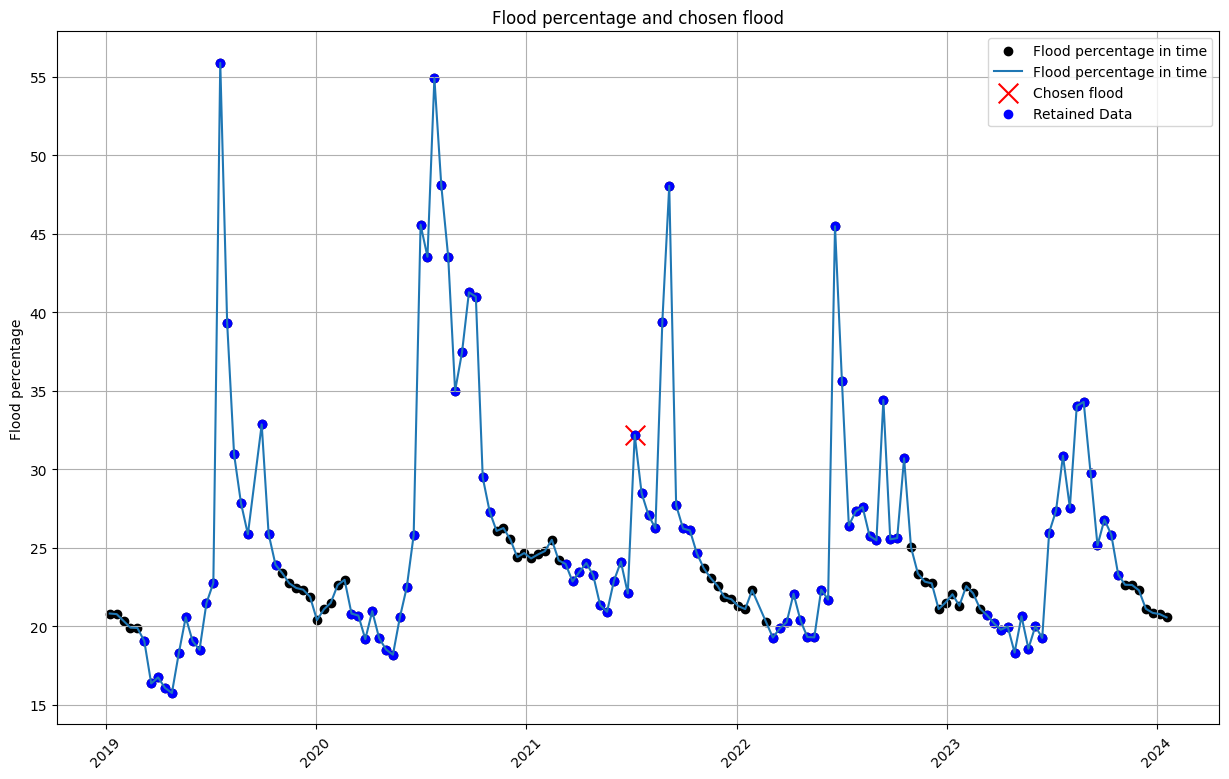

In [39]:
# get timestamps associated with water masks
time_flood = da_tot.time.values

### --- Choose an index that represents a flood --- ###
ind_flood = 75 # first flood of 2021 monsoon season for bangladesh west
# ind_flood = 80 # second flood of 2021 monsoon season for bangladesh west
# ind_flood = 103 # for subset_bang; second to last flood
# ind_flood = 138 # for subset_bang; last flood
# ind_flood = 69 # for subset-Nepal
# ind_flood = 192 # for sylhet_retry/central, and slyhet_west
# ind_flood = 169 # for Missouri River - 30 m

# mark indexes to keep (time filter)
idx_retained = []
for i in range(len(time_flood)):
    if (pd.Timestamp(time_flood[i]).month, pd.Timestamp(time_flood[i]).day) > (keep_start.month, keep_start.day) and (pd.Timestamp(time_flood[i]).month, pd.Timestamp(time_flood[i]).day) < (keep_stop.month, keep_stop.day):
        idx_retained.append(i)

# Plot the flood percentage and index chosen
fig_flood = plt.figure(figsize=(15,9))
plt.scatter(time_flood, floodpercent, color='black', label = 'Flood percentage in time')
plt.plot(time_flood, floodpercent, label = 'Flood percentage in time')
plt.scatter(time_flood[ind_flood],floodpercent[ind_flood],color='red', s=200, marker='x', label = 'Chosen flood')
plt.scatter(time_flood[idx_retained],floodpercent[idx_retained], color='blue', label='Retained Data')
plt.title('Flood percentage and chosen flood')
plt.ylabel('Flood percentage')
# plt.ylim(0,40)
plt.xticks(rotation=45)
plt.grid()
plt.legend()
from datetime import date

os.makedirs(Path(fc.selected,'Figures'), exist_ok=True)
plt.savefig(Path(fc.selected,'Figures')/f'ThresholdAndAreaTS_{date.today()}.png', dpi=300, transparent='True')

plt.show()


***
## Select Data Type: Discharge or Precipitation

In [40]:
# myDim = 'tp' # for ERA5 precipitation data
myDim = 'discharge' # for GeoGlows precipitation data

### Load data

We will load our image stack, screen them to the relevant time frame, and then get the corresponding discharge forecast from Geoglows. 

Note: ERA5 precipitation data must be collected and saved prior. See Jupyter Notebook 1bis-ERA5_Download for code to download the data. 

In [41]:
# Check match between selected date of flood and tiffs
if da_tot.time[ind_flood].values == time_flood[ind_flood]:
    print('Dates of floods and tiffs are matching')
else:
    print('WARNING!!!\nDates of floods and tiffs are not matching')

# Grab lat/lon of tiffs to get discharge forecast
lat, lon = get_centerpoint_coordinates(tiffs_tot[0])

Dates of floods and tiffs are matching
Center Longitude: 89.77166694876536, Center Latitude: 24.46737933371171


In [42]:
geoglows.__version__

'2.0.2'

In [43]:
if myDim == 'discharge':
    import geopandas as gpd
    from shapely.geometry import Point
    
    # Get discharge forecast
    print('Getting streamflow data.')
    if int(geoglows.__version__[0]) < 2:
        # print('You have version 1.7.0!')
        q_tot, ID = get_streamflow_v1(lat,lon)
    elif int(geoglows.__version__[0]) >= 2:
        # print('You have version 2.0 or greater!')
        ID = river_id_from_latlon(lon, lat)
        q_tot = get_streamflow_v2(ID)
        
    # Make discharge data daily. 
    # the 'suffix' '.mean()' will take the mean of the data over the time frame of interest. 
    # q_tot = q_tot.resample(time='1D').mean()
    q_tot = q_tot.resample(time='1D').median() # median is slightly less affected by large changes in values; i.e., it's a little more stable. 
    # I AM HERE; IDK if the below code is ok. 
    q_tot["time"] = q_tot.time.values.astype('datetime64[D]') + 1 # shift datetime by 1 day; this is to prevent the resampling from moving data "forward" a day. 
    
    
    print('Streamflow data acquired.')
elif myDim == 'tp':
    print('Loading precipitation data.')
    q_tot = xr.open_dataset(Path(fc.selected,'ERA5','era5_data.nc')).load().rename({'valid_time':'time'}).to_dataarray().squeeze().drop_vars("variable")
    print('Loading complete.')

Getting streamflow data.
Streamflow data acquired.


### Load and filter other data (IN PROGRESS)

River gauge???



### Temporal Smoothing of Data (OPTIONAL)

Apply a temporal smoothing filter to the data to which to correlate the SAR-derived flood masks. 

Select your desired smoothing range in days. 

Note: A smoothing frame of 1 day technically does nothing as the input GEOGLOWS data already is set to daily rather than in some increment. 

TO DO: 
* Add code to identify the length of time between entries in data and convert smoothing_frame to that. 

In [44]:
### --- Smoothing function --- ###

# This function gives two ways to smooth the data: moving average, and forward only. 
def smooth(y, box_pts, sType = None):
    
    if sType == 'spline':
        from scipy.interpolate import make_smoothing_spline
        x = np.linspace(0, len(y), len(y))

        spl = make_smoothing_spline(x, y, lam=box_pts)
        y_smooth = spl(x)
        
    else:
        if sType == 'forwardOnly':
            # only smooth forward in time
            box = np.zeros(box_pts)
            myIdx = int(np.round(box_pts/2.0))
            box[myIdx:] = 1 / len(box[myIdx:])        
        elif sType == 'movingAverage':
            # do a moving average filter (which back-propagates smoothing)
            box = np.ones(box_pts)/box_pts
        elif sType == 'gaussian':
            mean, stddev = np.mean(y), 2.0
            box = np.random.normal(mean, stddev, box_pts)
    
        y_smooth = np.convolve(y, box, mode='same')
    
    return y_smooth

In [45]:
q_tot_smoothed = q_tot.copy(deep=True)


if smoothing_frame: # if 'smoothing_frame' isn't empty, then do all this stuff
    q_new = q_tot.copy(deep=True)
    
    for i in range(1,len(smoothing_frame)): # skip the first entry of 'smoothing_frame' (which should just be the original, without smoothing!)
        # temp = smooth(q_tot.values, smoothing_frame[i], sType=mysType)
        q_new.values = smooth(q_tot.values, smoothing_frame[i], sType=mysType)
        q_tot_smoothed = xr.concat([q_tot_smoothed, q_new], dim=myDim) # "discharge")

print('Smoothing complete.')

Smoothing complete.


***
### Plot flood and discharge data over full time series

In [46]:
def plot_fpONdis(t_f, fp, i_f, t_t, q_t, smoothing=[]):
    # t_f = time_flood
    # fp = floodpercent
    # i_f = ind_flood
    # t_t = times_tot
    # q_t = q_tot
    fig_fNd, ax_flood = plt.subplots(figsize=(15,6))
    # Plot the flood percentage and index chosen
    lns1 = ax_flood.plot(t_f, fp, color='blue', linestyle= 'None', marker='o', label = 'Flood percentage in time')
    if i_f is not None:
        lns2 = ax_flood.plot(t_f[i_f],fp[i_f],color='red', linestyle= 'None', marker='x', markersize=20, label = 'Chosen flood')
    
    ax_disch = ax_flood.twinx() # twin the axis so both can be on the same plot. 
    # get matching date for dischage and images/masks
    idxA, idxB = np.where(t_t[0] == q_t.time)[0][0], np.where(t_t[-1] == q_t.time)[0][0]
    if myDim == 'discharge':
        lns3 = ax_disch.plot(q_t[idxA:idxB].time,q_t[idxA:idxB], color='green', label='Discharge')
    elif myDim == 'tp': 
        lns3 = ax_disch.plot(q_t[idxA:idxB].time,q_t[idxA:idxB], color='green', label='Precipitation')
    
    # set axis
    if smoothing or smoothing==0:
        ax_flood.set_title(f'Flood percentage and chosen flood\nSmoothing Frame = {smoothing} days')
    else:
        ax_flood.set_title('Flood percentage and chosen flood')
    ax_flood.set_ylabel('Flood percentage')
    if myDim == 'discharge':
        ax_disch.set_ylabel('Discharge [$m^3/s$]')
    elif myDim == 'tp':
        ax_disch.set_ylabel('Precipitation [$m/d$]')
    
    ax_flood.grid()
    
    # combine the line labels into one for the legend. 
    if i_f is not None:
        lns = lns1+lns2+lns3
    else:
        lns = lns1 + lns3
    labs = [l.get_label() for l in lns]
    ax_flood.legend(lns, labs)
    
    import matplotlib.dates as mdates
    ax_flood.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,12,3)))
    ax_flood.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    
    
    plt.setp(ax_flood.get_xticklabels(), rotation=45)
    
    plt.show()

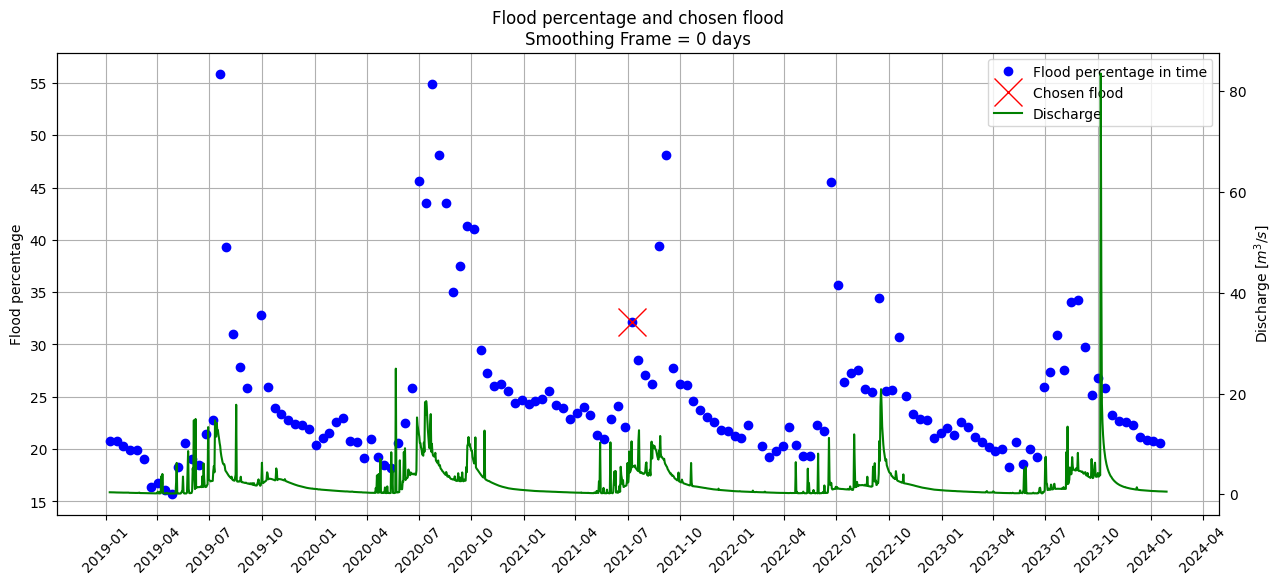

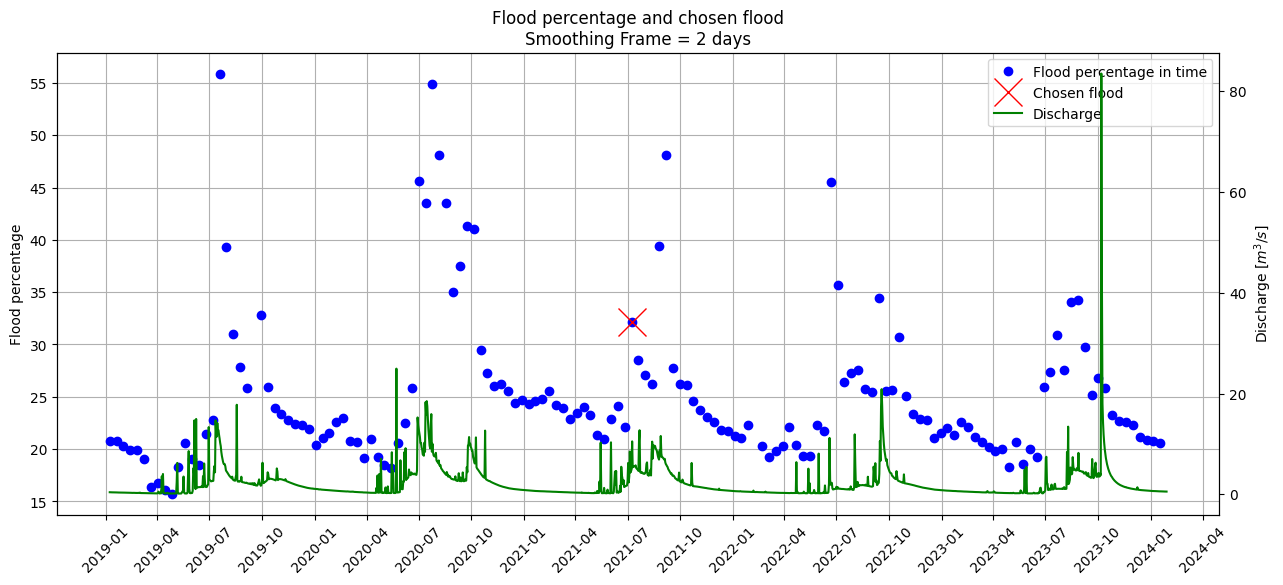

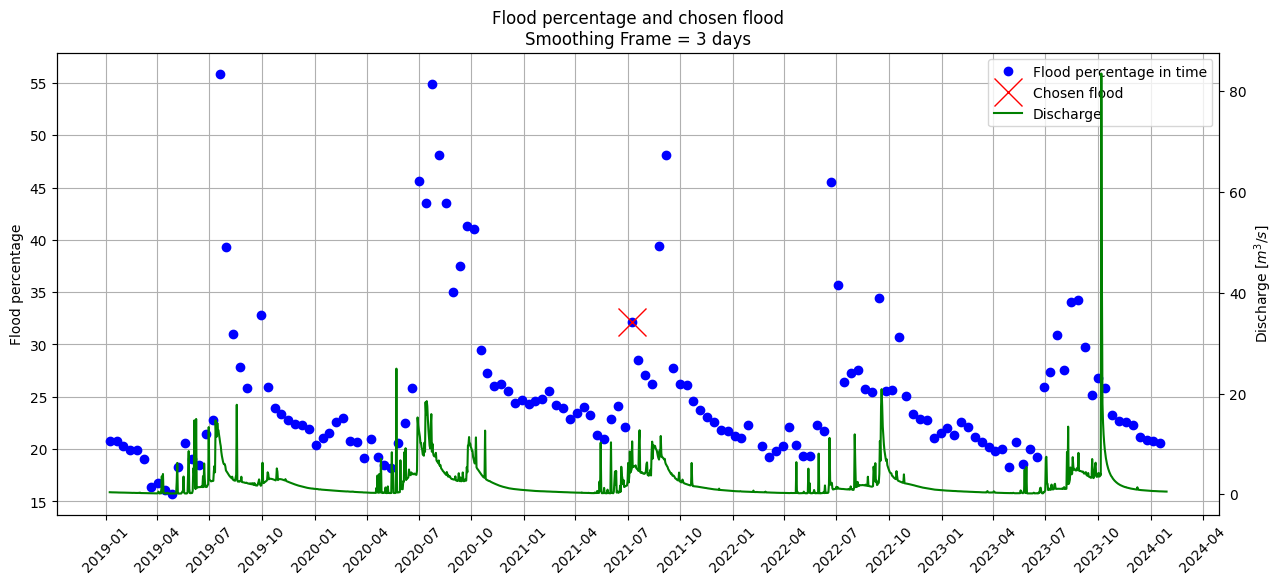

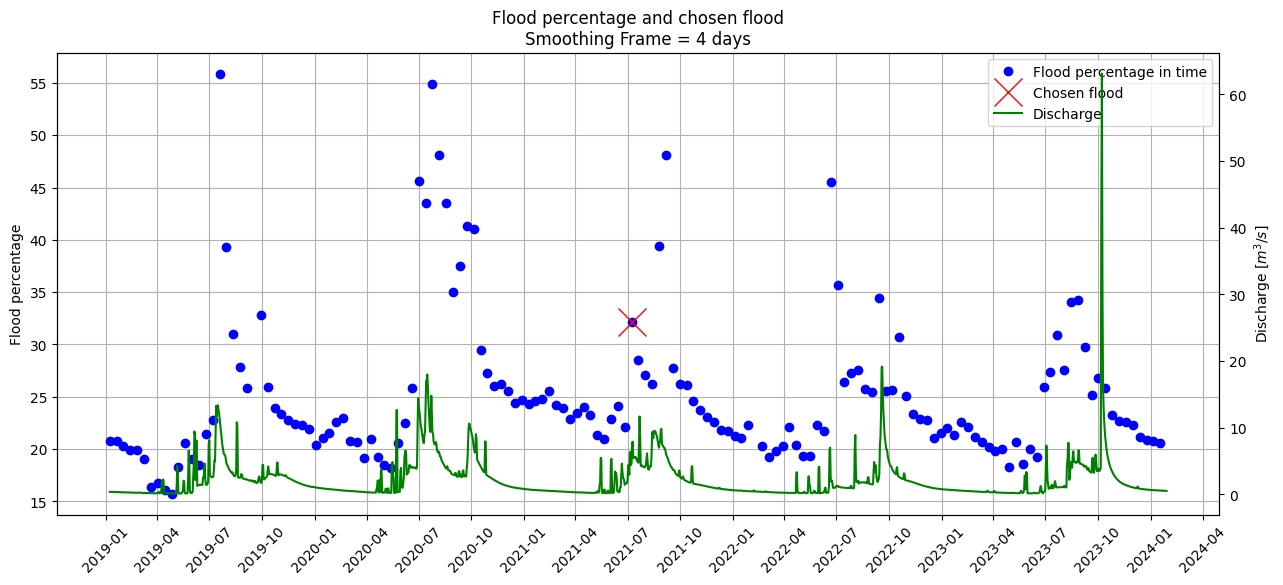

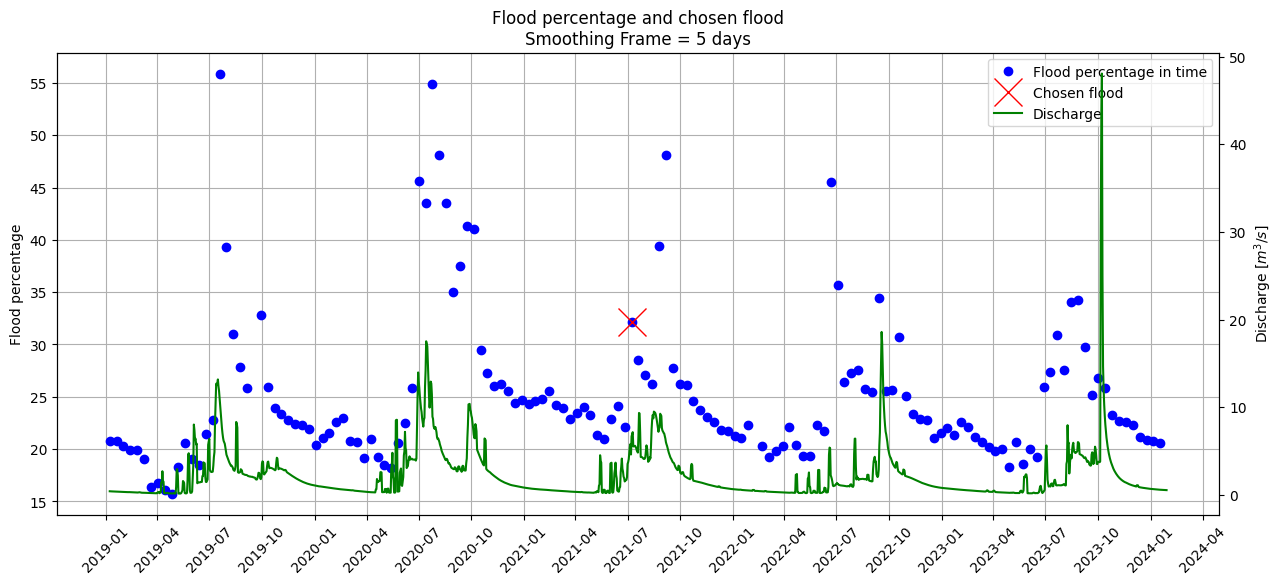

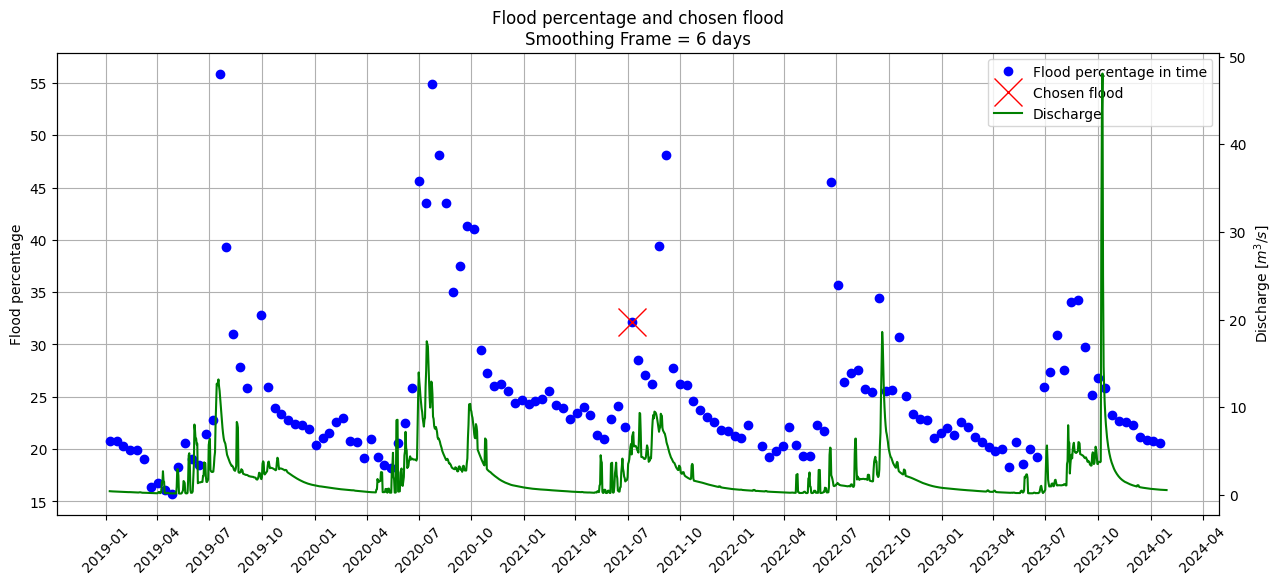

In [47]:
if len(smoothing_frame) >= 2:
    for i in range(0,len(smoothing_frame)):
        plot_fpONdis(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed[i], smoothing_frame[i])
else: 
    plot_fpONdis(time_flood, floodpercent, ind_flood, times_tot, q_tot)

## Smoothing check

The following code provides a visualization and a simple root means square difference (RMSD) metric to verify that the smoothing frame selected has actually resulted in a change in the discharge. 

In [48]:
def plot_fpONdis_smoothed(t_f, fp, i_f, t_t, q_t, s_f = [], matching = None):
    # t_f = time_flood
    # fp = floodpercent
    # i_f = ind_flood
    # t_t = times_tot
    # q_t = q_tot
    # s_f = smoothing_frame
    fig_fNd, ax_flood = plt.subplots(figsize=(15,6))
    # Plot the flood percentage and index chosen
    lns1 = ax_flood.plot(t_f, fp, color='blue', linestyle= 'None', marker='o', label = 'Flood percentage in time')
    lns2 = ax_flood.plot(t_f[i_f],fp[i_f],color='red', linestyle= 'None', marker='x', markersize=20, label = 'Chosen flood')
    
    ax_disch = ax_flood.twinx() # twin the axis so both can be on the same plot. 
    # get matching date for dischage and images/masks

    from matplotlib import cm
    myColors = cm.rainbow(np.linspace(0,1,len(s_f)))
    
    lns = []
    if matching:
        # find matching times
        idxs = []
        for i in range(0,len(t_t)): 
            idx = np.where(t_t[i] == q_t.time)[0][0]
            idxs.append(idx)
        # plot as a scatter plot
        # lns3 = ax_disch.scatter(q_t[idxs].time, q_t[idxs], color='green', label='Discharge')
        for i in range(0,len(s_f)):
            # lns3 = ax_disch.plot(q_t[i,idxs].time, q_t[i,idxs], color='green', label='Discharge', marker = 'o', linestyle='None')
            myLabel = f'Smoothing Frame - {s_f[i]} days'
            ax_disch.plot(q_t[i,idxs].time, q_t[i,idxs], color=myColors[i], label=myLabel, marker = 'o', linestyle='None')
    else:
        idxA, idxB = np.where(t_t[0] == q_t.time)[0][0], np.where(t_t[-1] == q_t.time)[0][0]
        for i in range(0,len(s_f)):
            # lns3[i] = ax_disch.plot(q_t[i,idxA:idxB].time, q_t[i,idxA:idxB], color='green', label='Discharge')
            myLabel = f'Smoothing Frame - {s_f[i]} days'
            ax_disch.plot(q_t[i,idxA:idxB].time, q_t[i,idxA:idxB], color=myColors[i], label=myLabel)
    
    # set axis
    if s_f:
        ax_flood.set_title(f'Flood percentage and chosen flood\nSmoothing Frame = {s_f} days')
    else:
        ax_flood.set_title('Flood percentage and chosen flood')
    ax_flood.set_ylabel('Flood percentage')
    ax_disch.set_ylabel('Discharge [$m^3/s$]')
    ax_flood.grid()
    
    # combine the line labels into one for the legend. 
    lns = lns1+lns2
    labs = [l.get_label() for l in lns]
    ax_flood.legend(lns, labs, loc='upper left')
    
    import matplotlib.dates as mdates
    ax_flood.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,12,3)))
    ax_flood.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    plt.legend(loc='upper right')
    
    plt.setp(ax_flood.get_xticklabels(), rotation=45)
    
    plt.show()

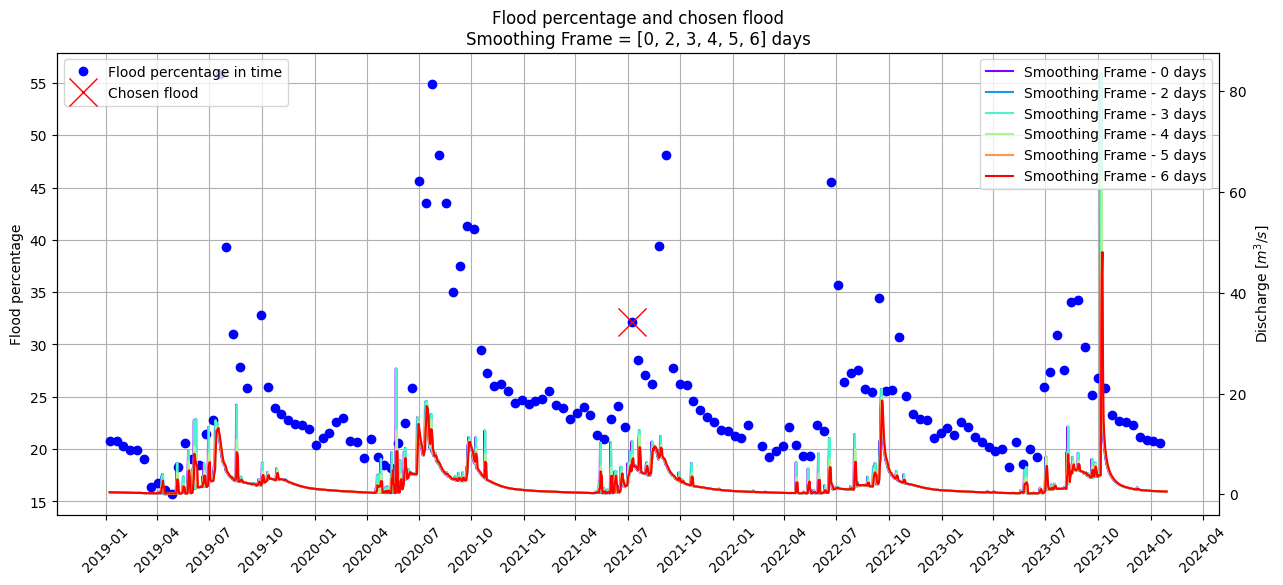

In [49]:
plot_fpONdis_smoothed(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed, smoothing_frame, matching=False)

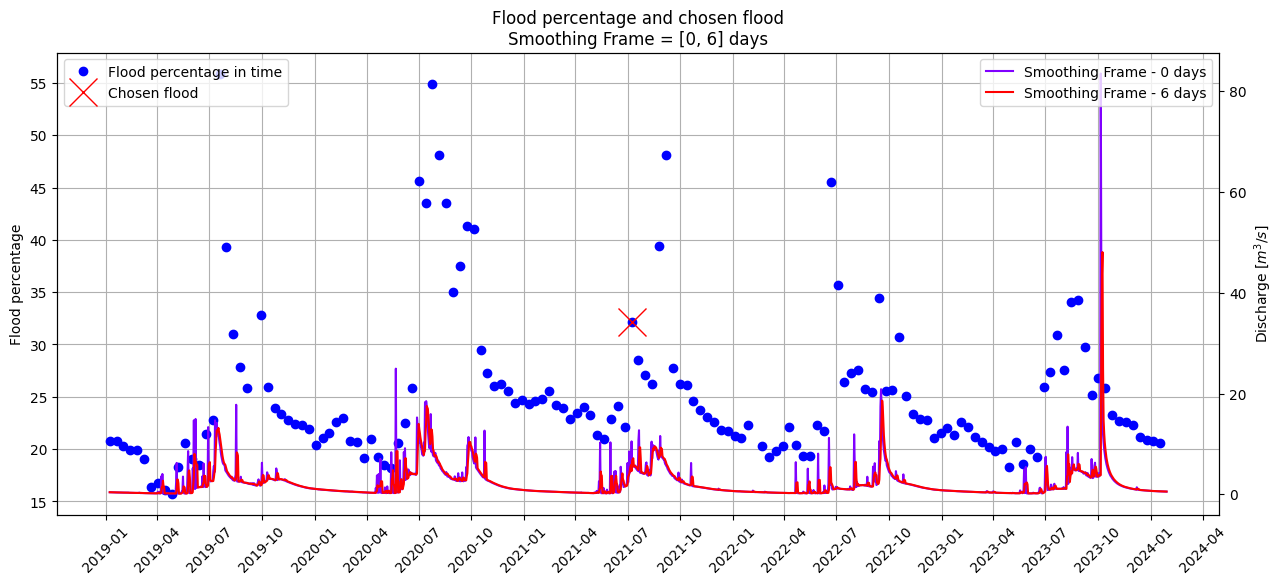

In [50]:
plot_fpONdis_smoothed(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed[0:len(q_tot_smoothed):5], smoothing_frame[0:len(q_tot_smoothed):5], matching=False)

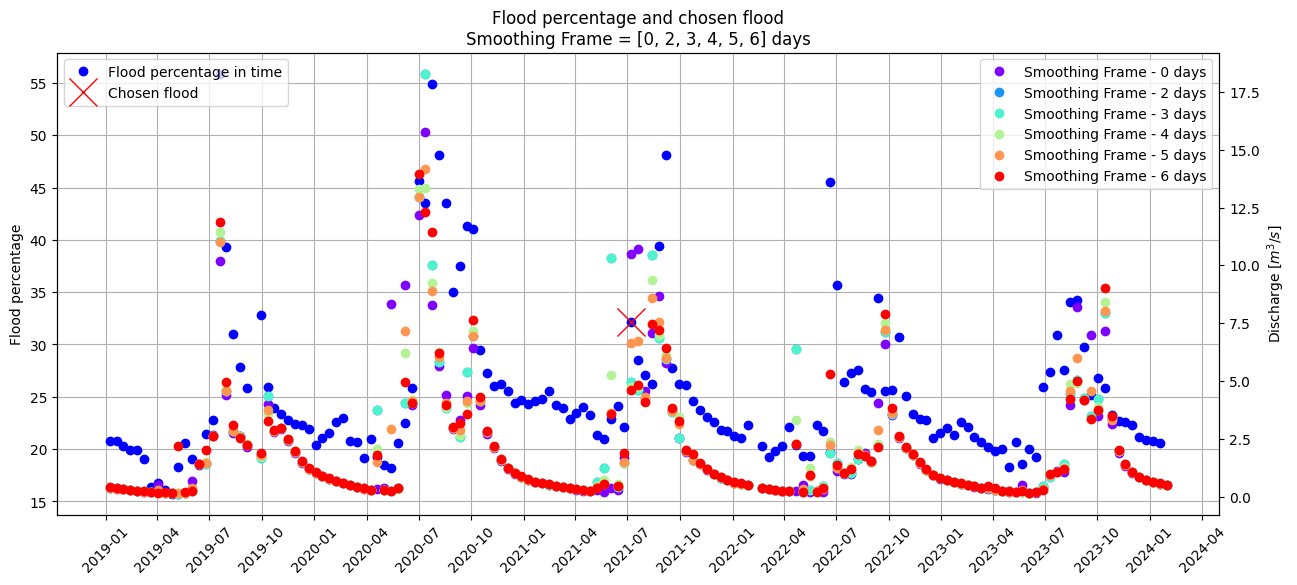

In [51]:
plot_fpONdis_smoothed(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed, smoothing_frame, matching=True)

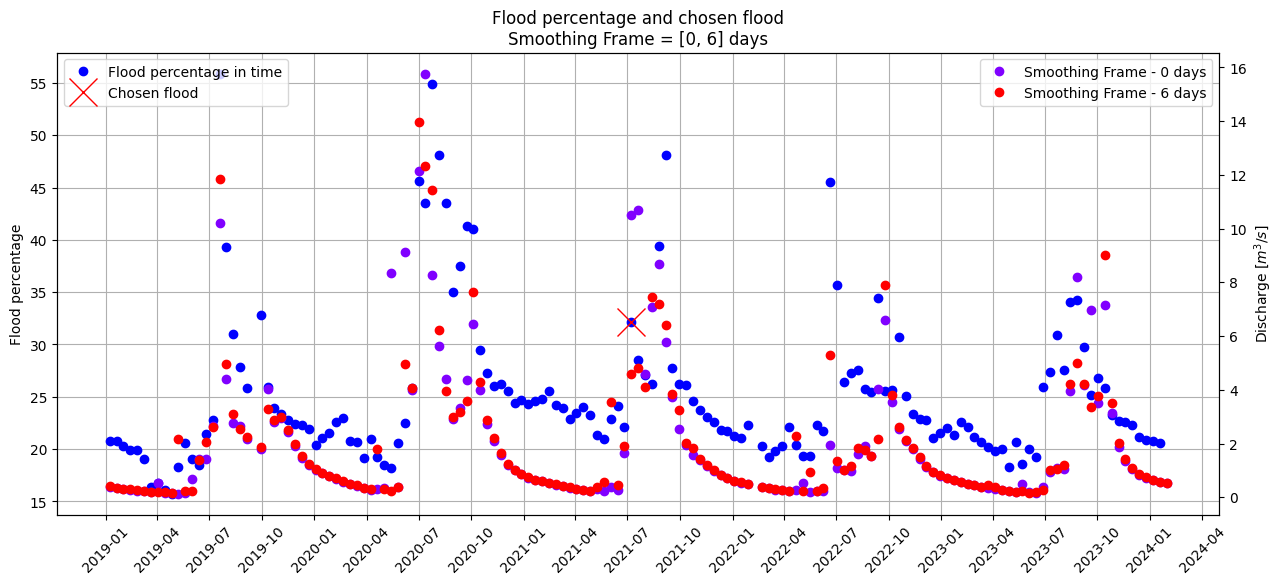

In [52]:
plot_fpONdis_smoothed(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed[0:len(q_tot_smoothed):5], smoothing_frame[0:len(q_tot_smoothed):5], matching=True)

RMSD for 0 days of smoothing: 0.0
RMSD for 2 days of smoothing: 1.542774010114889
RMSD for 3 days of smoothing: 1.542774010114889
RMSD for 4 days of smoothing: 1.2330975538312485
RMSD for 5 days of smoothing: 0.822065035887499
RMSD for 6 days of smoothing: 1.288701829037552


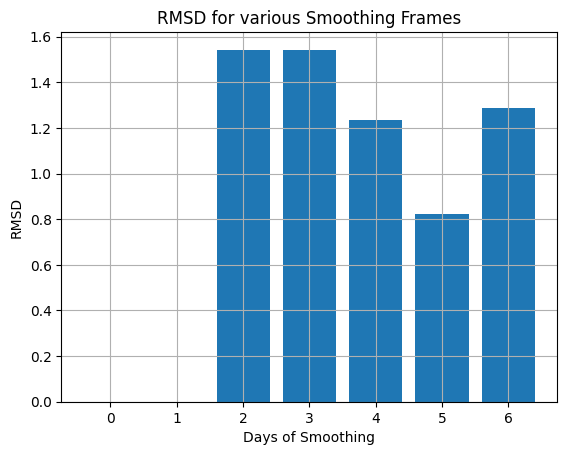

In [53]:
# Calculate root mean difference for matched dates that are smoothed
# find matching times
idxs = []
for i in range(0,len(times_tot)): 
    idx = np.where(times_tot[i] == q_tot_smoothed.time)[0][0]
    idxs.append(idx)

# loop through each smoothing frame and calucalte root mean square difference from the first
myRMSD = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)): 
    myRMSD[i] = np.sqrt(np.mean((q_tot_smoothed[0,idxs].values - q_tot_smoothed[i,idxs].values)**2))
    print(f'RMSD for {smoothing_frame[i]} days of smoothing: {myRMSD[i]}')

plt.bar(smoothing_frame, myRMSD)
plt.xlabel('Days of Smoothing')
plt.ylabel('RMSD')
plt.title('RMSD for various Smoothing Frames')
plt.grid()
plt.show()

### Plot imagery (water masks or SAR based on earlier selection) of pre- and during flooding, their difference, and the relevant discharge data over that time. 

In [54]:
### --- visual flood analysis plots --- ###
# This shows the pre-flooding, during flooding, the difference between the two, and the relevant discharge data over that time. 
def plot_floodComparison(d_t, i_f, t_f, q_t, smoothing=[]):
    # d_t = da_tot
    # i_f = ind_flood
    # t_f = type_file
    # q_t = q_tot

    # get matching date for discharge and images/masks
    idx1, idx2 = np.where(d_t[i_f-1].time == q_t.time)[0][0], np.where(d_t[i_f].time == q_t.time)[0][0]
    
    # plot of pre (ind_flood-1) and during (ind_flood) flooding from water_masks/SAR images. 
    fig_flooding = plt.figure(figsize=(9,9))
    ax_pre = plt.subplot(2,3,1)
    ax_during = plt.subplot(2,3,2)
    ax_diff = plt.subplot(2,3,3)
    if t_f == 'Water_Masks':
        vmin, vmax = 0, 1
    elif t_f == 'SAR':
        vmin, vmax = 0, 255
    ax_pre.imshow(d_t[i_f-1], vmin=vmin, vmax=vmax, cmap='seismic_r', interpolation=None) 
    ax_during.imshow(d_t[i_f], vmin=vmin, vmax=vmax, cmap='seismic_r', interpolation=None)
    d_diff = d_t[i_f] - d_t[i_f-1]
    ax_diff.imshow(d_diff, vmin=vmin, vmax=vmax, cmap='seismic_r', interpolation=None)
    ax_pre.title.set_text(f'Pre-flooding\n{q_t[idx1].time.dt.strftime("%Y-%m-%d").values}')
    ax_during.title.set_text(f'During Flooding\n{q_t[idx2].time.dt.strftime("%Y-%m-%d").values}')
    ax_diff.title.set_text('Difference')    
    if smoothing or smoothing==0:
        fig_flooding.suptitle(f'Smoothing Frame = {smoothing} days')
                                           
    # plot of discharge through time
    ax_dis = plt.subplot(2,1,2)
    xtra = 5
    ax_dis.plot(q_t[idx1-xtra:idx2+xtra].time,q_t[idx1-xtra:idx2+xtra])
    ax_dis.plot(q_t[idx1].time, q_t[idx1], color='green', marker='x', markersize=10)
    ax_dis.plot(q_t[idx2].time, q_t[idx2], color='green', marker='x', markersize=10)
    ax_dis.grid()
    ax_dis.title.set_text('Discharge vs Time')
    ax_dis.set_ylabel('Discharge [$m^3/s$]')
    plt.xticks(rotation=45)
    
    plt.show()

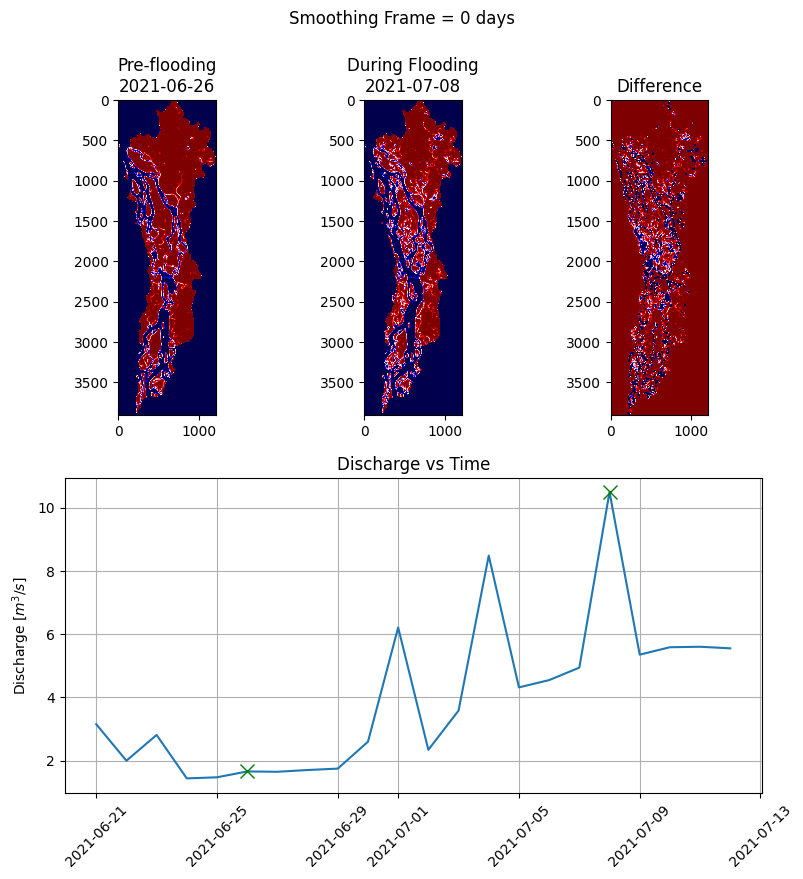

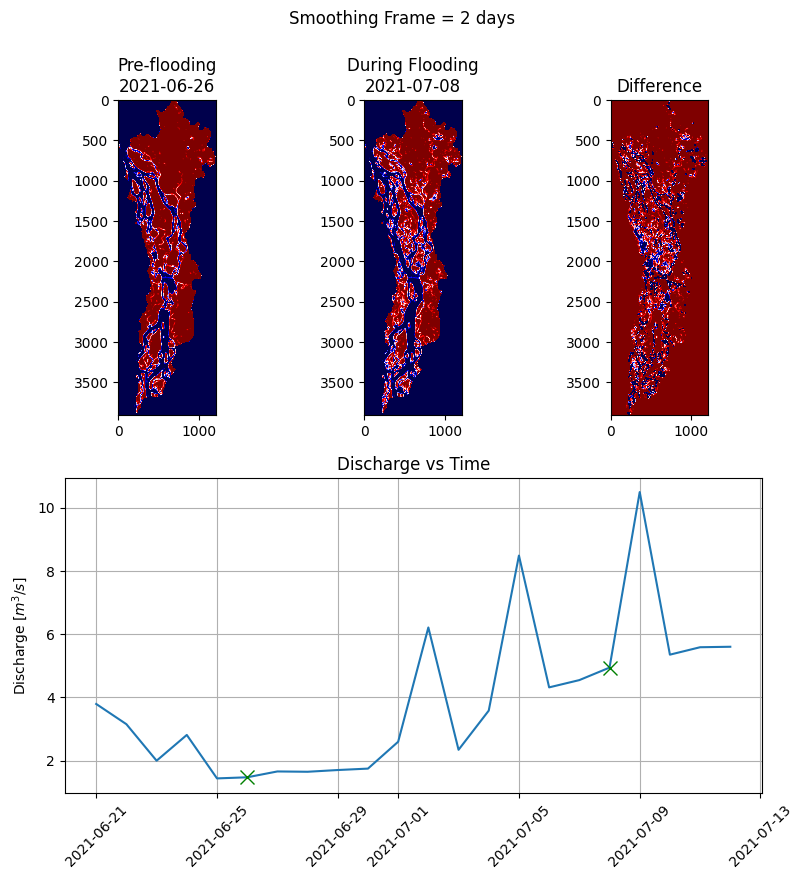

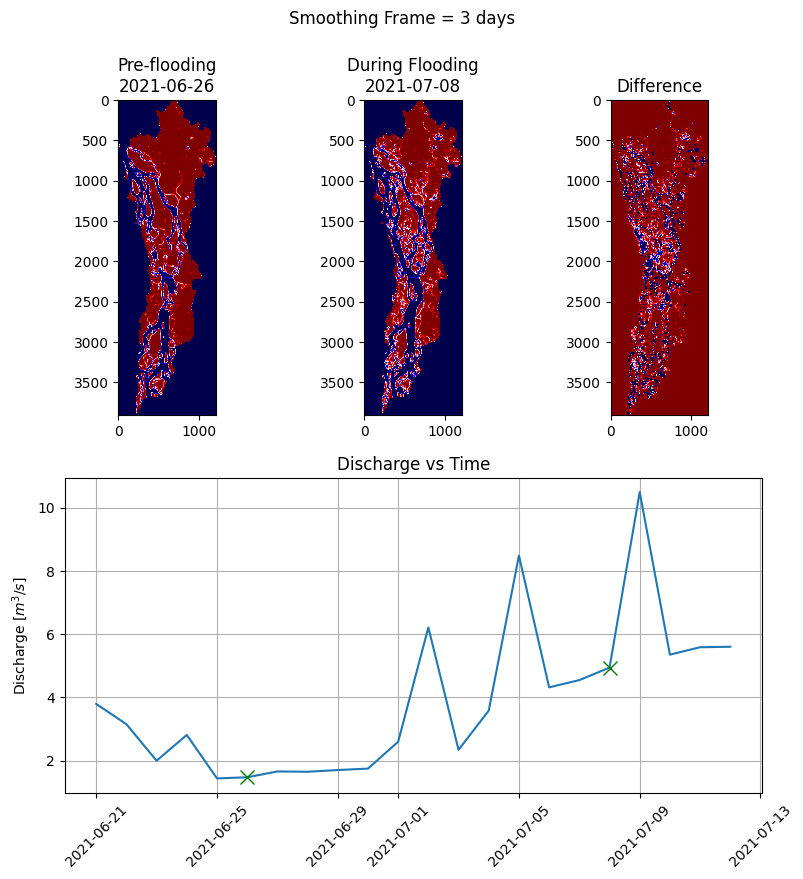

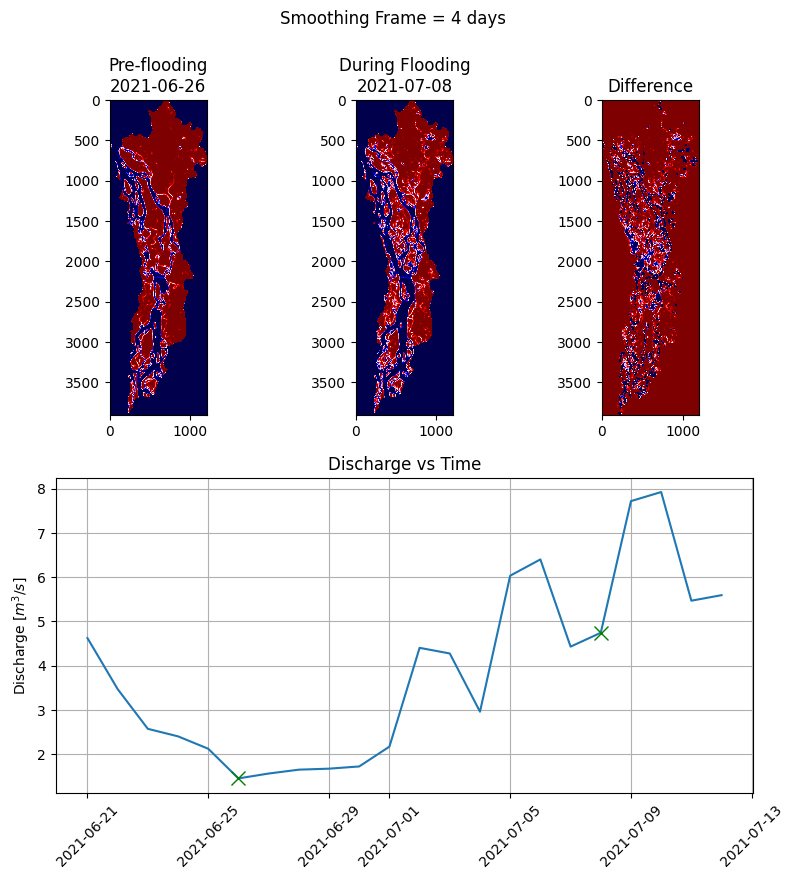

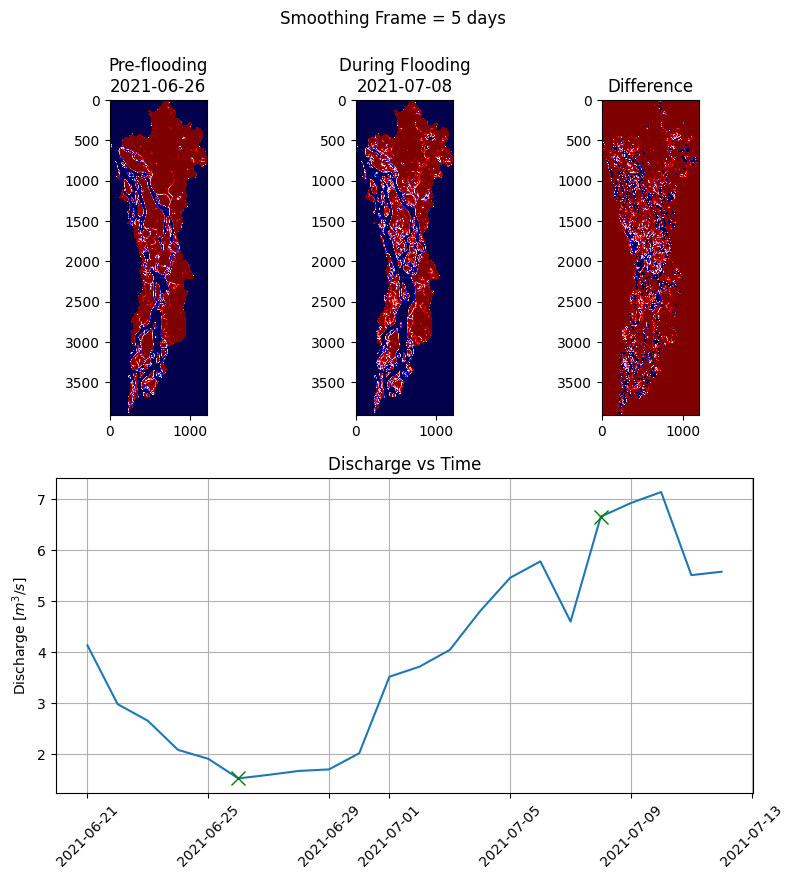

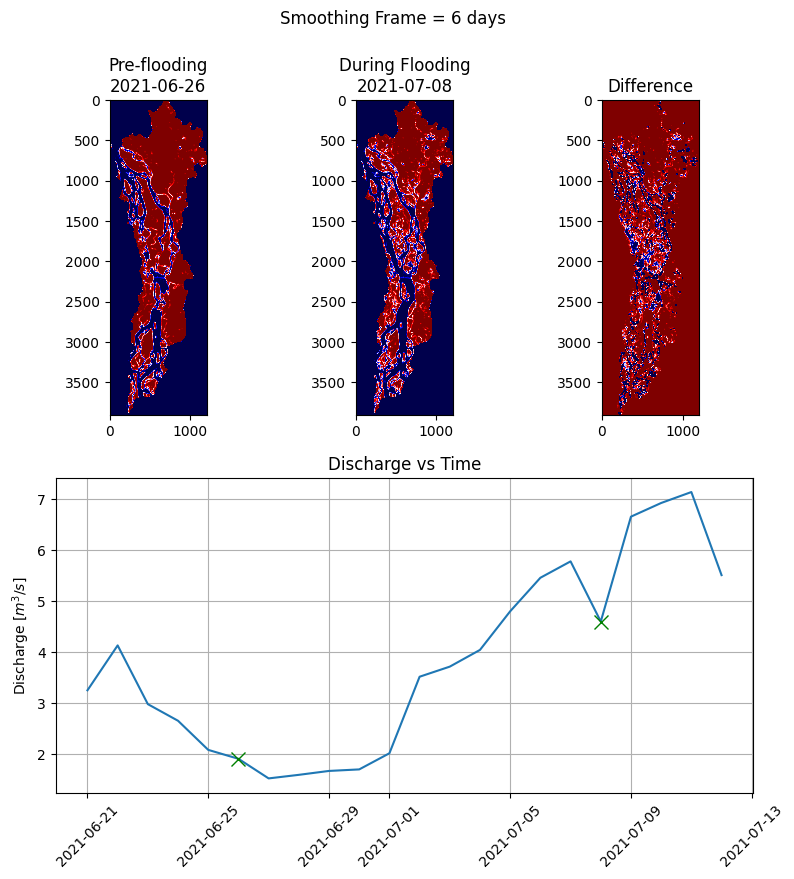

In [55]:
if len(smoothing_frame) >= 2:
    for i in range(0,len(smoothing_frame)):
        plot_floodComparison(da_tot, ind_flood, type_file, q_tot_smoothed[i], smoothing_frame[i])
else:
    plot_floodComparison(da_tot, ind_flood, type_file, q_tot)

## Prep for the REOF

### Parse data to relevant times for the REOF

This takes the data from 'q_tot' and cuts it down to the training time. This training time is from the first day of SAR data/water masks to the flood event we are trying to predict. 

In [56]:
# Crop tiffs and dates to the dates of interest, keep the rest
da = da_tot[:ind_flood]
tiffs = tiffs_tot[:ind_flood]
times = times_tot[:ind_flood]

# Crop to date range
# q_tot = q_tot.resample(time='1D').mean().rolling(time=5).mean()
q = match_dates(q_tot, da.time)

In [57]:
# crop smoothed data to date range

try: 
    q_smoothed = q.copy(deep=True)
    print(f'Cropping 1 of {len(smoothing_frame)}...')
    for i in range(1,len(smoothing_frame)):
        temp = match_dates(q_tot_smoothed[i], da.time)
        q_smoothed = xr.concat([q_smoothed, temp], dim='discharge')
        print(f'{i+1} of {len(smoothing_frame)} cropped...')
    print('Cropping complete!')
except: 
    print('WARNING!!!\nWARNING!!!\nWARNING!!!\nTemporally smoothed data has not been downsampled to daily.')

Cropping 1 of 6...
2 of 6 cropped...
3 of 6 cropped...
4 of 6 cropped...
5 of 6 cropped...
6 of 6 cropped...
Cropping complete!


### Temporal & Flood Percent Threshold Filter (OPTIONAL)
Remove data from non-rainy times

From approximately Nov. 1st to Jan. 1st, there are numerous high flood percentage days with very low discharge. These data reduce the correlation between discharge and flooding. Their removal tends to improve flood forecasting. 

In [58]:
print(f"Selected date range to keep: {keep_start.strftime('%m-%d')} to {keep_stop.strftime('%m-%d')}")
if keep_start > keep_stop: 
    print("\n\nWARNING!!!\nWARNING!!!\nWARNING!!!\nStop date is before the start date!")

Selected date range to keep: 03-01 to 10-30


In [59]:
# max percent to allow
threshold_prcnt = 9.0
threshold_prcnt = None

if threshold_prcnt is None:
    print('No flood percent threshold will be applied.')
elif threshold_prcnt < floodpercent[ind_flood]:
    print(f'''WARNING!!!\nWARNING!!!\nWARNING!!!\n\n
    \nSelected flood percent threshold is greater than the flood percent of the selected flood event!\nThreshold     = {threshold_prcnt}\nFlood percent = {floodpercent[ind_flood]}\n\nSelect a different threshold or flood event.''')

No flood percent threshold will be applied.


In [60]:
# get list of indices to keep
# MODIFIED to retain only those both within the specified date range and beneath the specified flood percentage!!! 
idx_keep = []
for i in range(len(da.time)):
    tempy = pd.Timestamp(da[i].time.values)
    if (tempy.month, tempy.day) > (keep_start.month, keep_start.day) and (tempy.month, tempy.day) < (keep_stop.month, keep_stop.day): # this keeps the appropriate date range
        if pd.Timestamp(da[i].time.values) == pd.Timestamp(time_flood[i]):
            if threshold_prcnt is None: 
                idx_keep.append(i)
            elif floodpercent[i] < threshold_prcnt: 
                idx_keep.append(i)
            else:
                print(f'Flood percent threshold exceeded for Date = {pd.Timestamp(time_flood[i])}\nThreshold    = {threshold_prcnt}\nFloodpercent = {floodpercent[i]}')
        else:
            print('WARNING!!!\nTimestamps don\'t match! Flood threshold removal could not execute!')

In [61]:
# Crop tiffs and dates to the dates of interest, keep the rest
print(f'Length of \'da\' before temporal filter: {len(da)}')
da = da_tot[idx_keep]
print(f'Length after: {len(da)}')
# tiffs_tot requires a special methodology for some reason
tiffs = []
for idx in idx_keep:
    tiffs.append(tiffs_tot[idx])
tiffs
times = times_tot[idx_keep]

# Crop to date range
q_tot = q_tot.resample(time='1D').mean()
q = match_dates(q_tot, da.time)

Length of 'da' before temporal filter: 75
Length after: 50


In [62]:
# copy over data for times we want to keep

try: 
    q_smoothed = q.copy(deep=True)
    print(f'Cropping 1 of {len(smoothing_frame)}...')
    for i in range(1,len(smoothing_frame)):
        temp = match_dates(q_tot_smoothed[i], da.time)
        q_smoothed = xr.concat([q_smoothed, temp], dim='discharge')
        print(f'{i+1} of {len(smoothing_frame)} filtered...')
    print('Time filtering complete!')
except: 
    print('Temporally smoothed data has not been downsampled to daily.')


Cropping 1 of 6...
2 of 6 filtered...
3 of 6 filtered...
4 of 6 filtered...
5 of 6 filtered...
6 of 6 filtered...
Time filtering complete!


RAW DATASET


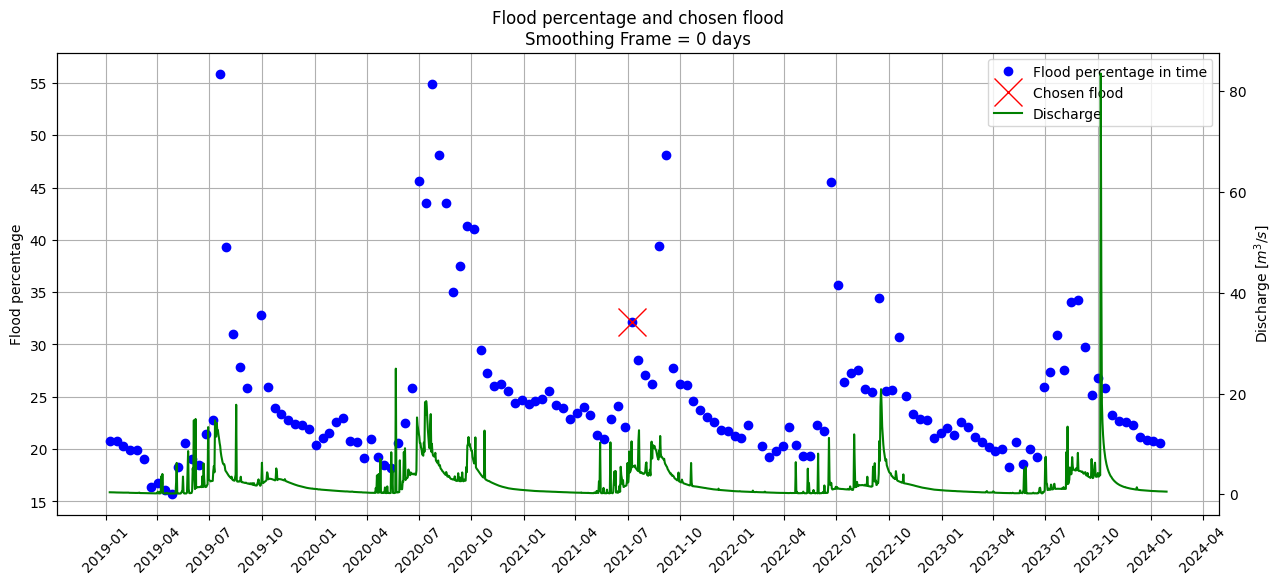

PROCESSED DATASET


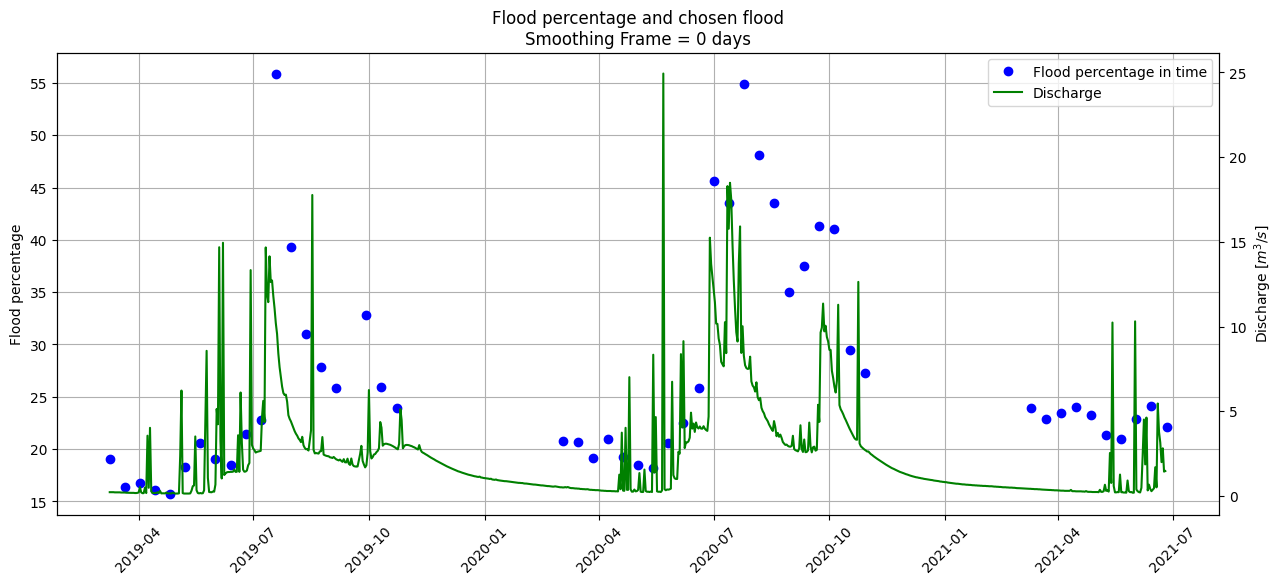

RAW DATASET


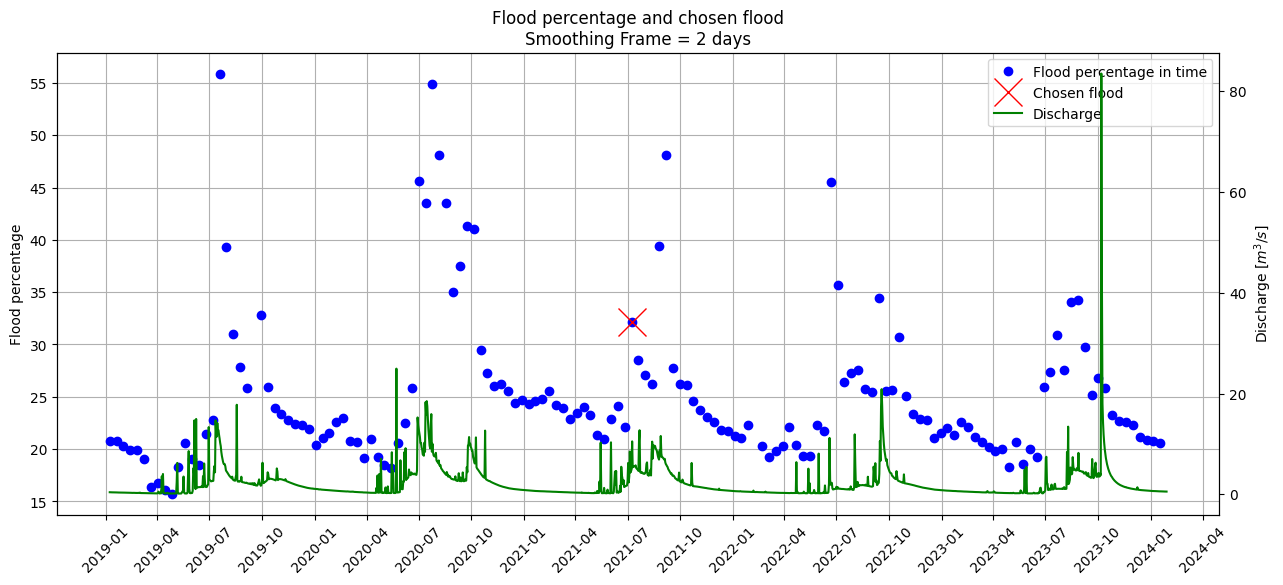

PROCESSED DATASET


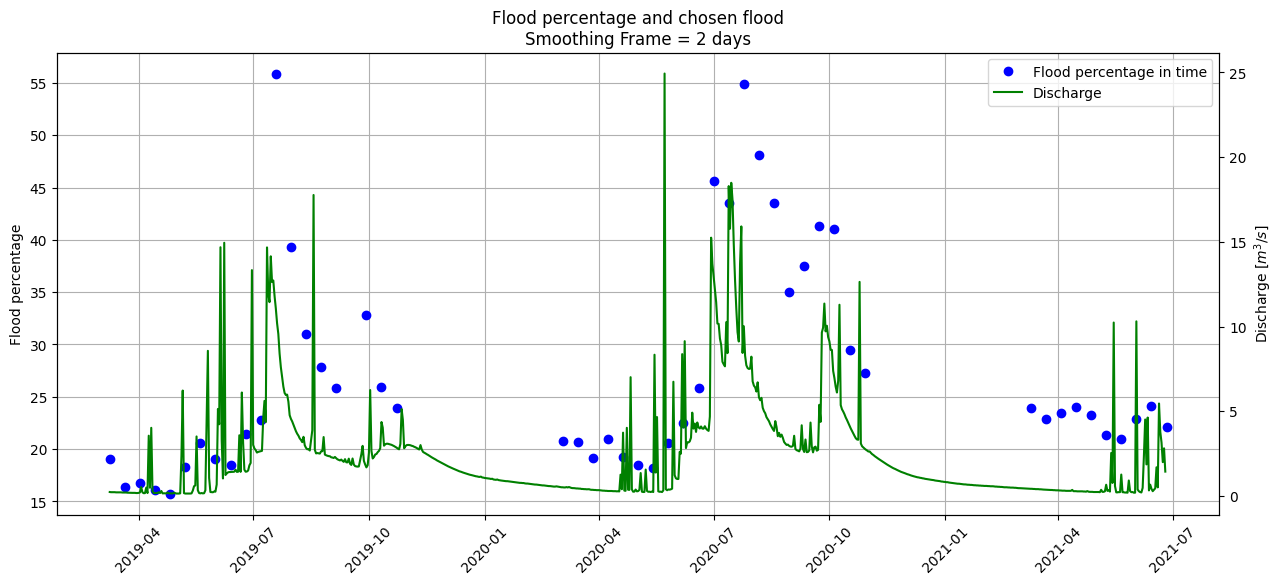

RAW DATASET


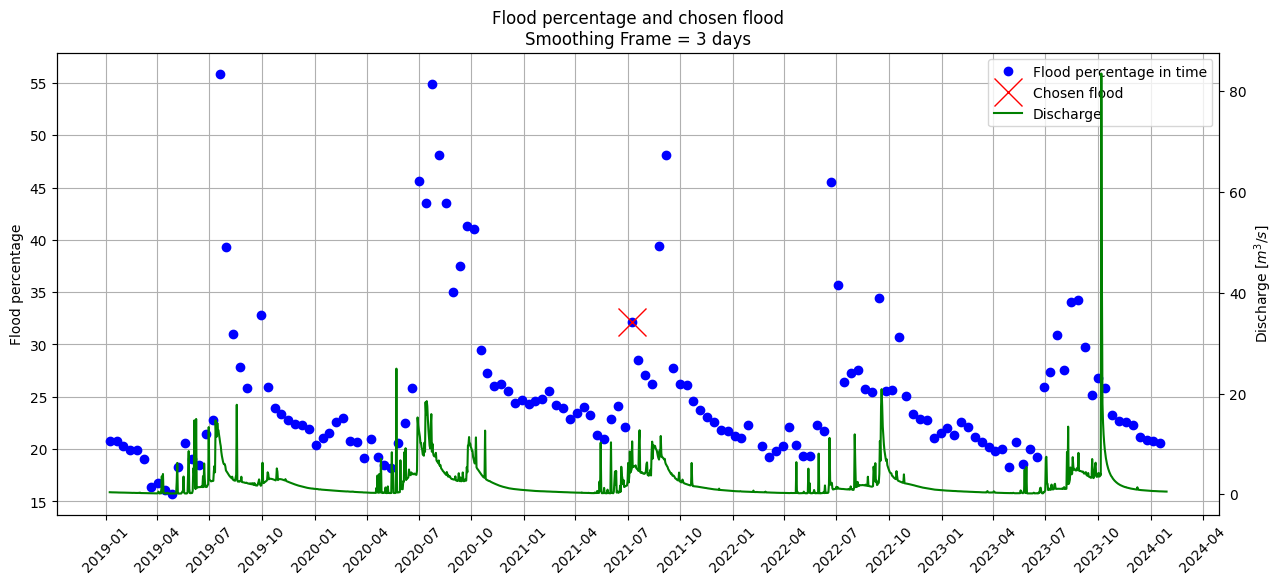

PROCESSED DATASET


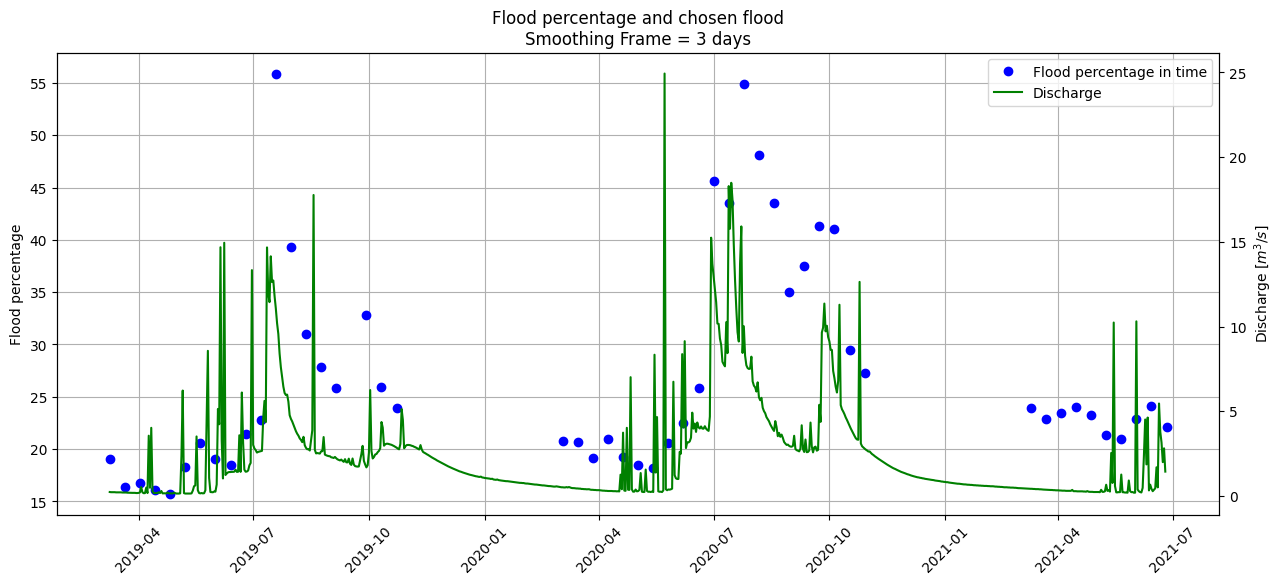

RAW DATASET


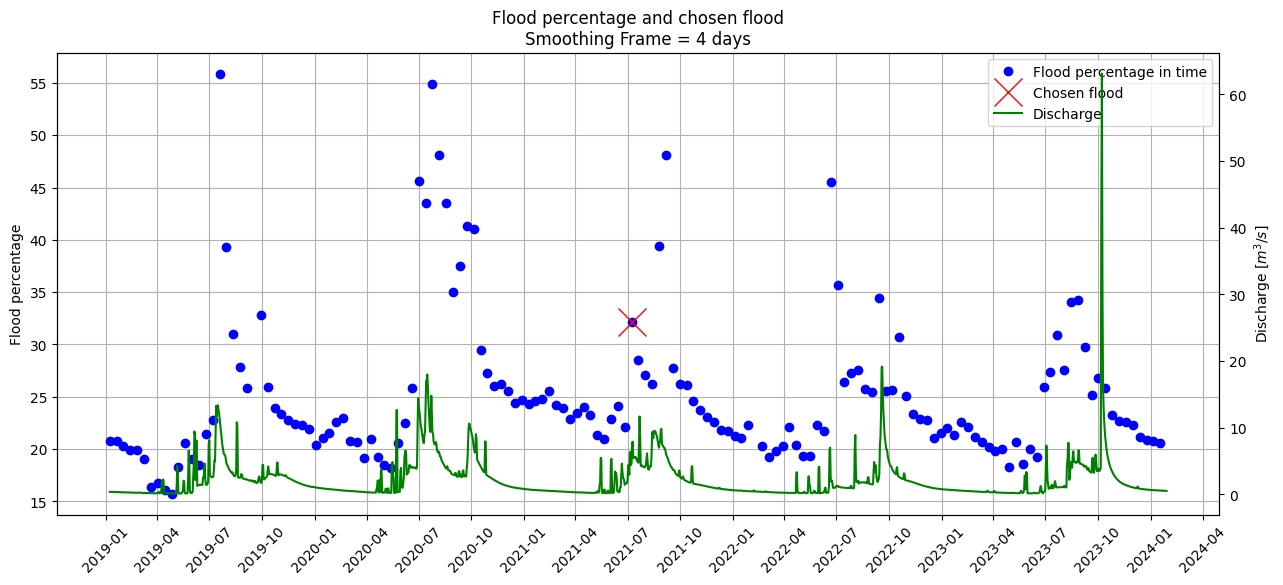

PROCESSED DATASET


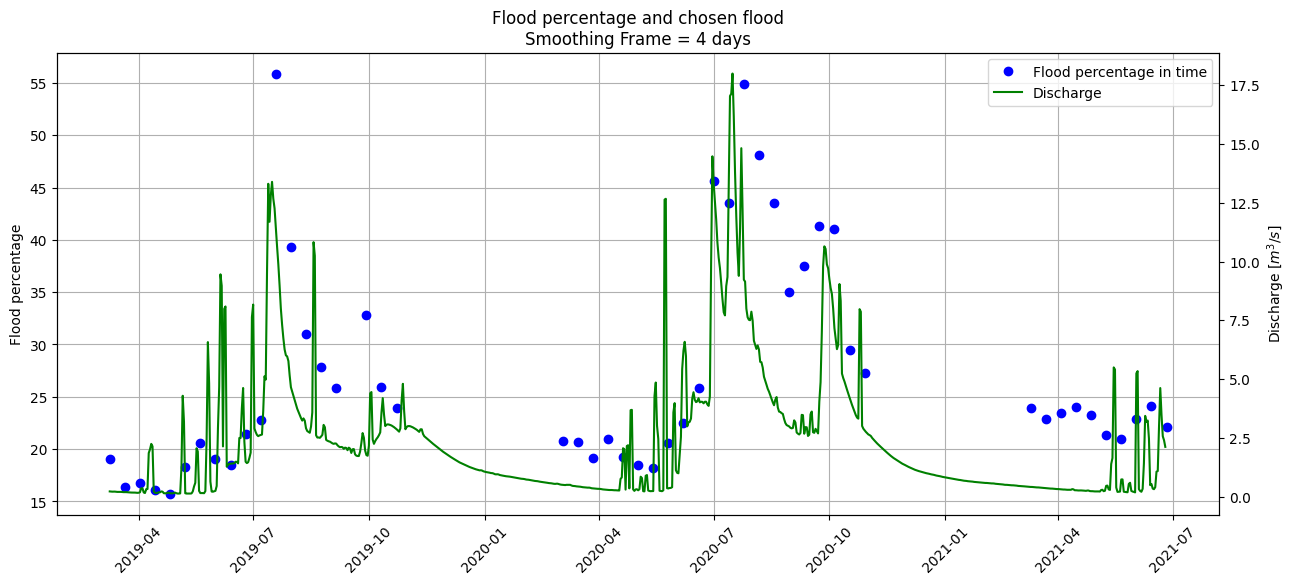

RAW DATASET


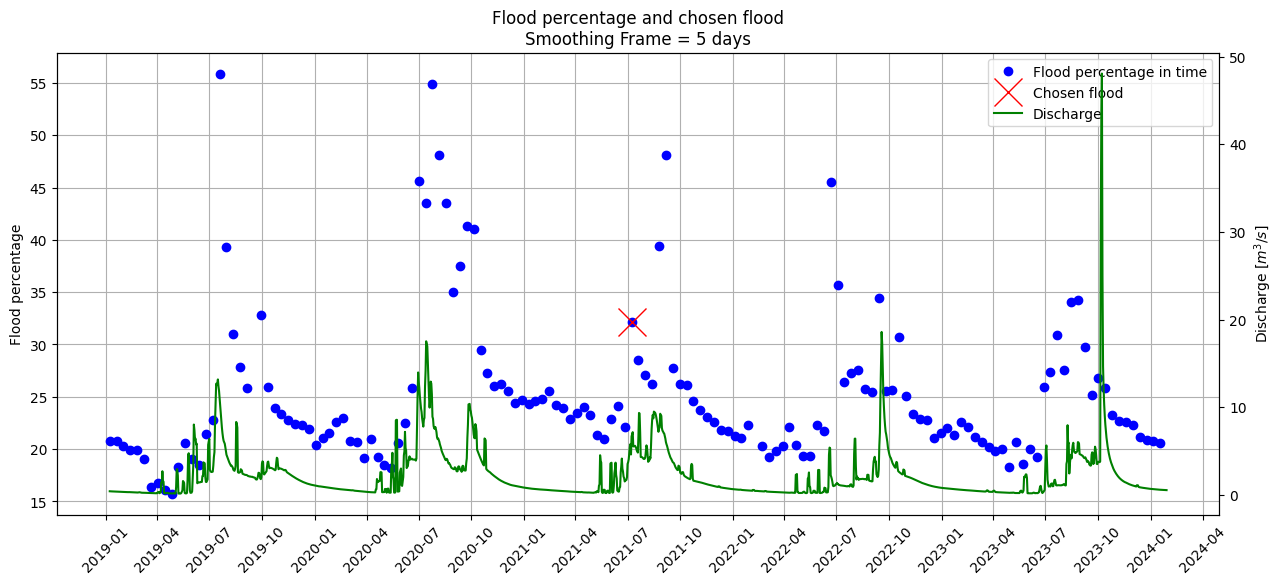

PROCESSED DATASET


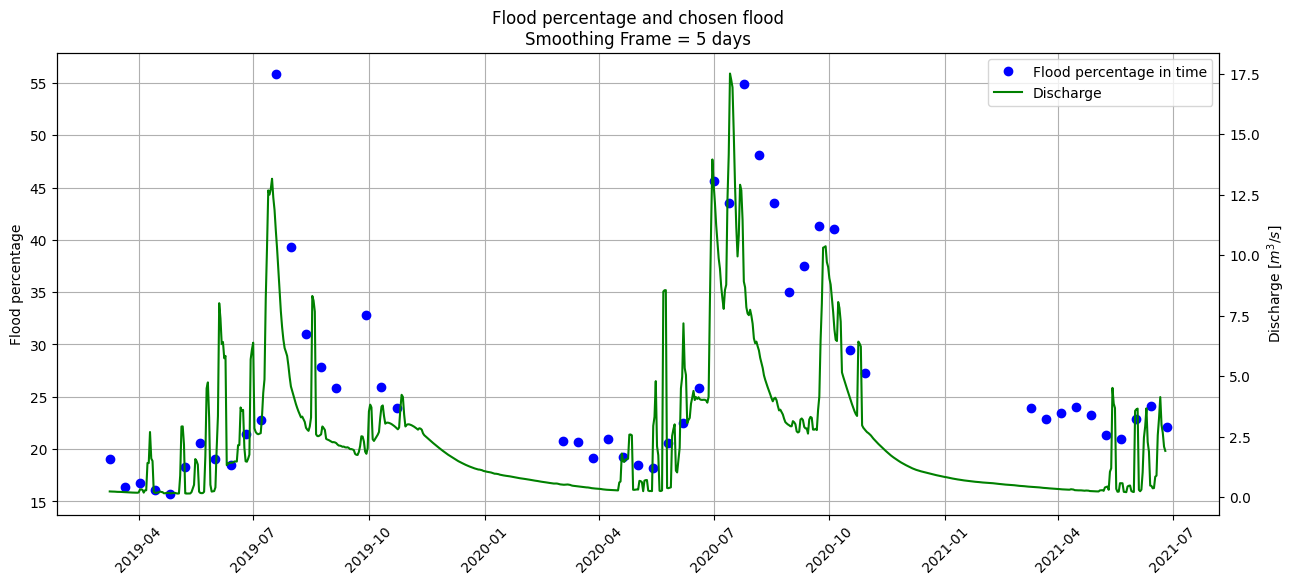

RAW DATASET


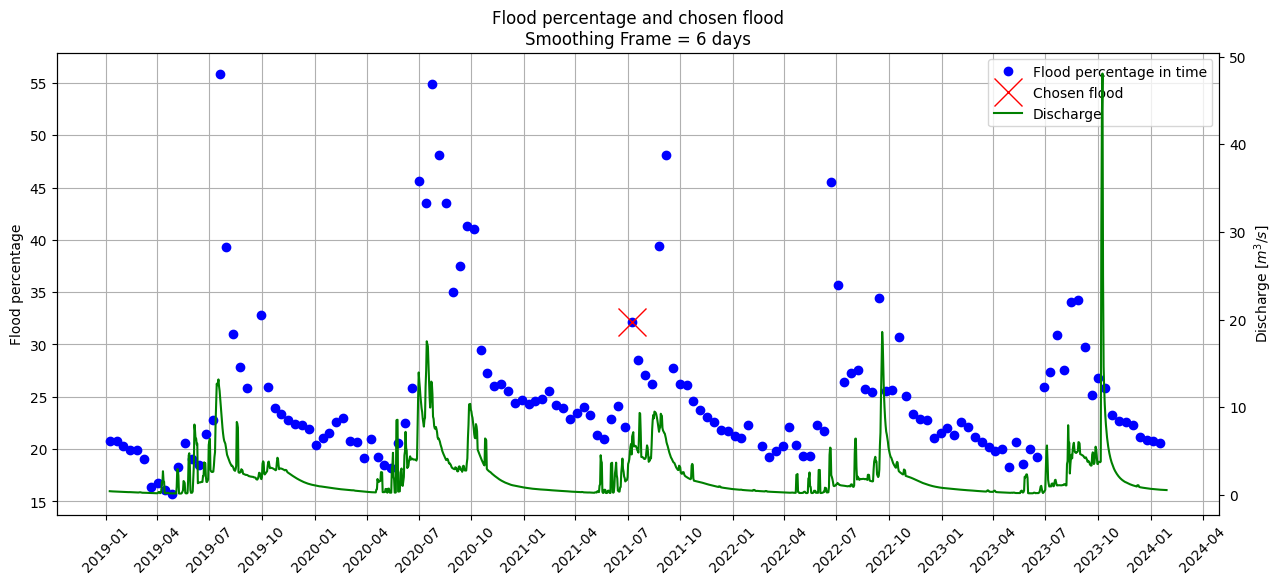

PROCESSED DATASET


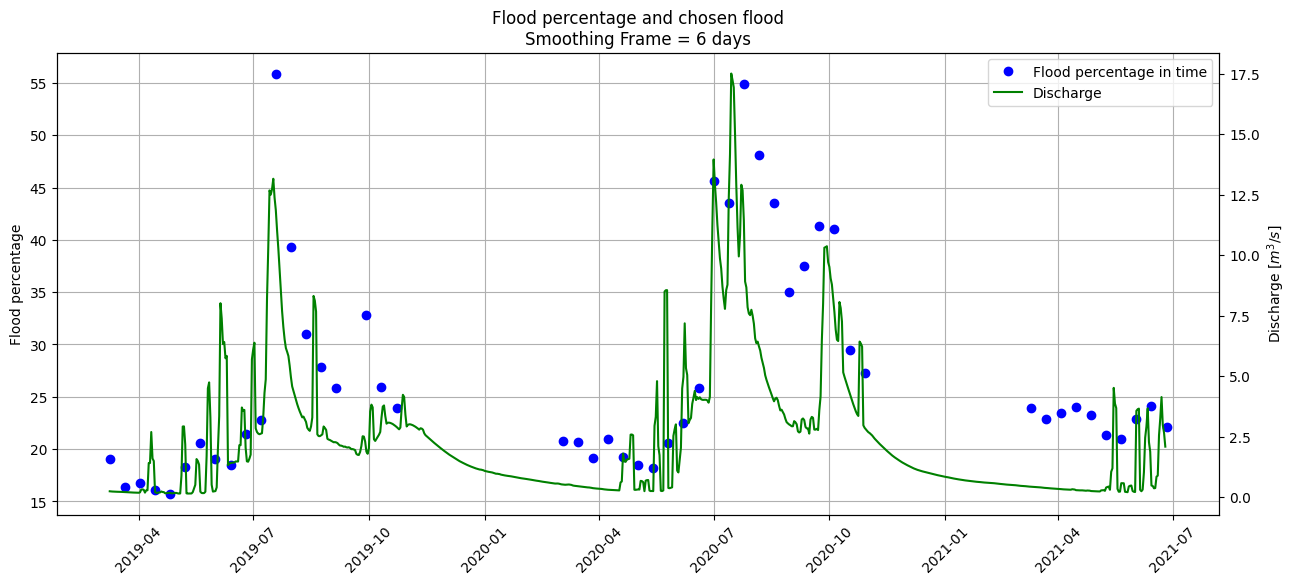

In [63]:
# plot processed data as a final double check before running the REOF
ind_flood_mod = len(idx_keep)-1
if len(smoothing_frame) >= 2:
    for i in range(0,len(smoothing_frame)):
        print('RAW DATASET')
        plot_fpONdis(time_flood, floodpercent, ind_flood, times_tot, q_tot_smoothed[i], smoothing_frame[i])
        print('PROCESSED DATASET')
        plot_fpONdis(time_flood[idx_keep], floodpercent[idx_keep], None, times_tot[idx_keep], q_tot_smoothed[i], smoothing_frame[i])
else: 
    plot_fpONdis(time_flood, floodpercent, ind_flood, times_tot, q_tot)

## Run the REOF

In [66]:
# Calculate REOF of the tiffs
# Number of temporal modes to use; technically, this should be the number of images (or water masks) that you have. 
if isinstance(n_modes, int):
    print(f'REOF will run using only some of the modes: {n_modes} total.')
elif n_modes == None:
    n_modes = len(da) # proper REOF
    print(f'REOF will run using all modes: {n_modes} total.')

print(f'Tolerance: {myTolerance}')
# Run the REOF calculation. 
reof_ds = reof(da, n_modes, myTolerance)

REOF will run using only some of the modes: 3 total.
Tolerance: 1e-05
REOF time: 23.42 seconds


### Visualize the temporal modes

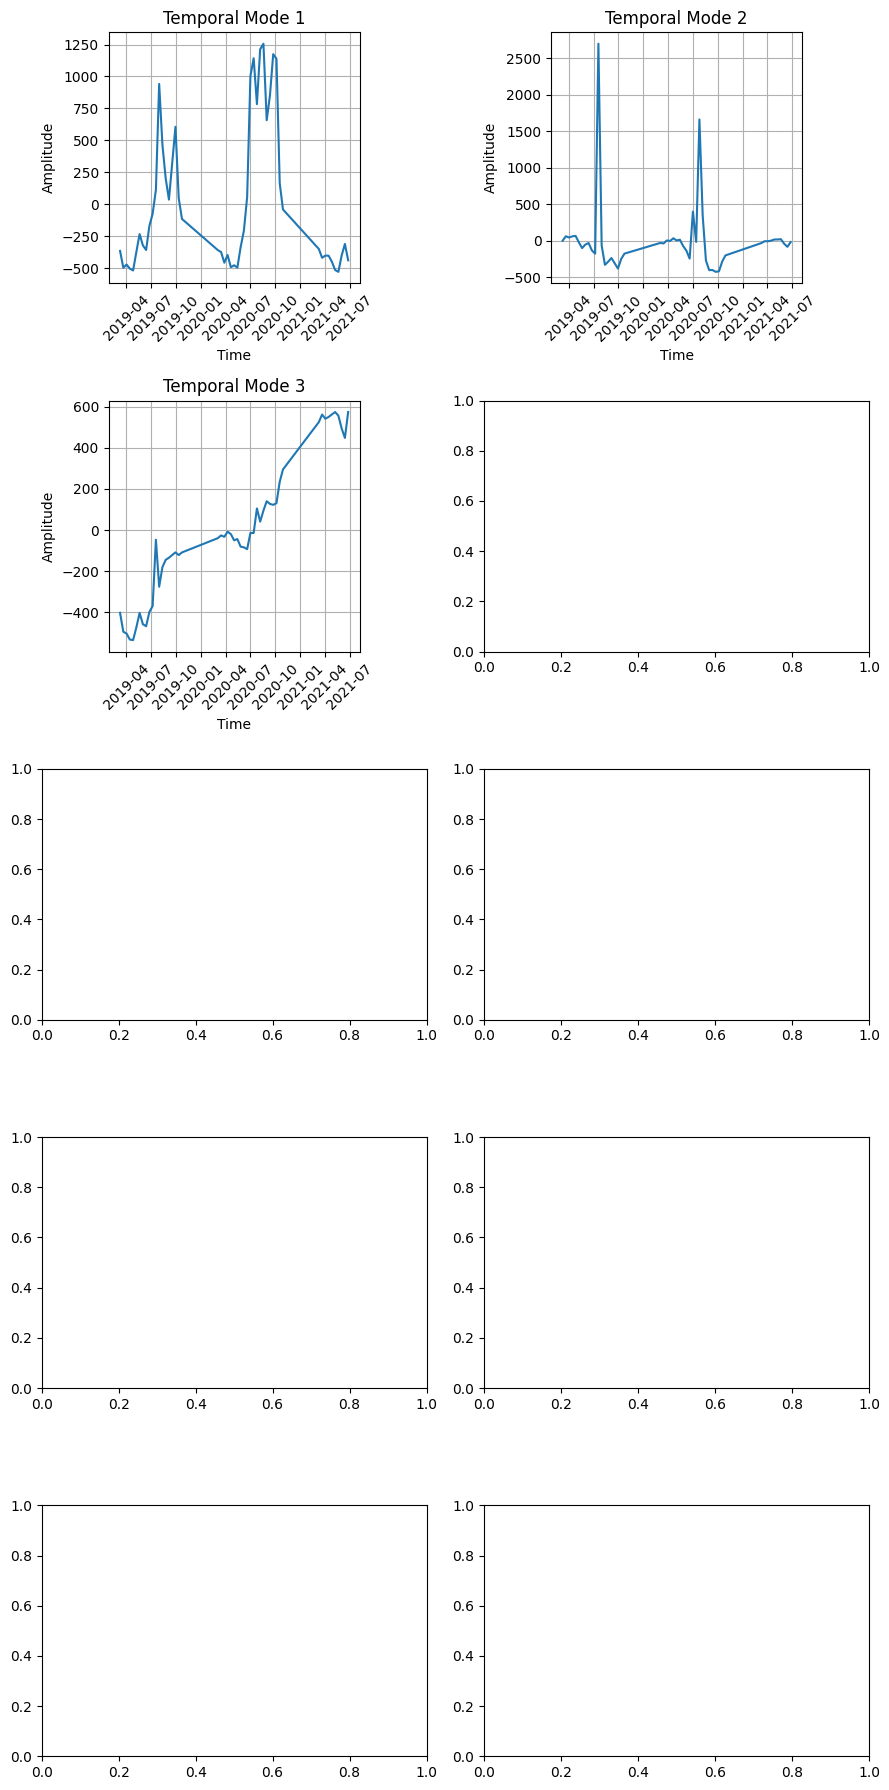

In [67]:
num_modes = vis_modes

# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(5, 2, figsize=(9, 18))

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    # ax.scatter(reof_ds.time, reof_ds.temporal_modes[i], label=f'Mode {i+1}', s=10)
    ax.plot(reof_ds.time, reof_ds.temporal_modes[i])
    ax.set_title(f'Temporal Mode {i+1}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.grid()
    ax.set_box_aspect(1)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

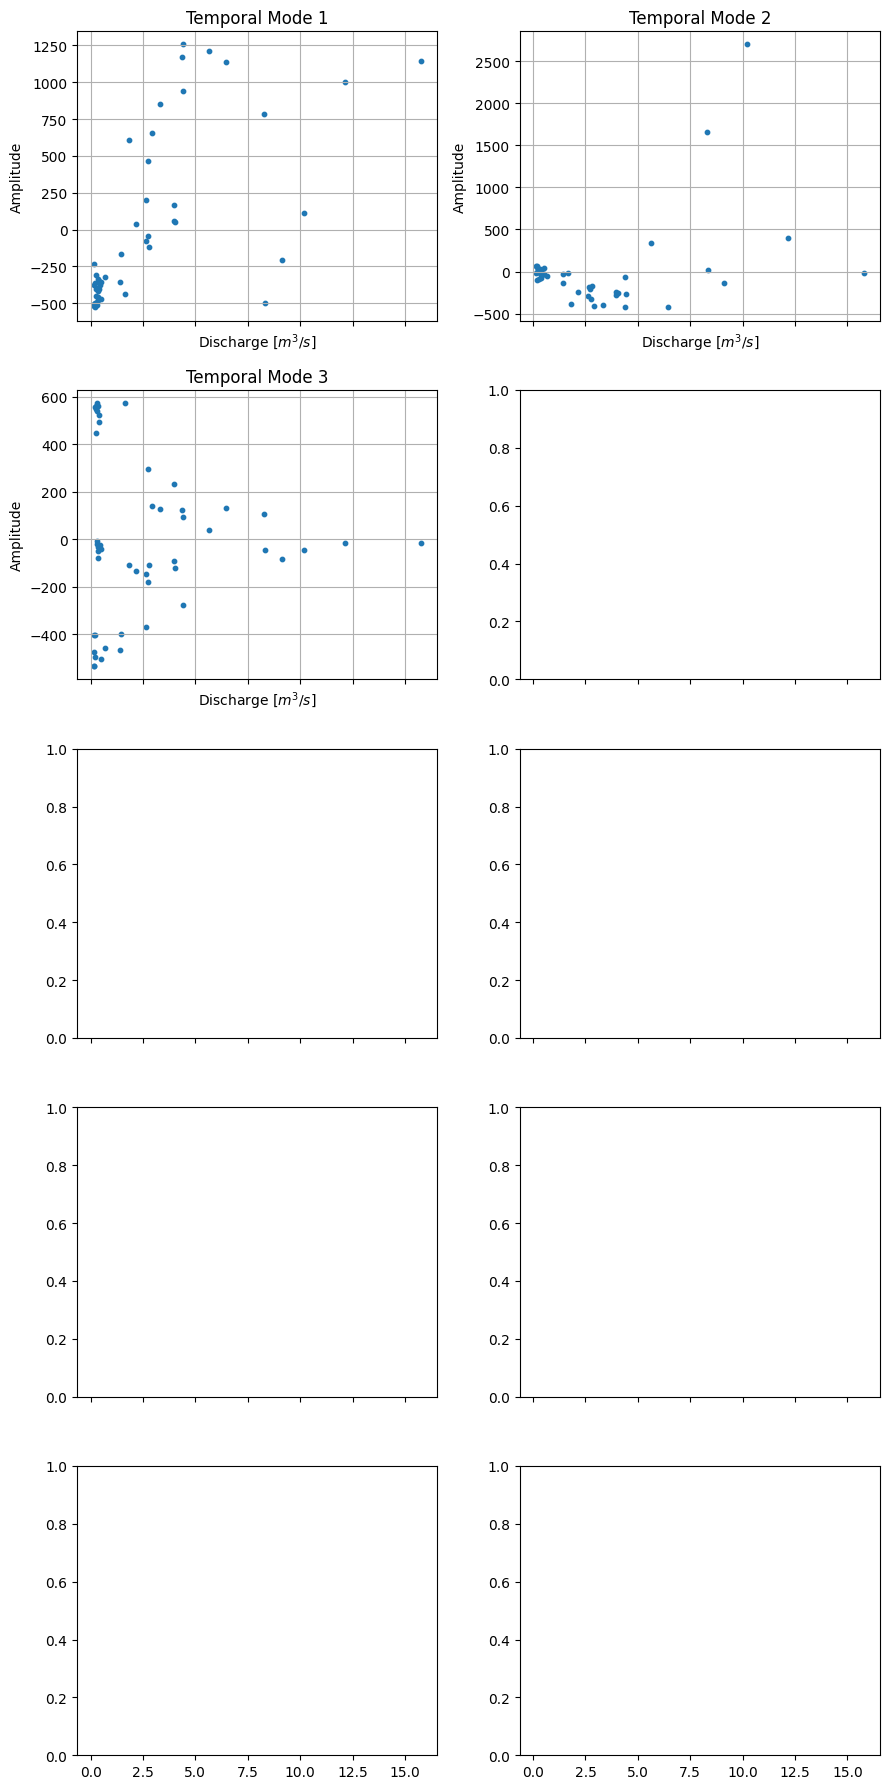

In [68]:
# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(5, 2, figsize=(9, 18), sharex=True)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    ax.scatter(q.values, reof_ds.temporal_modes[i], label=f'Mode {i+1}', s=10)
    ax.set_title(f'Temporal Mode {i+1}')
    ax.set_xlabel('Discharge [$m^3/s$]')
    ax.set_ylabel('Amplitude')
    ax.grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### Visualize Spatial Modes

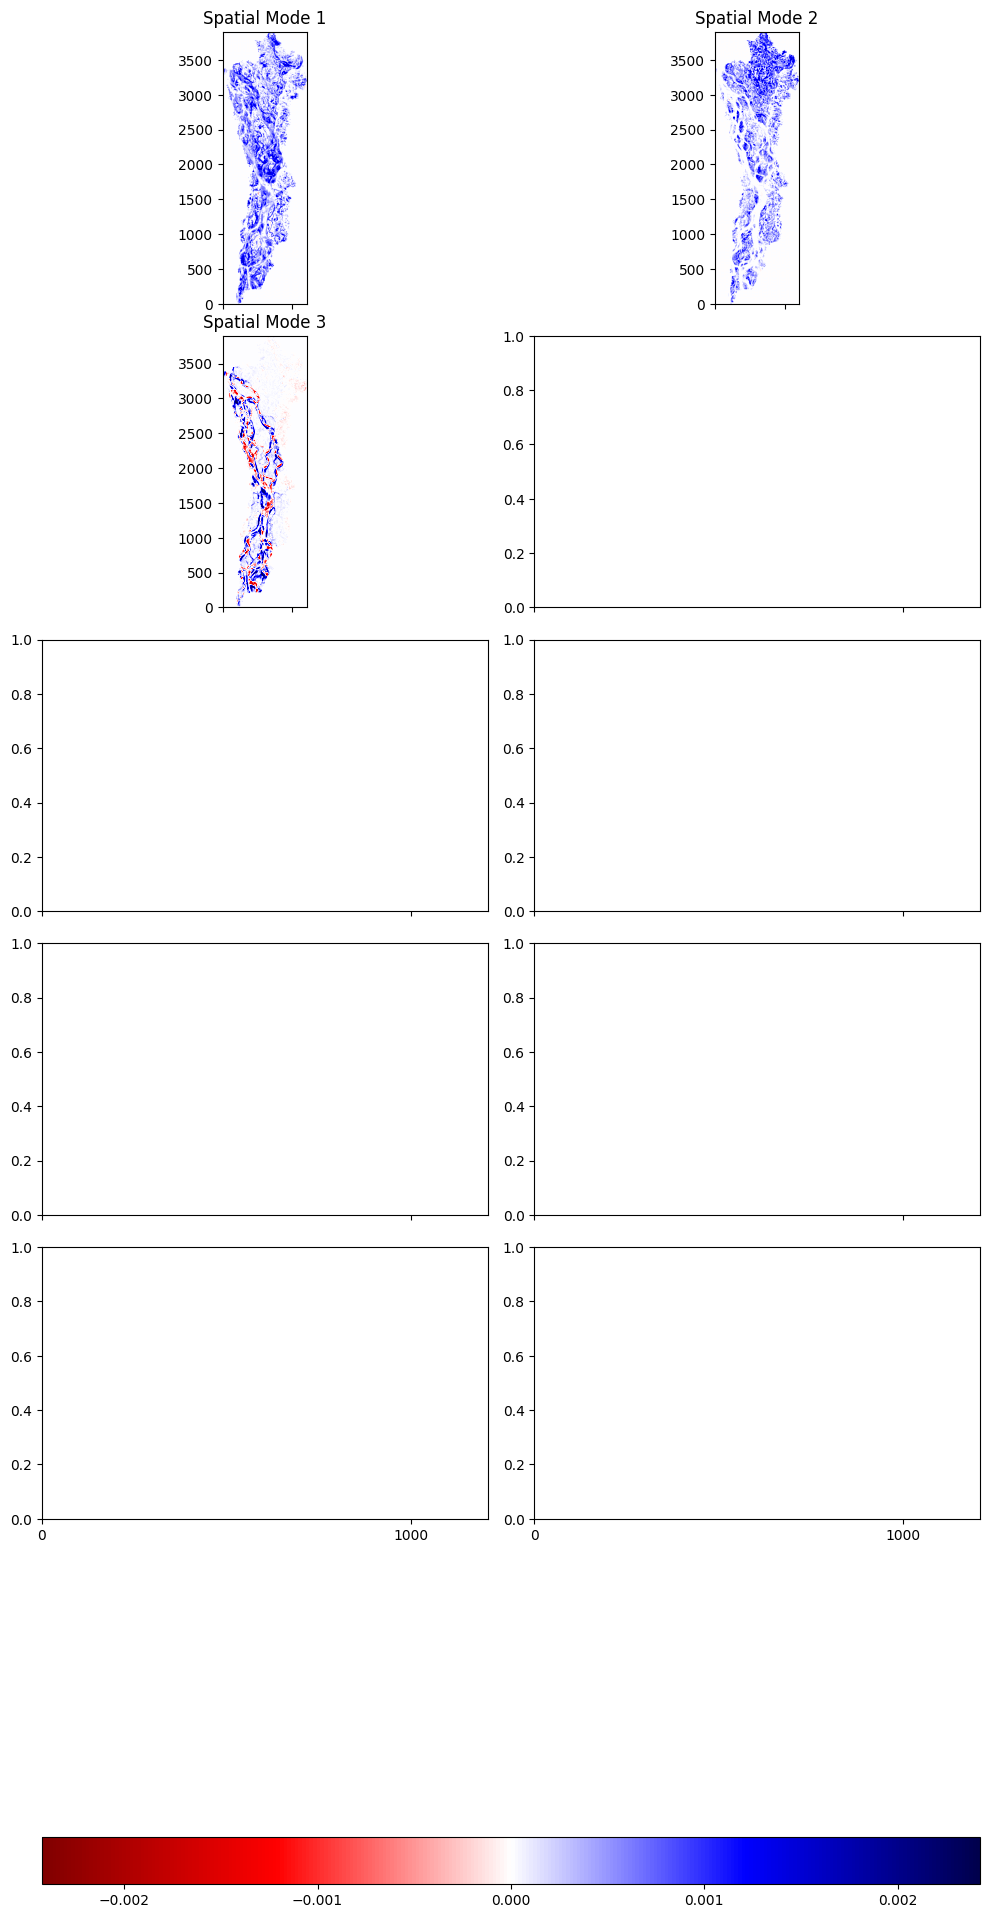

In [69]:
import matplotlib.colors as colors

# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(5, 2, figsize=(10, 22), sharex=True)

# Flatten axes array for easier indexing
axes = axes.flatten()

# cb_min, cb_max = np.amin(reof_ds.spatial_modes.values), np.amax(reof_ds.spatial_modes.values) # original
cb_min, cb_max = np.amin(reof_ds.spatial_modes.values[0:num_modes, :, :]), np.amax(reof_ds.spatial_modes.values[0:num_modes, :, :]) # changed to avoid poor display of modes (most are very close to middle values, not the maxs/mins)

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    spatial_mode = reof_ds.spatial_modes.values[i,:,:]
    norm = colors.TwoSlopeNorm(vmin=cb_min, vcenter = 0, vmax=cb_max)
    im = ax.imshow(spatial_mode, label=f'Mode {i+1}', cmap='seismic_r', norm=norm, origin='lower')
    ax.set_title(f'Spatial Mode {i+1}')

# create horizontal colorbar


# Adjust layout and show the plot
plt.tight_layout()
fig.colorbar(im, ax=axes, location='bottom', orientation='horizontal')
plt.show()

## Find best fits polynomial and NN

- Choose the maximum amount of polynomial degrees to evaluate for the fit
- Choose the NSE-score cutoff used to keep polynomial fits as valuable

In [70]:
### --- Initialize parameters --- ###

# set the status of 'Despike'
myDespike = {
    "despike": True,
    "type": 'median_all', 
    "window": 11,
    "multiplier": 5,
    "plotIt": True
}

### --- CHOOSE THE MAX DEGREE OF THE POLYNOMIALS TO EVALUATE --- ###
num_deg = 5

# set save location for mode fitting figures. 
myFittingSaveLoc = Path(fc.selected, 'Figures', f'fittingModes-{myDim}_{datetime.now().strftime("%Y%m%d")}_NSE={str(NSE_cut).replace(".","p")}_modes={str(num_modes)}')
print(f'Save location for plots of mode fitting: {myFittingSaveLoc}')

# Change figure settings
figSize = [6, 4] # figure size
fontSize_new = 14 # figure text size
plt.rcParams.update({'font.size':fontSize_new})
# Set the axes limits (optional) 
x0, x1 = np.amin(q_smoothed.values), np.amax(q_smoothed.values)
x_diffy = np.abs( x1-x0 ) / 10.0
y0, y1 = np.amin(reof_ds.temporal_modes.values), np.amax(reof_ds.temporal_modes.values)
y_diffy = np.abs( y1-y0 ) / 10.0
myAxes = [[x0-x_diffy, x1+x_diffy],
          [y0-y_diffy, y1+y_diffy]]

Save location for plots of mode fitting: /home/jovyan/Dataset/bang-West_30m/subset_bangladesh-West/Figures/fittingModes-discharge_20251002_NSE=0p001_modes=3


Calculting fit 1 of 6...


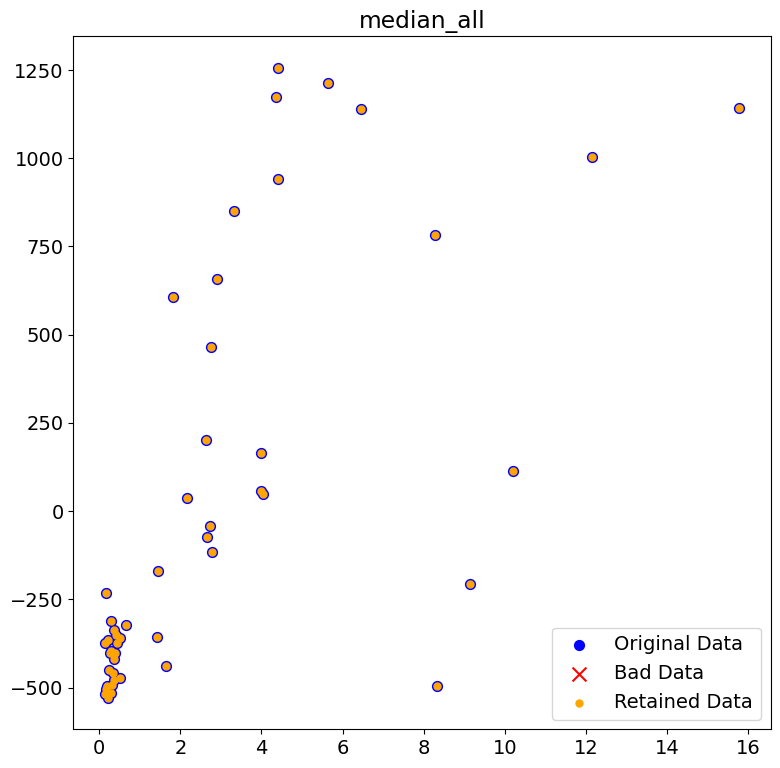

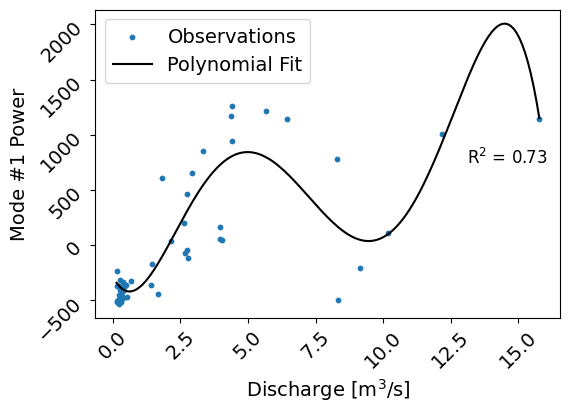

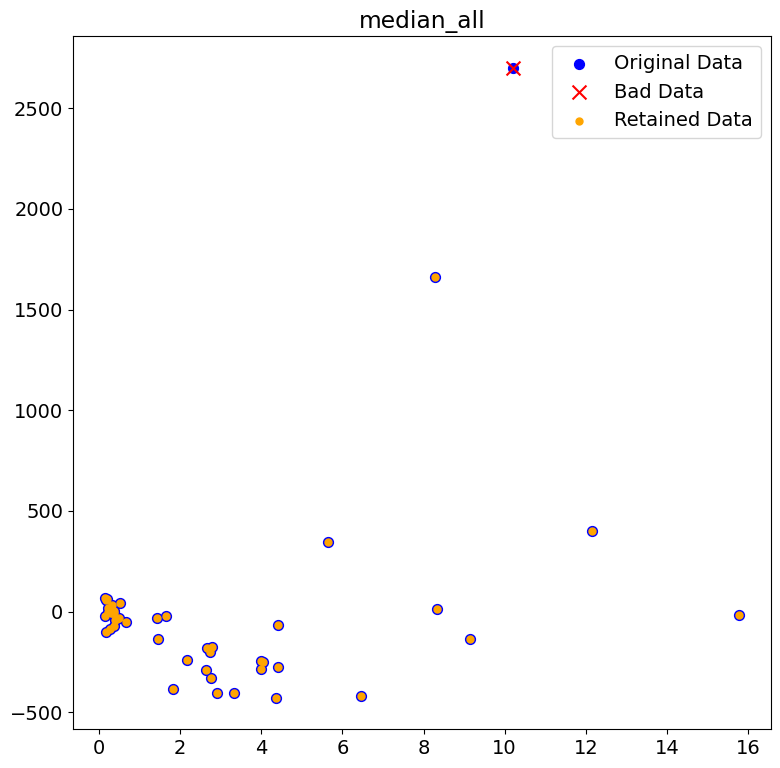

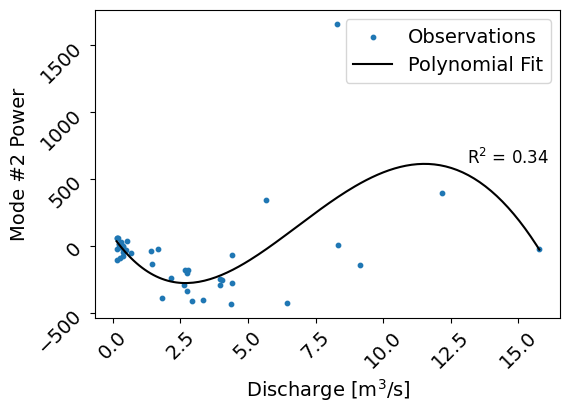

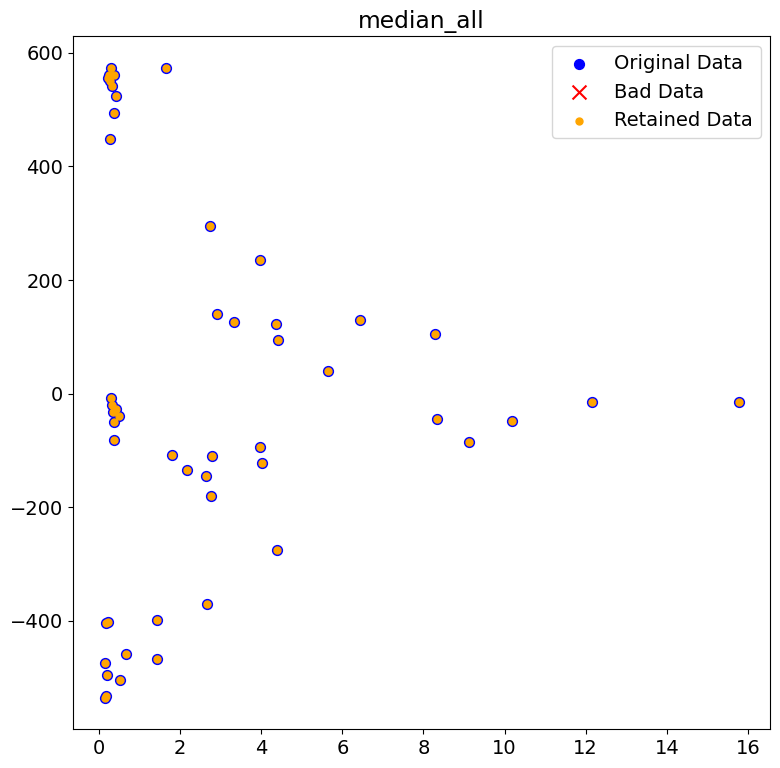

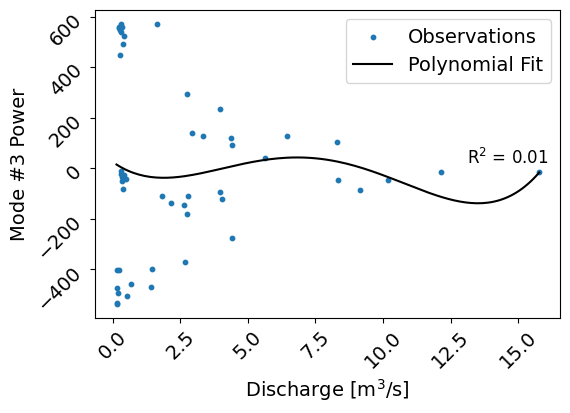

Polynomial fits found for modes: [1, 2, 3]
degrees: [5, 4, 4]
Smoothing_frame = 0

Calculting fit 2 of 6...


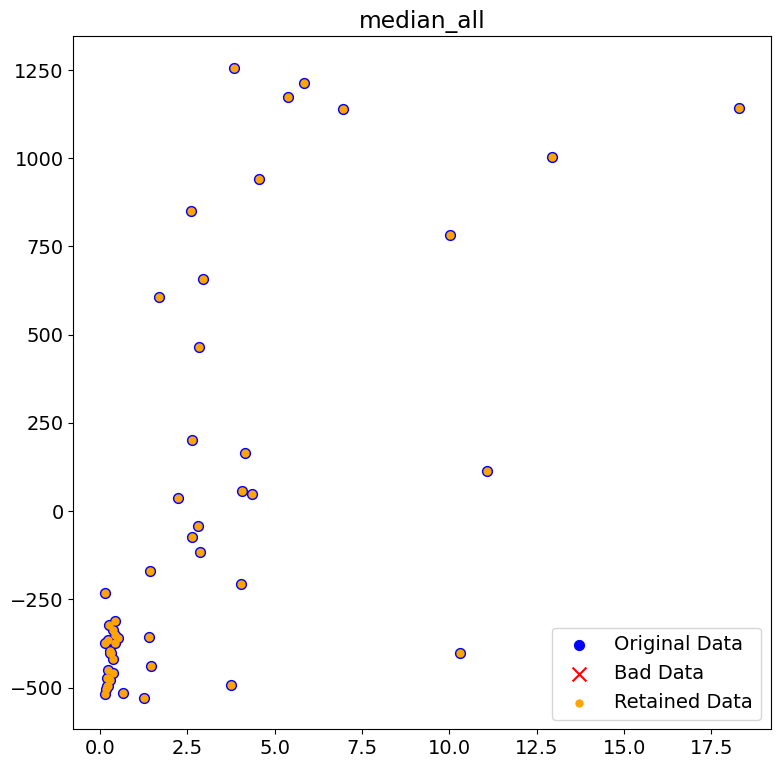

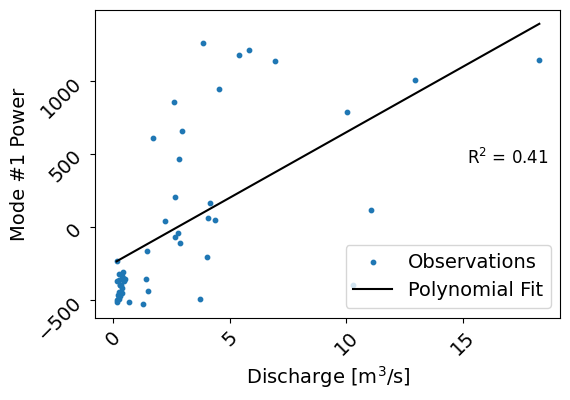

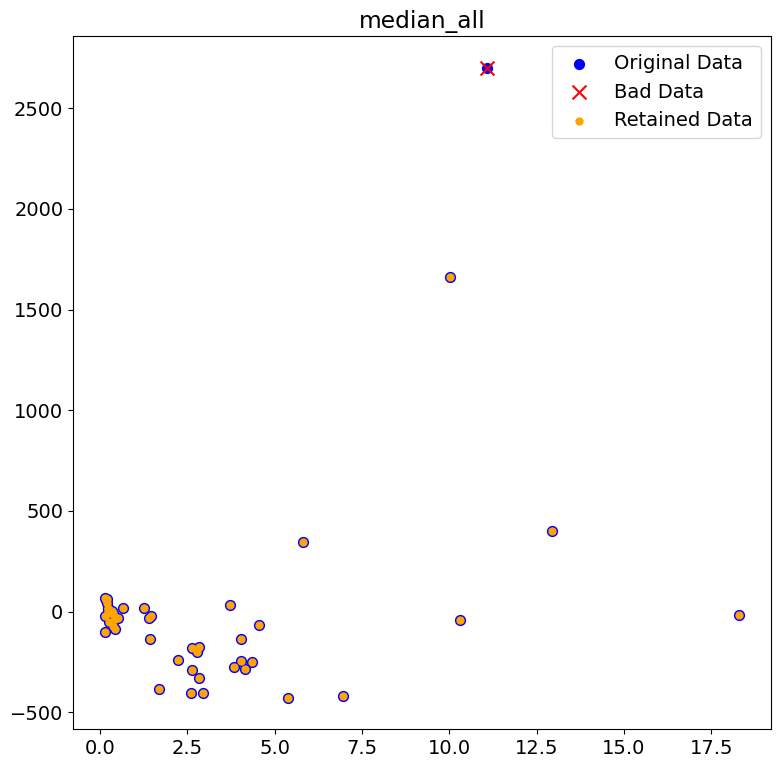

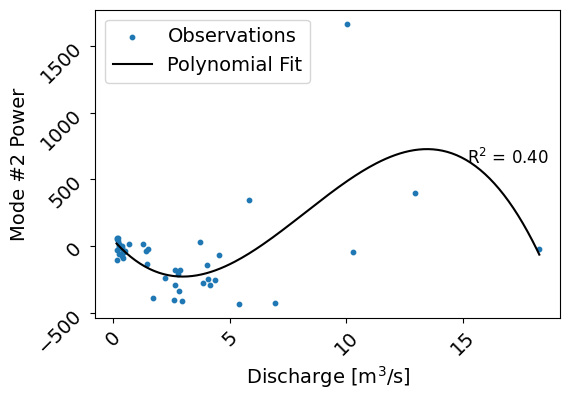

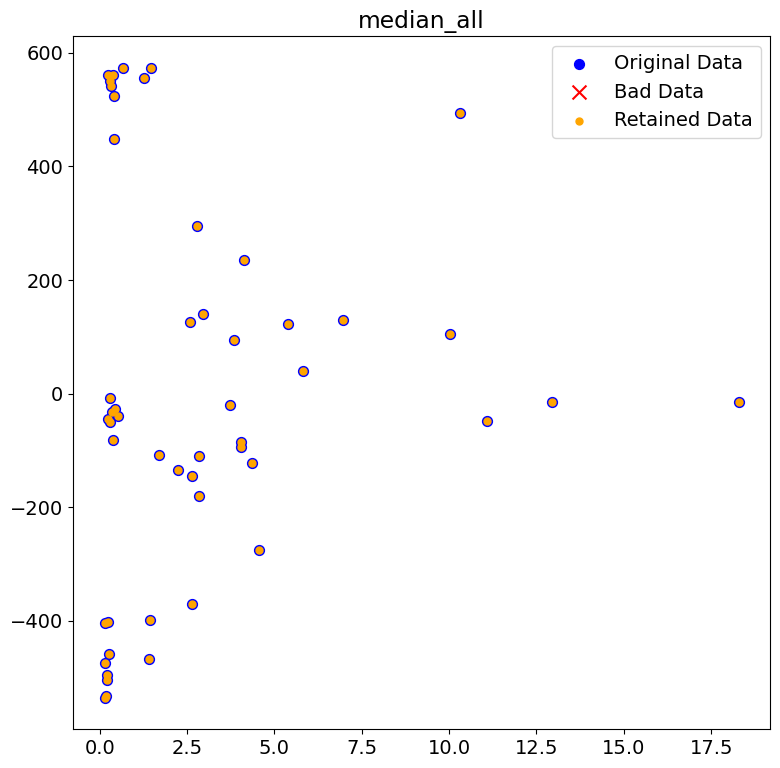

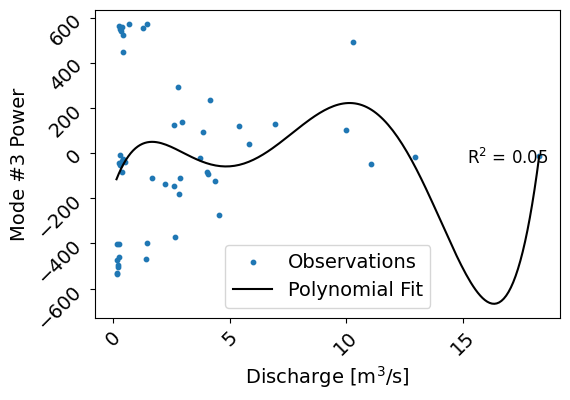

Polynomial fits found for modes: [1, 2, 3]
degrees: [1, 3, 5]
Smoothing_frame = 2

Calculting fit 3 of 6...


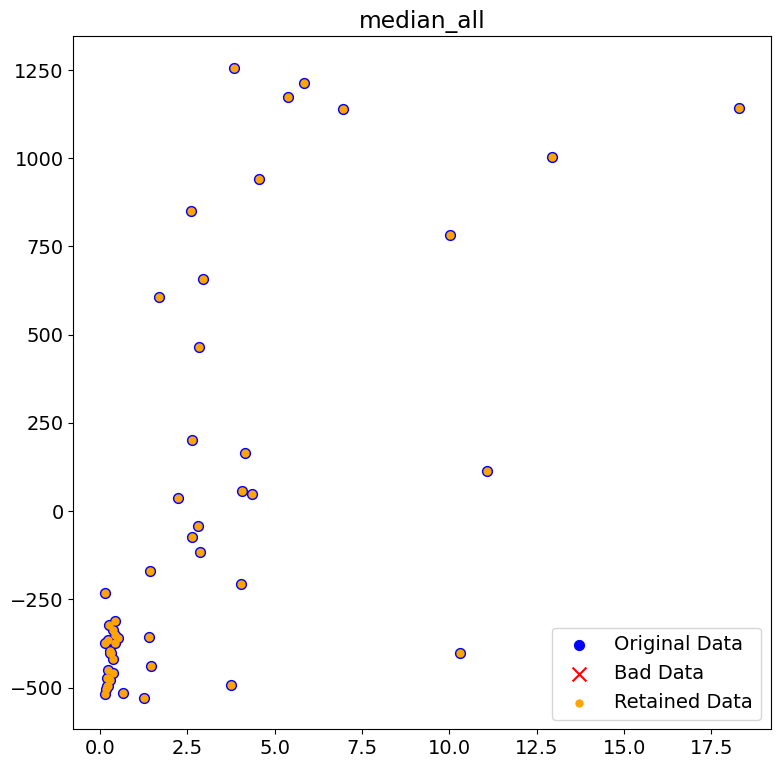

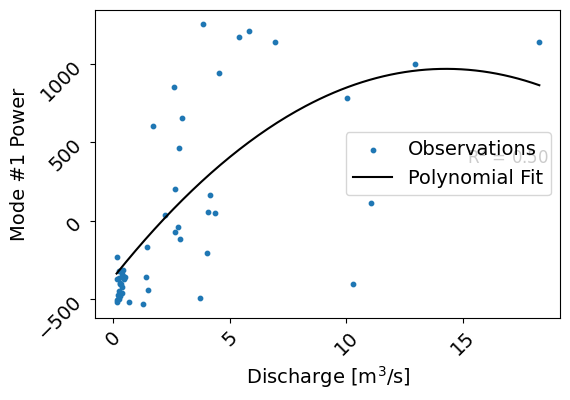

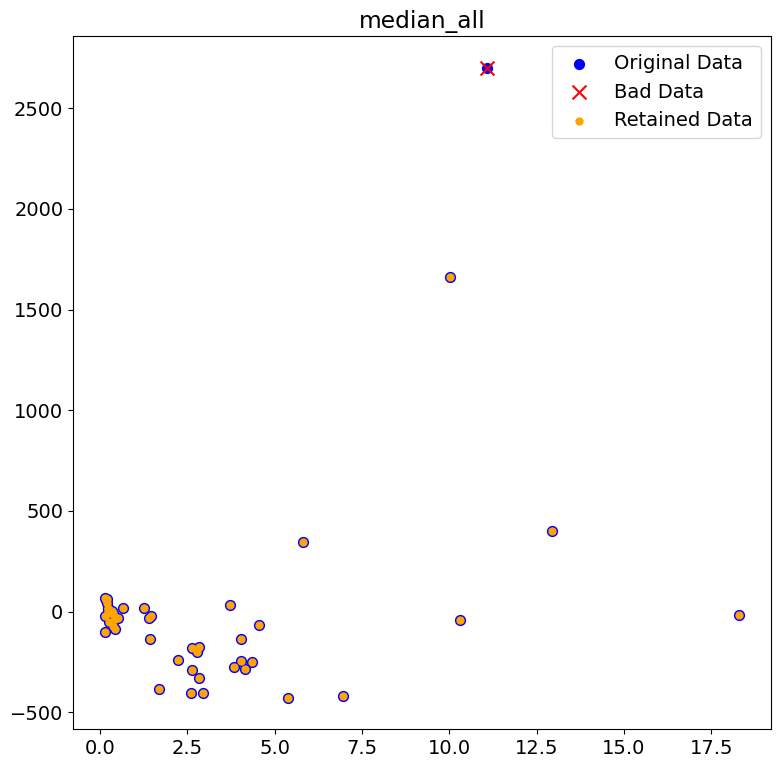

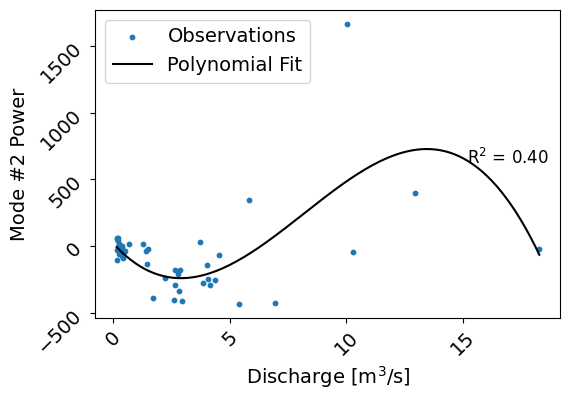

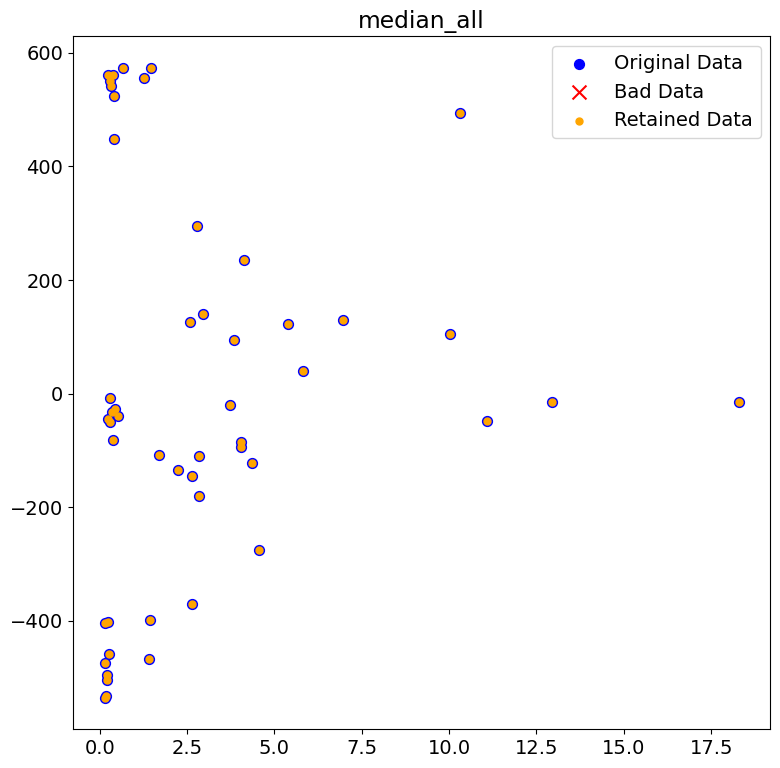

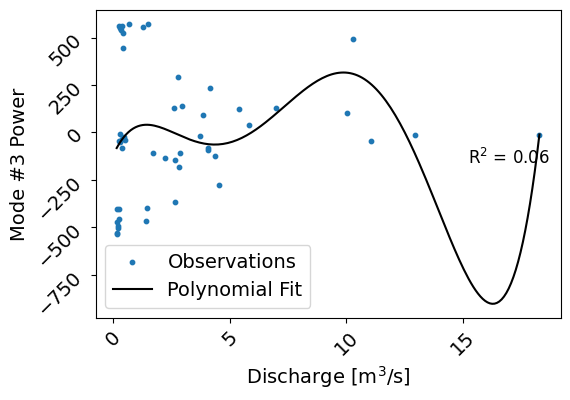

Polynomial fits found for modes: [1, 2, 3]
degrees: [2, 3, 5]
Smoothing_frame = 3

Calculting fit 4 of 6...


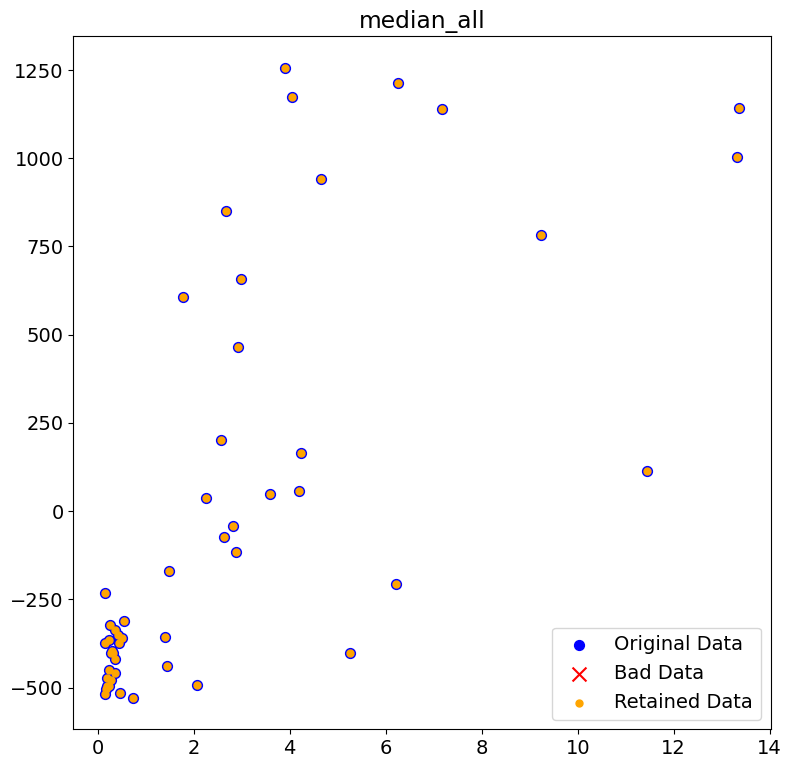

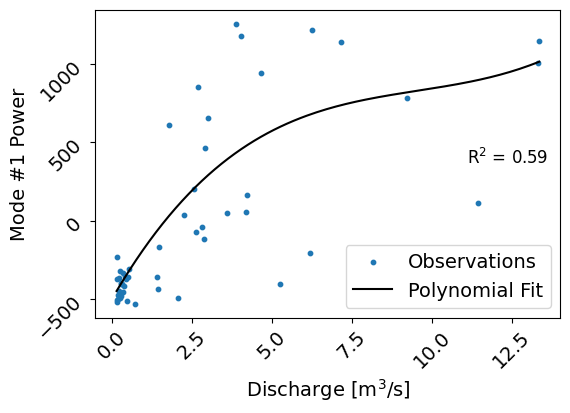

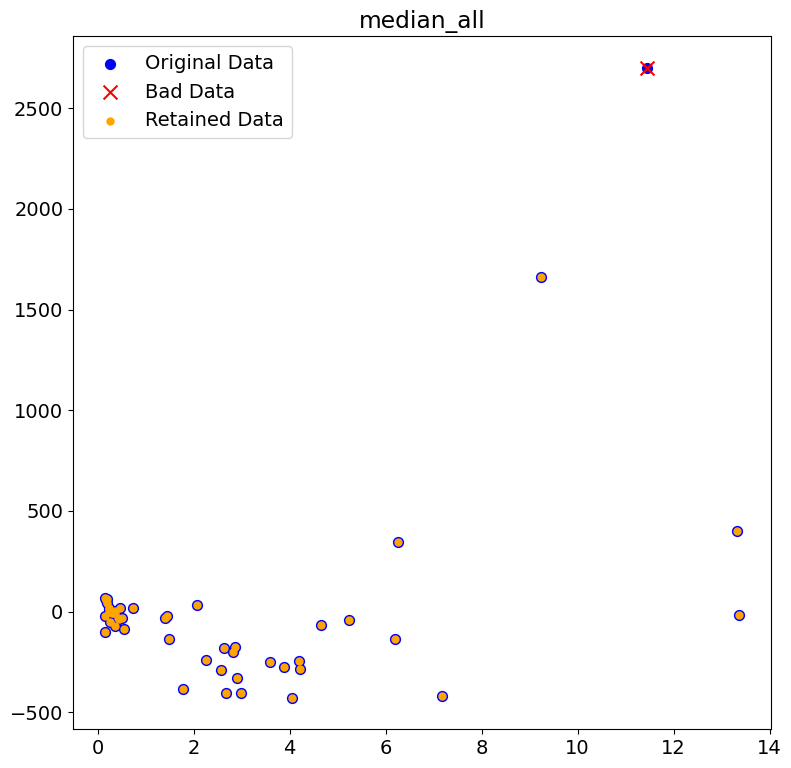

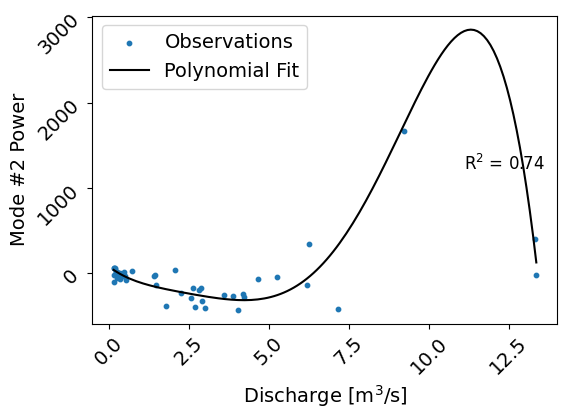

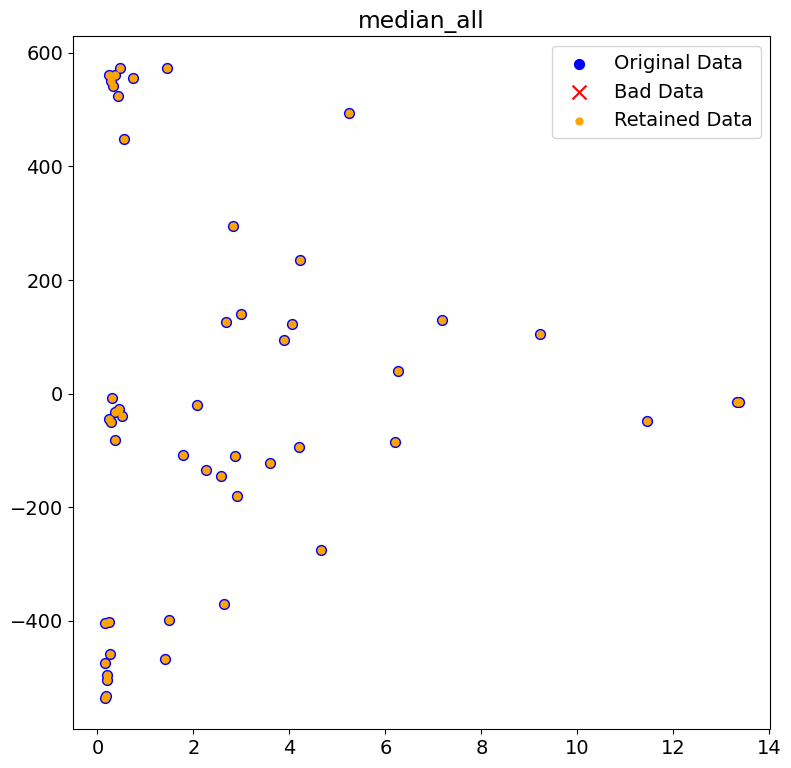

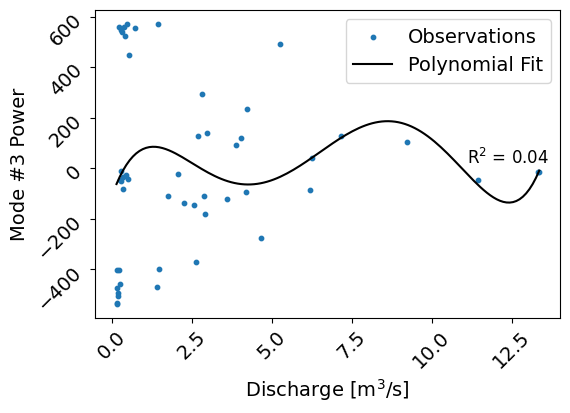

Polynomial fits found for modes: [1, 2, 3]
degrees: [3, 5, 5]
Smoothing_frame = 4

Calculting fit 5 of 6...


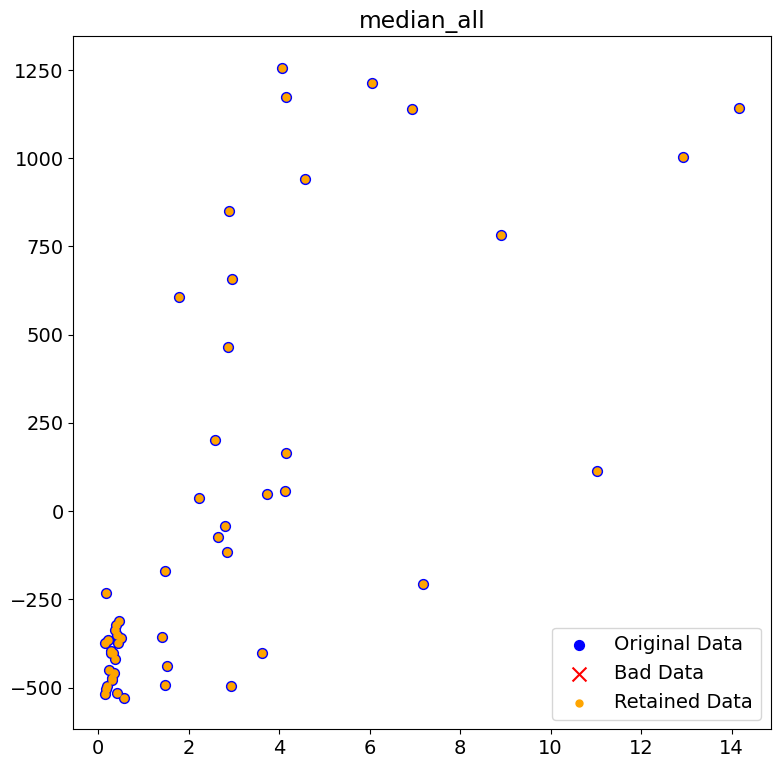

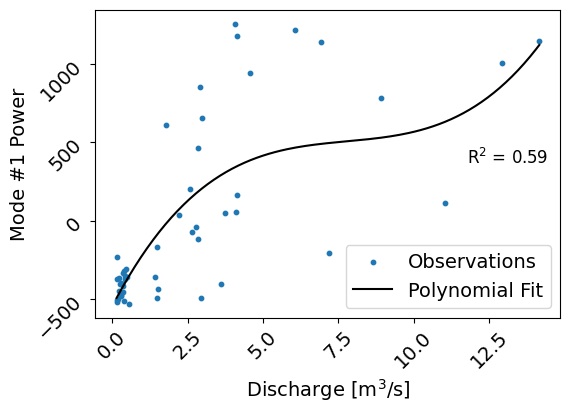

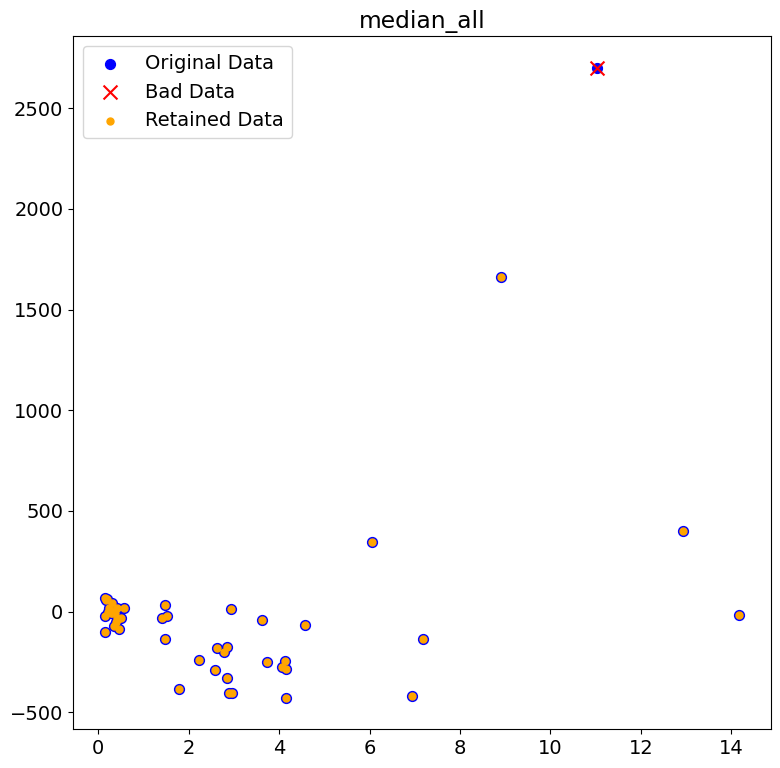

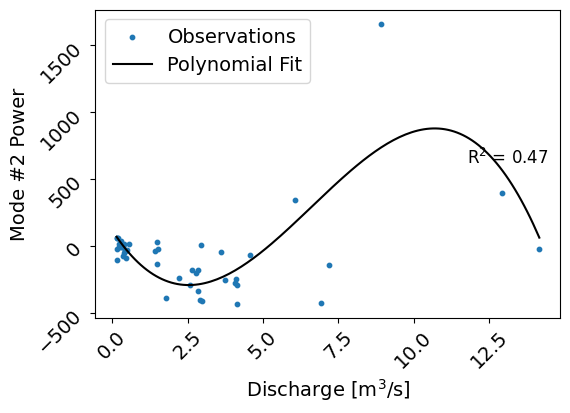

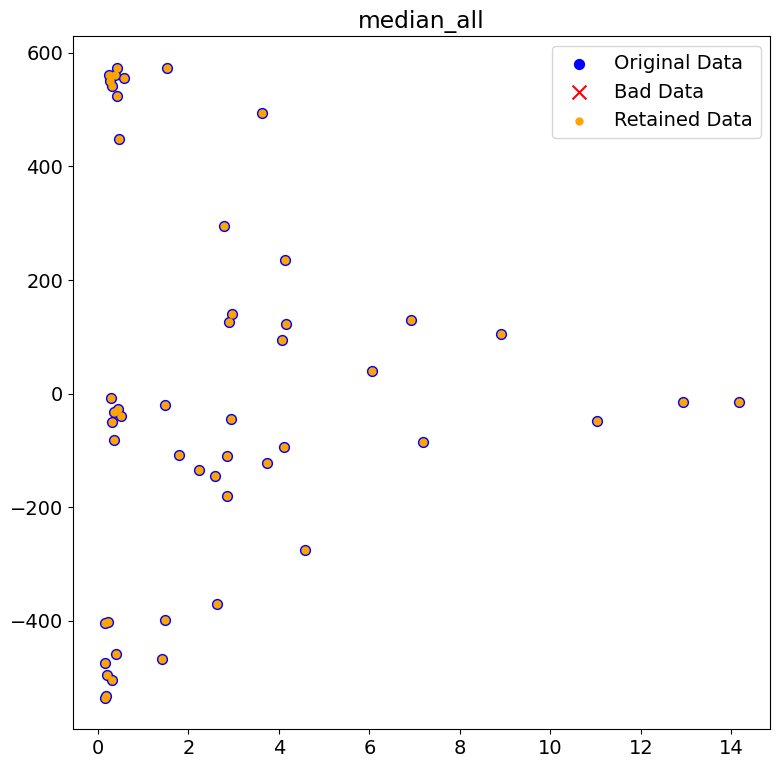

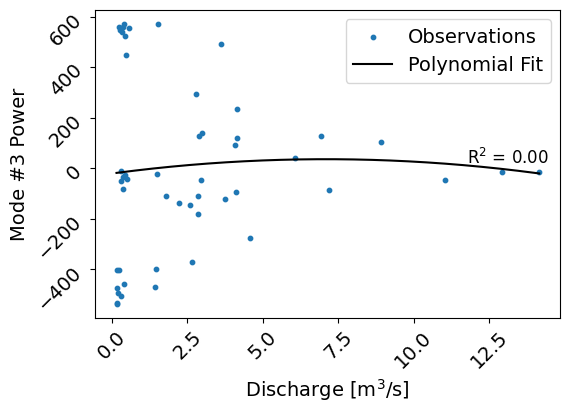

Polynomial fits found for modes: [1, 2, 3]
degrees: [3, 3, 2]
Smoothing_frame = 5

Calculting fit 6 of 6...


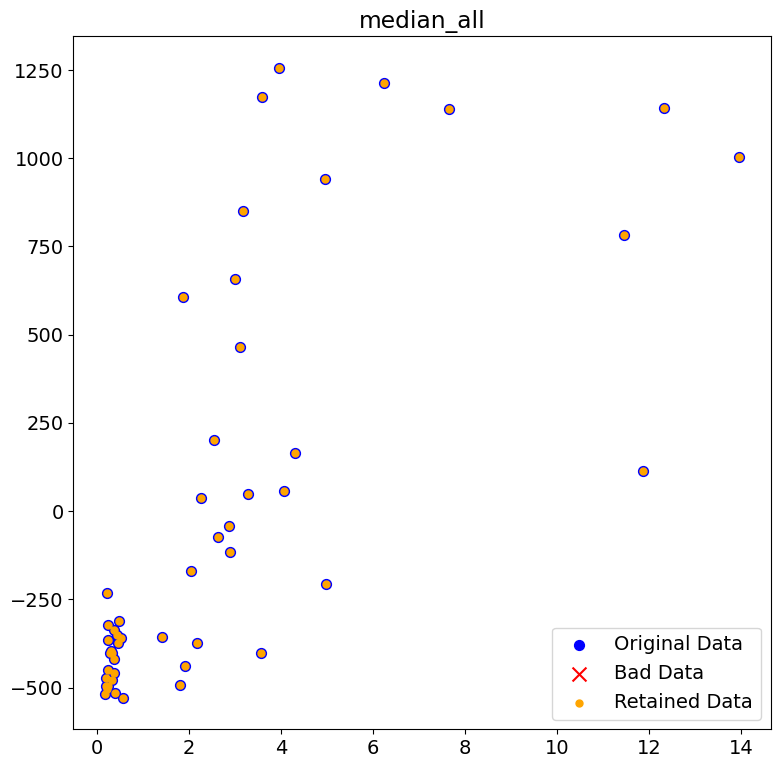

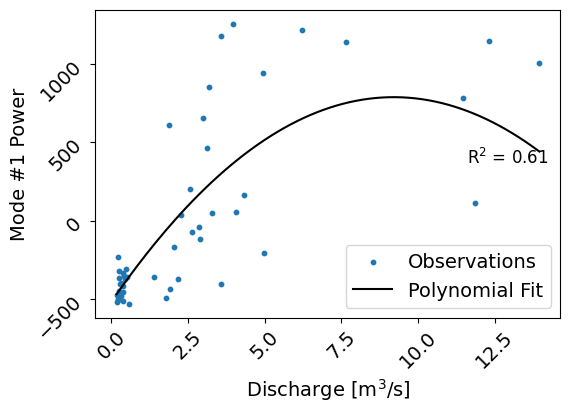

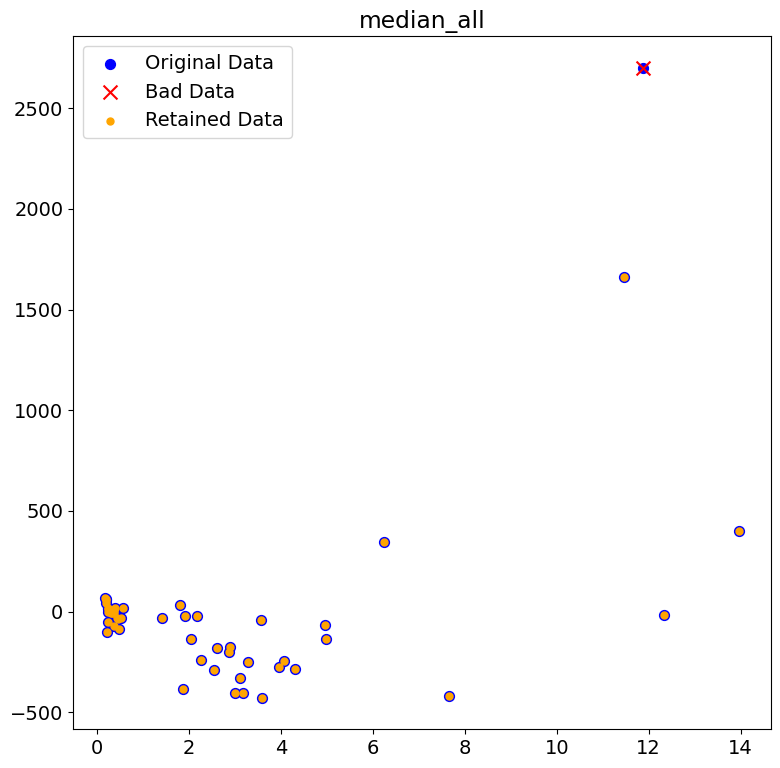

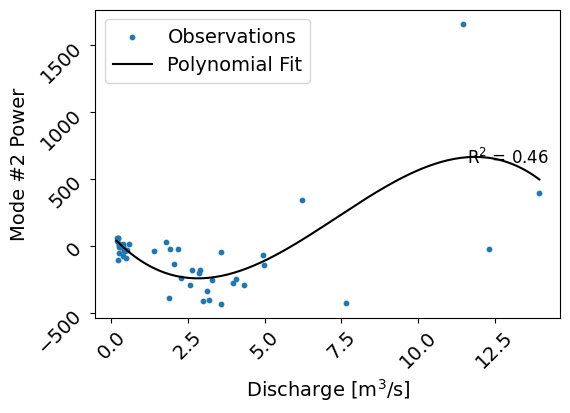

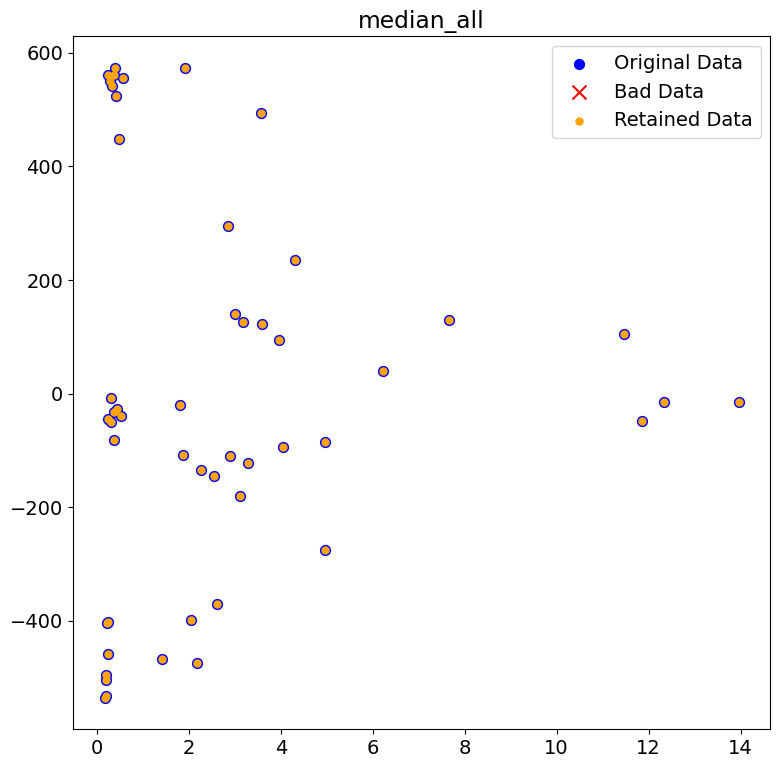

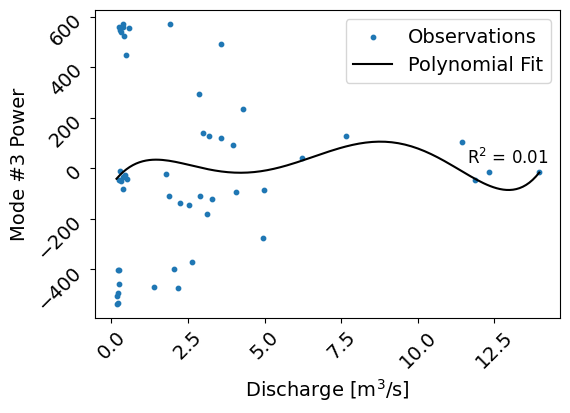

Polynomial fits found for modes: [1, 2, 3]
degrees: [2, 3, 5]
Smoothing_frame = 6



In [71]:
# Initialize containers for output results
modes_poly_smoothed = []
degs_smoothed       = []
polys_smoothed      = []
NSEs_poly_smoothed  = []

### --- Loop through each entry of 'smoothing_frame' to get polynomial fits --- ###
for i in range(0,len(smoothing_frame)):
    print(f'Calculting fit {i+1} of {len(smoothing_frame)}...')
    if len(smoothing_frame) == 1:
        modes_poly_s, degs_s, polys_s, NSEs_poly_s = best_polynomial_fits(reof_ds, q_smoothed, num_deg, NSE_cut, myDespike, fittingSaveLoc=myFittingSaveLoc, s_f=smoothing_frame[i], figSize=figSize, max_modes=num_modes, myAxes=None, datesOnGraphs=False)
    else:
        modes_poly_s, degs_s, polys_s, NSEs_poly_s = best_polynomial_fits(reof_ds, q_smoothed[i], num_deg, NSE_cut, myDespike, fittingSaveLoc=myFittingSaveLoc, s_f=smoothing_frame[i], figSize=figSize, max_modes=num_modes, myAxes=None, datesOnGraphs=False)
    modes_poly_smoothed.append(modes_poly_s)
    degs_smoothed.append(degs_s)
    polys_smoothed.append(polys_s)
    NSEs_poly_smoothed.append(NSEs_poly_s)
    if modes_poly_s == []:
        print(f'No polynomial fits were found with NSE >= {NSE_cut}\nSmoothing_frame = {smoothing_frame[i]}\n')
    else:
        print(f'Polynomial fits found for modes: {modes_poly_s}\ndegrees: {degs_s}\nSmoothing_frame = {smoothing_frame[i]}\n')


Calculting fit 1 of 6...
Building models for mode-01
despike_nn ran


2025-10-02 22:43:18.378915: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.6387834504208052


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.6387834504208052


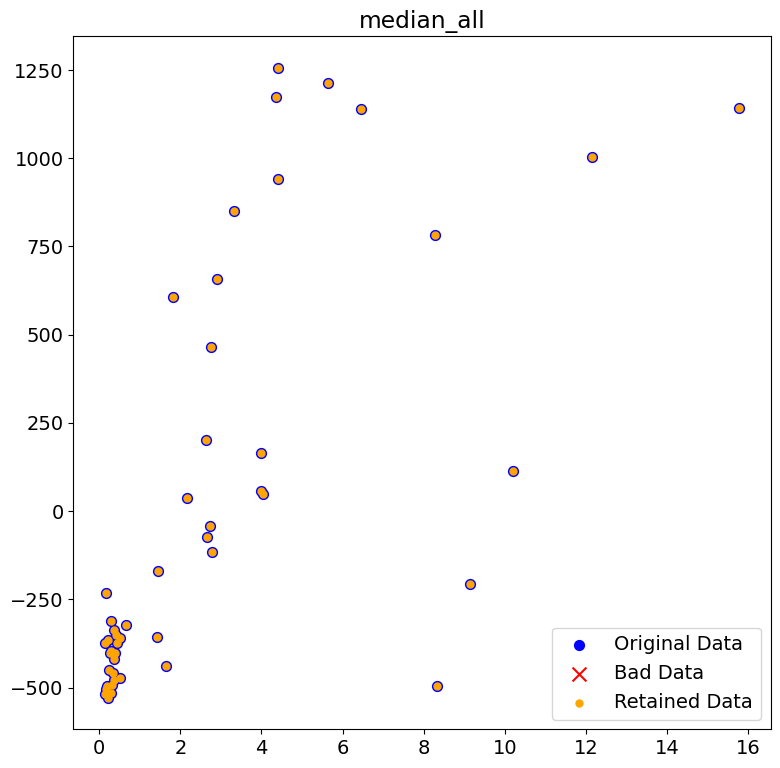

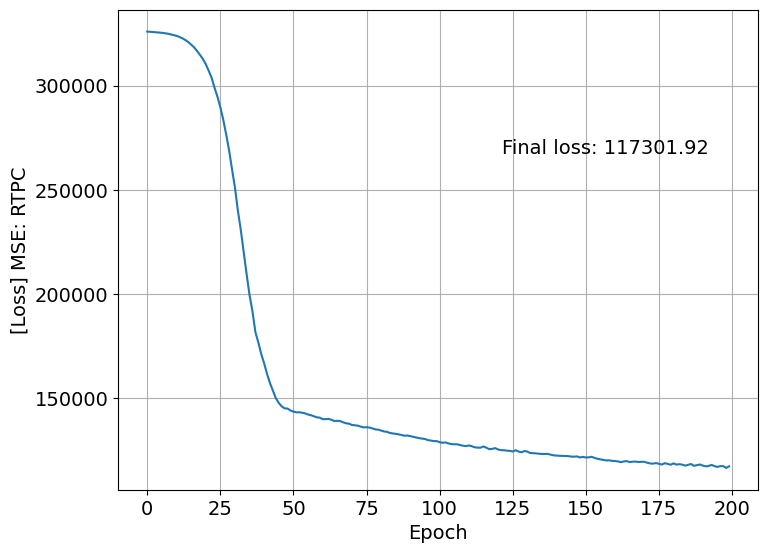

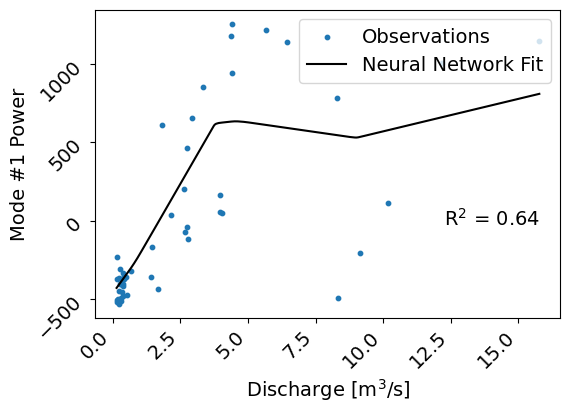

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
R^2 = 0.3255323082812751


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.3255323082812751


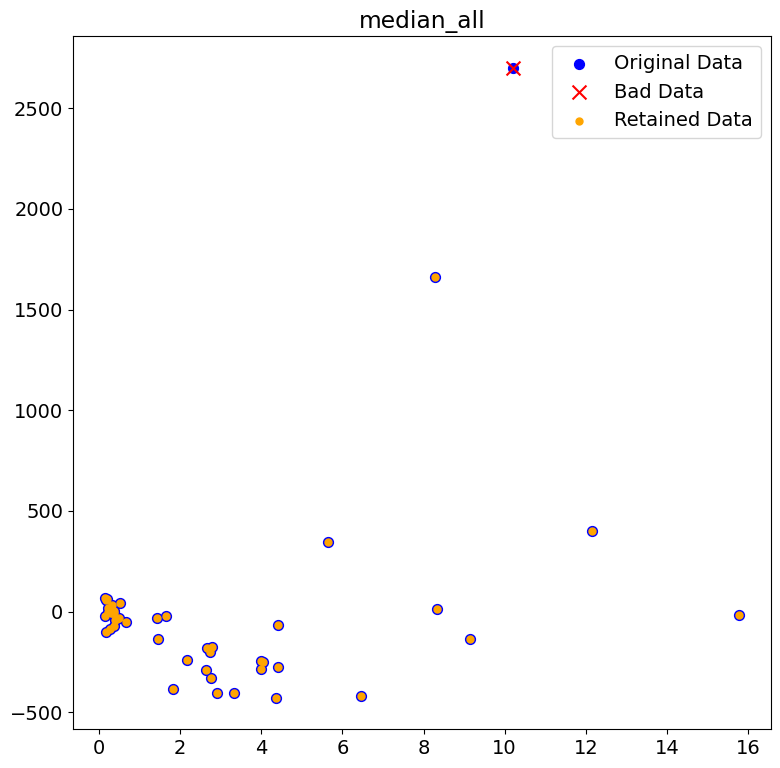

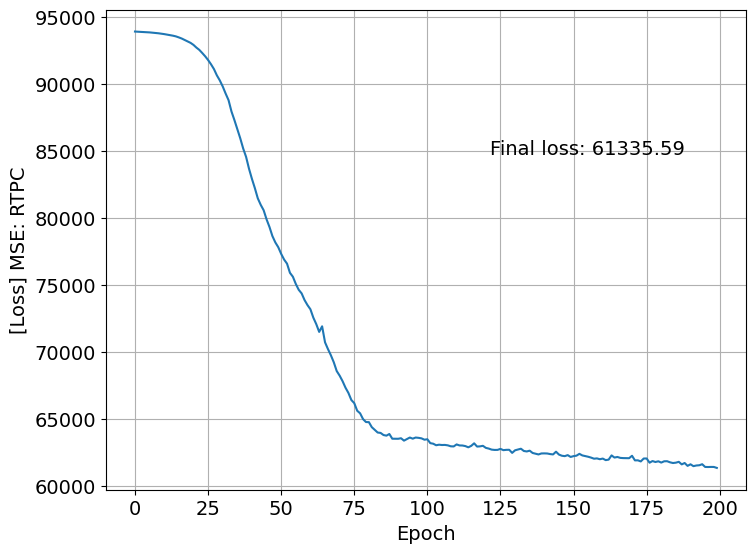

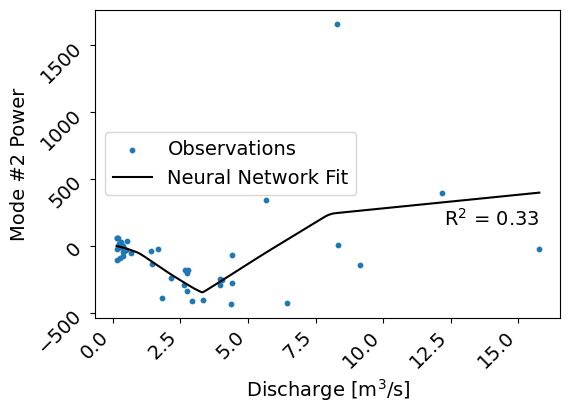

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
R^2 = 0.028629582088709582


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.028629582088709582


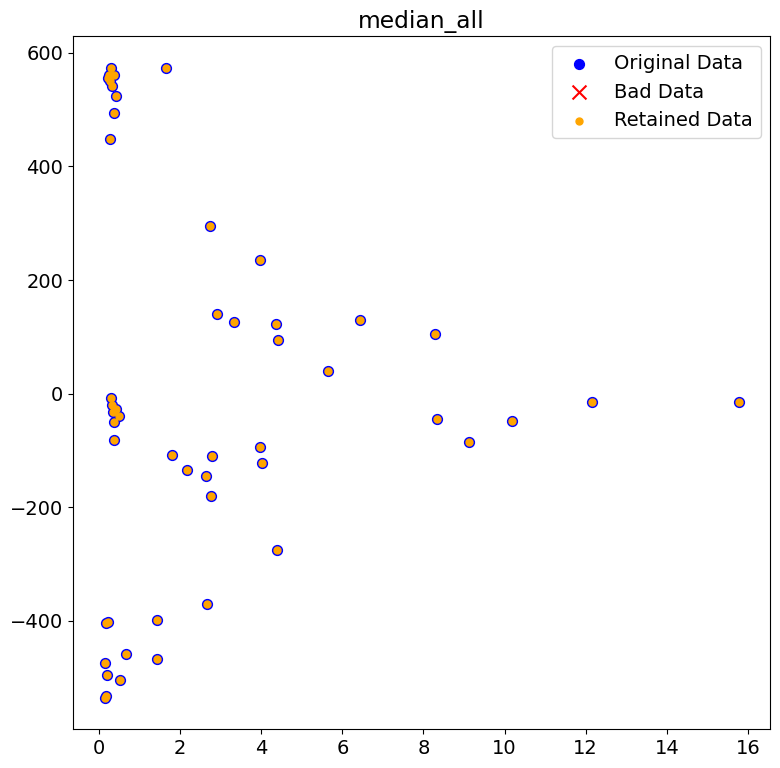

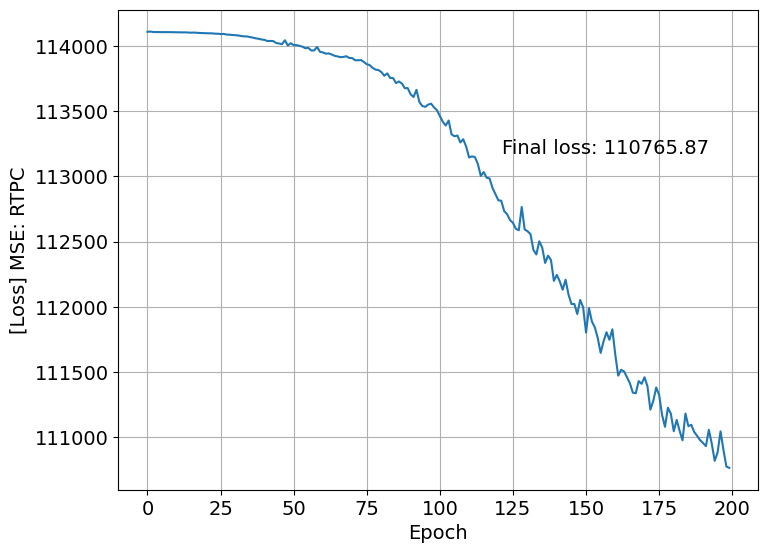

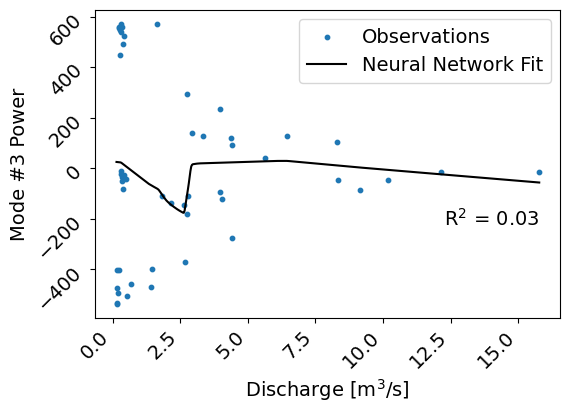

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 0

Calculting fit 2 of 6...
Building models for mode-01
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.552160165136276


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.552160165136276


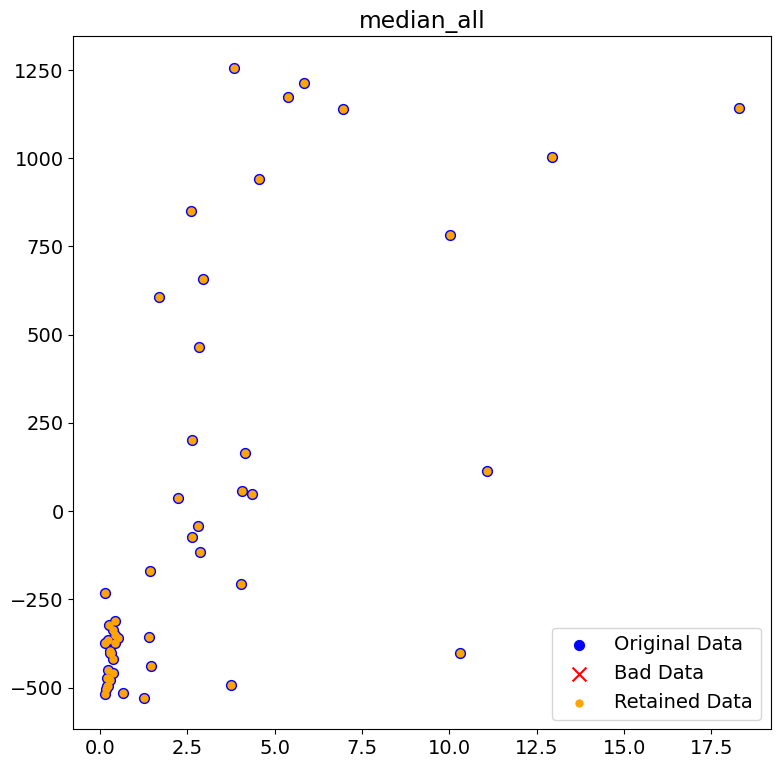

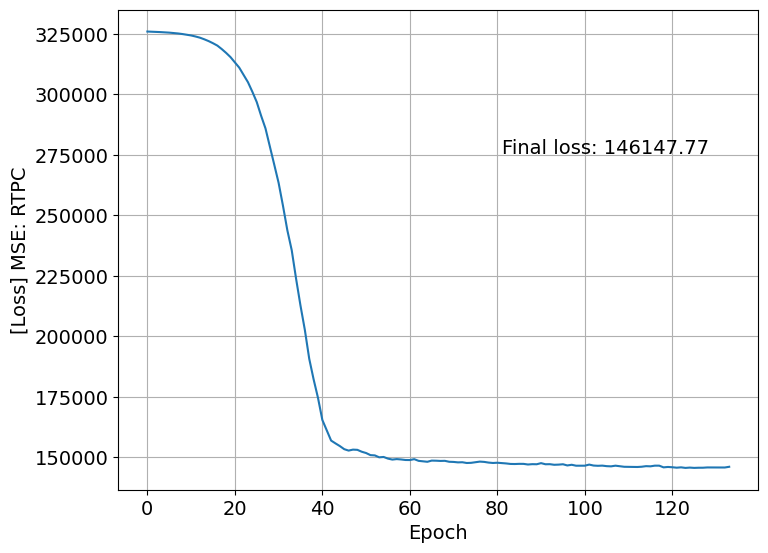

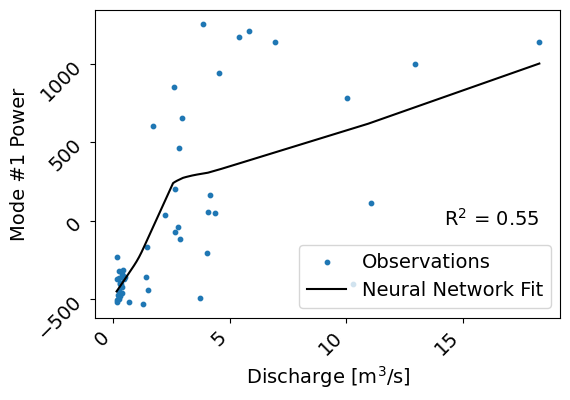

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
R^2 = 0.32525934137950274


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.32525934137950274


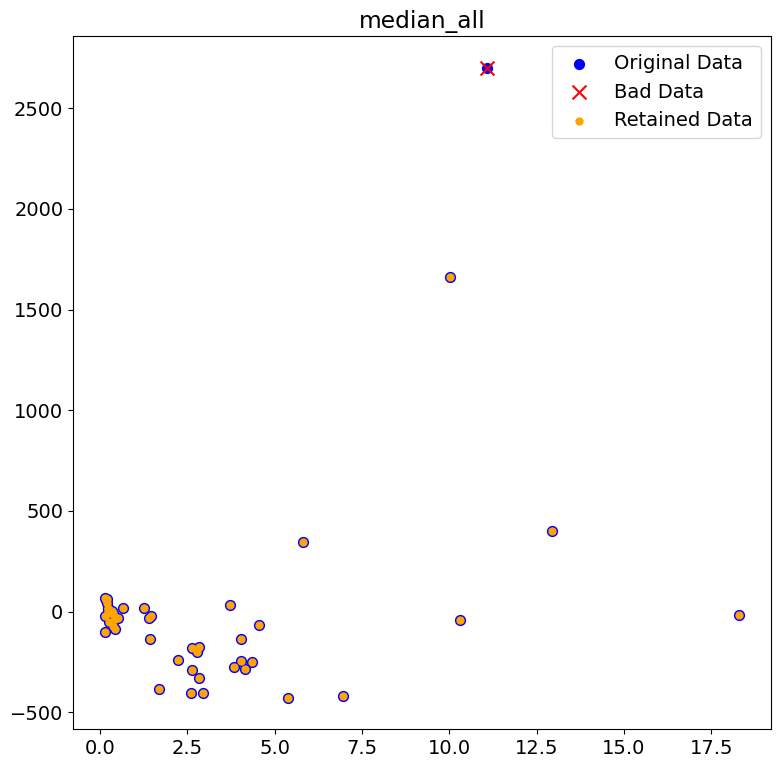

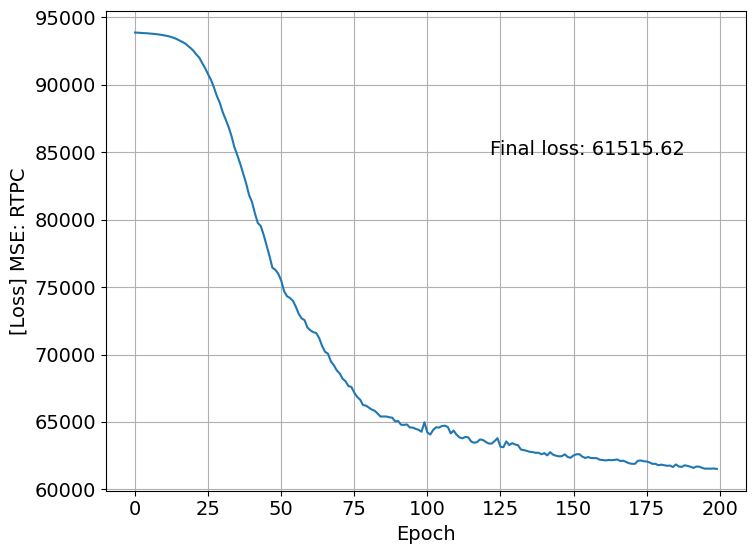

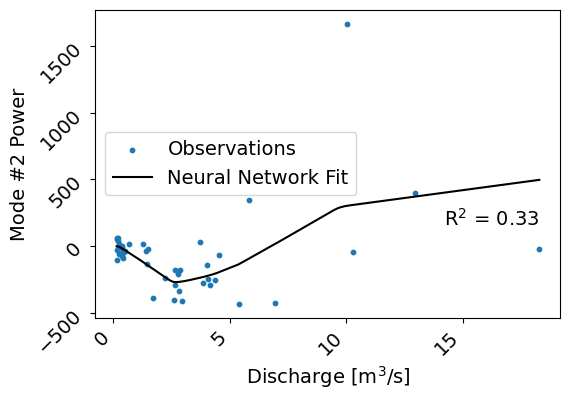

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.008229956431322405


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.008229956431322405


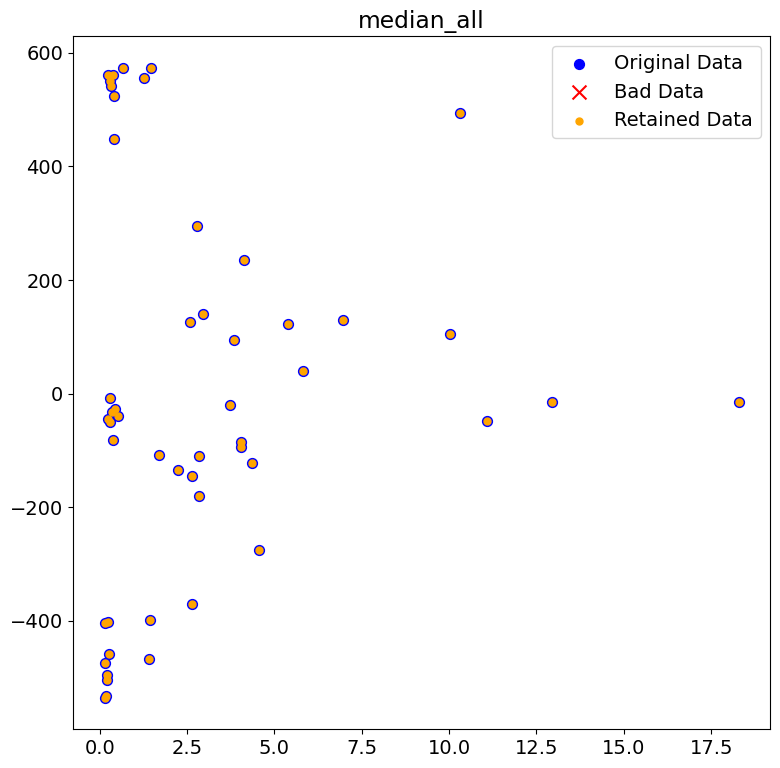

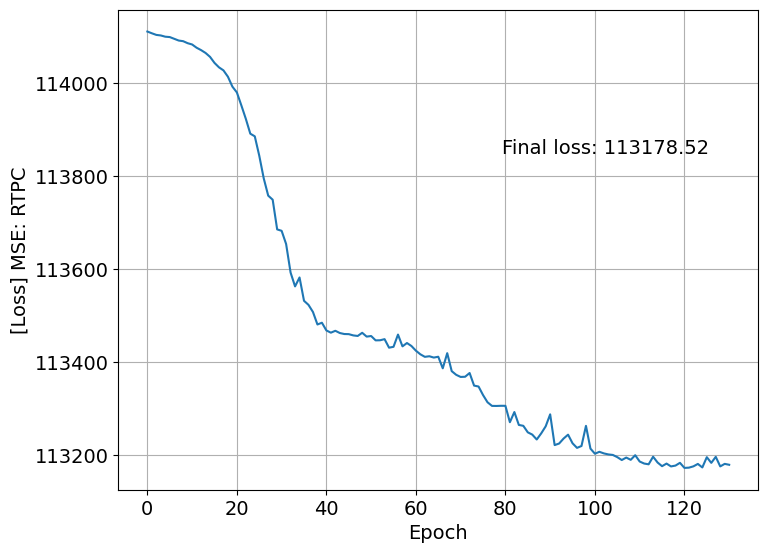

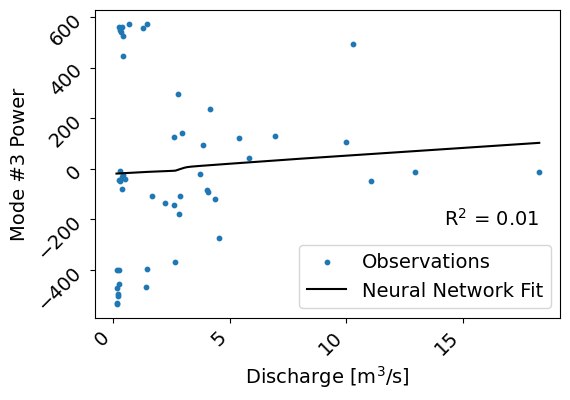

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 2

Calculting fit 3 of 6...
Building models for mode-01
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.5606861433009962


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.5606861433009962


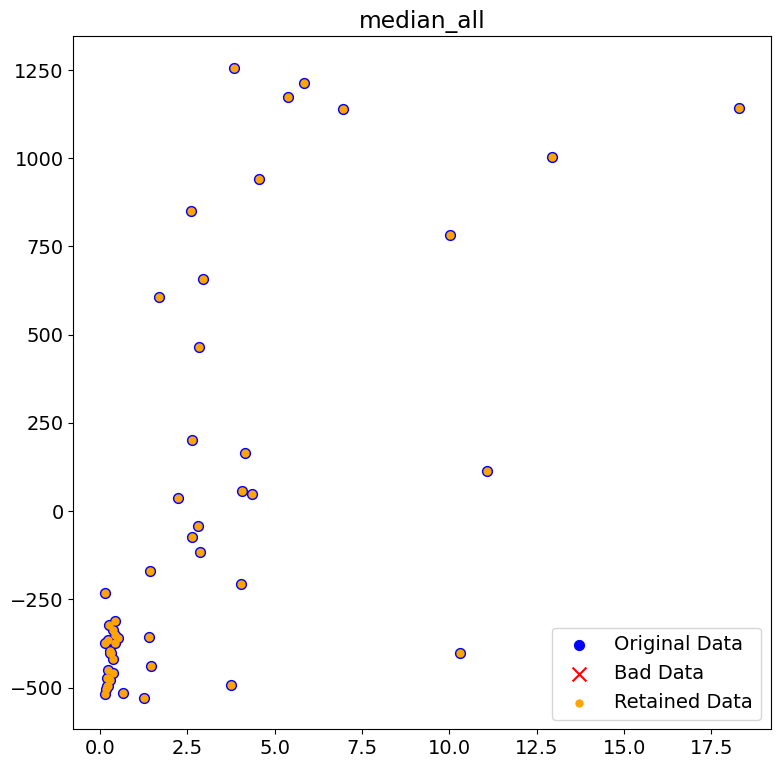

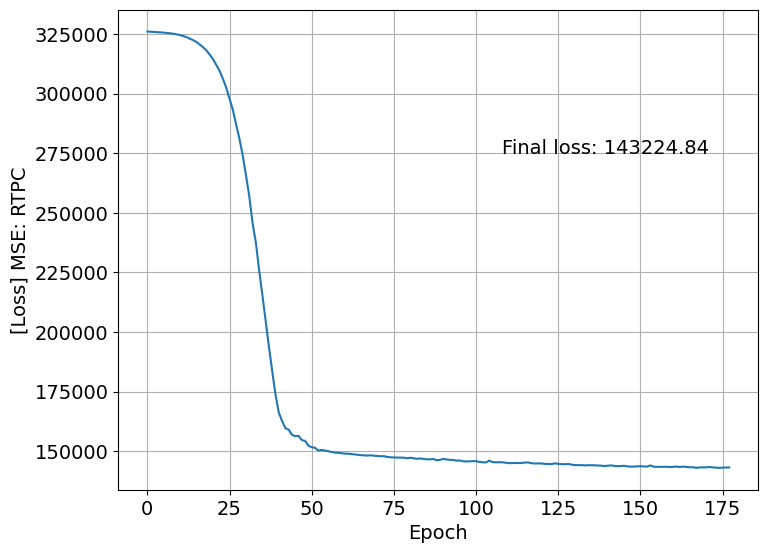

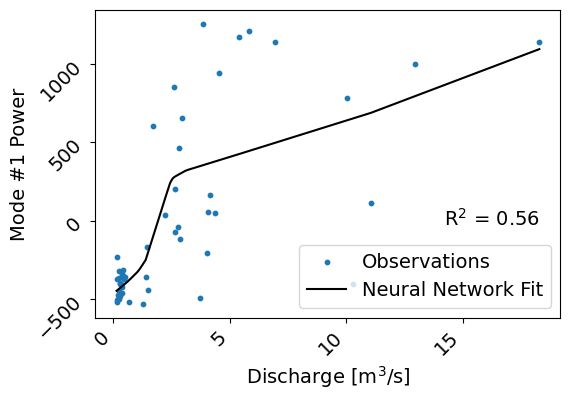

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
R^2 = 0.33166176602319075


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.33166176602319075


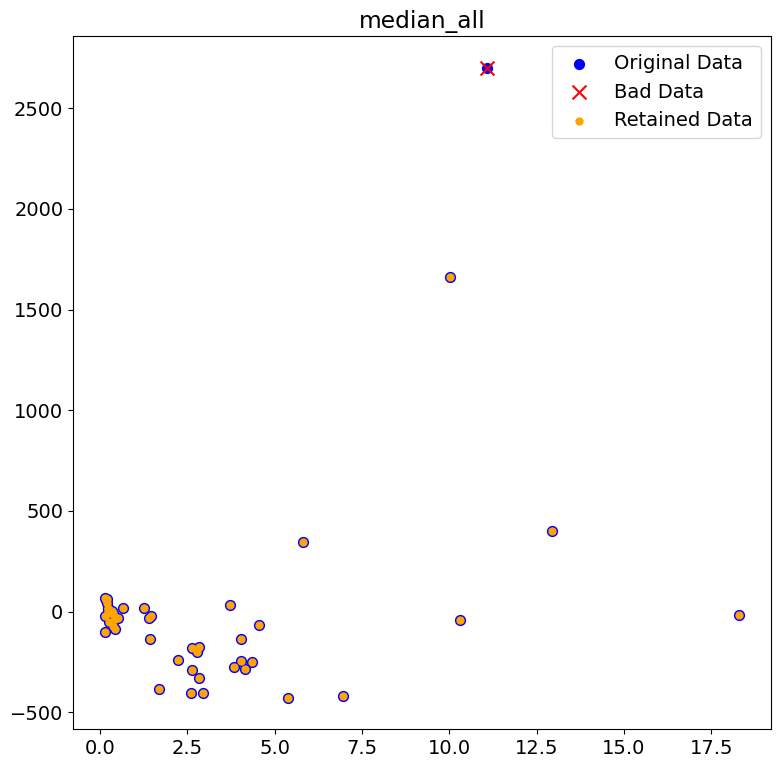

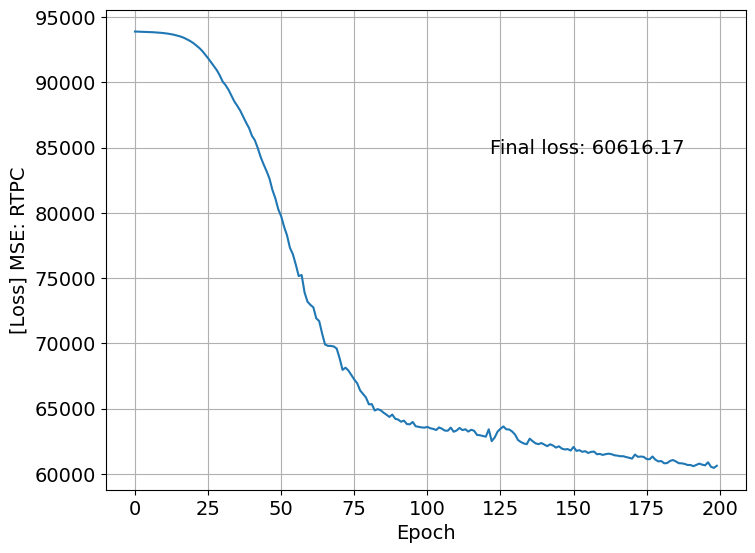

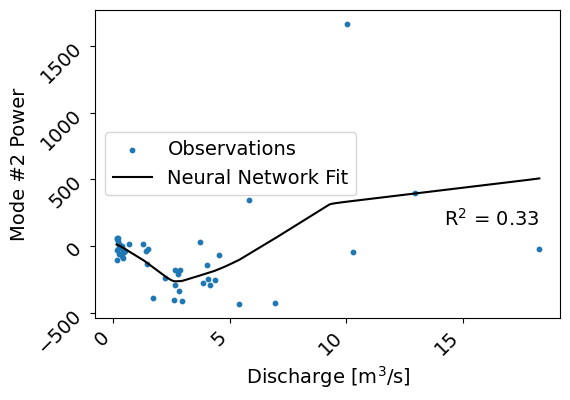

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
R^2 = 0.008473501782507276


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.008473501782507276


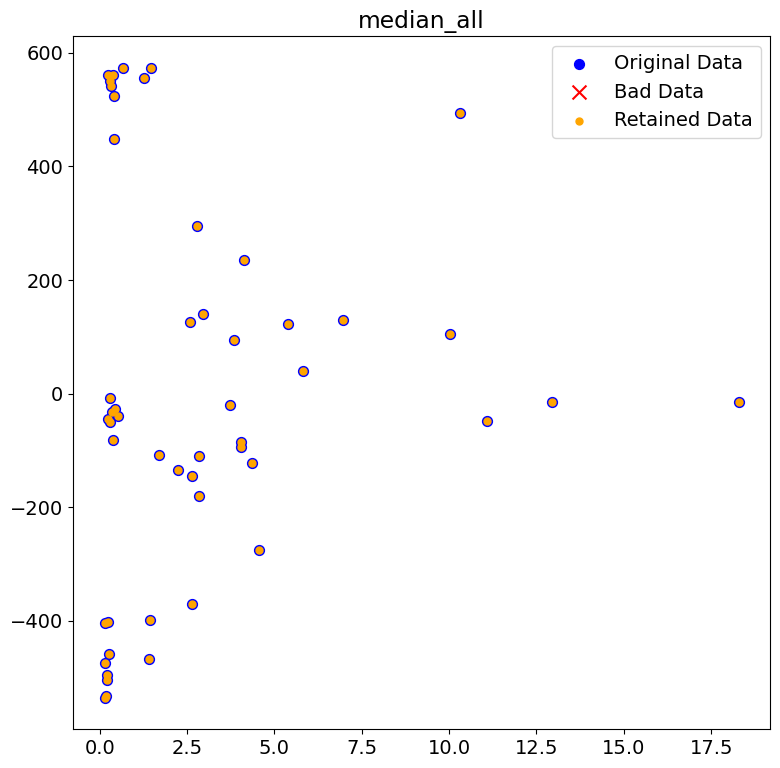

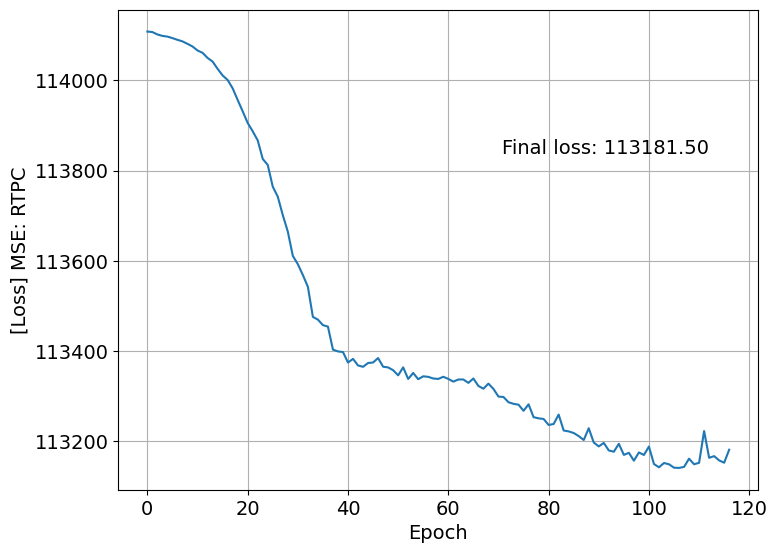

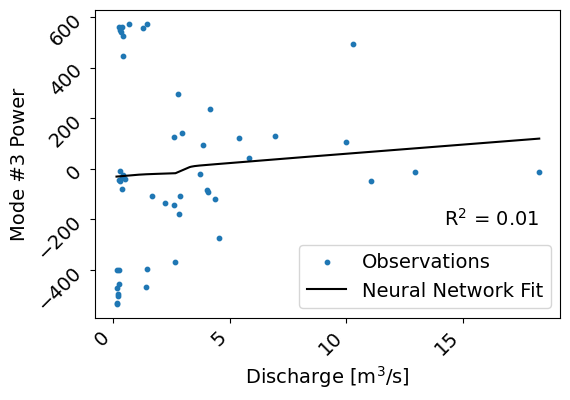

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 3

Calculting fit 4 of 6...
Building models for mode-01
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
R^2 = 0.6112861963152805


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.6112861963152805


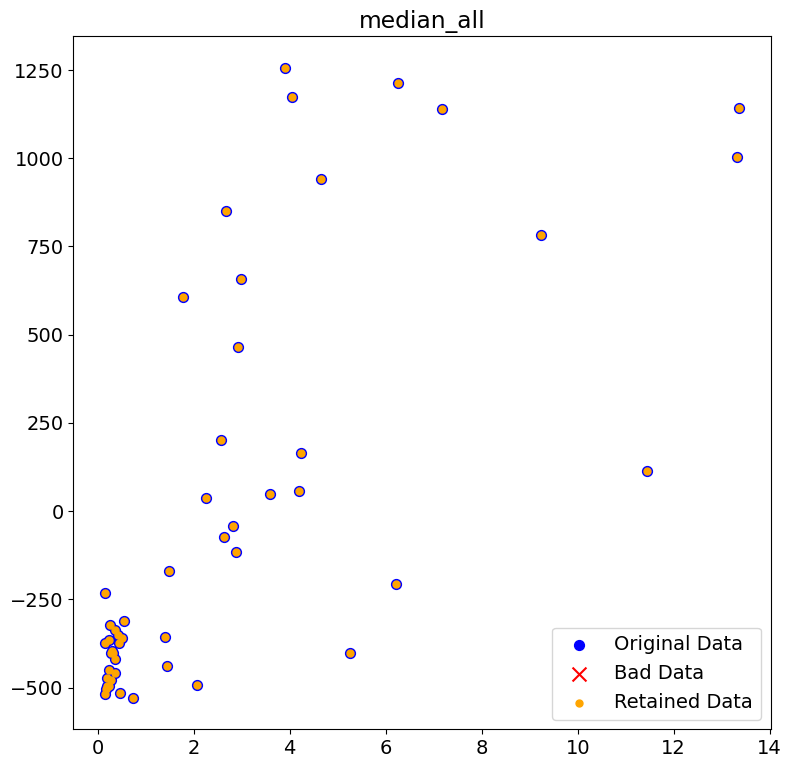

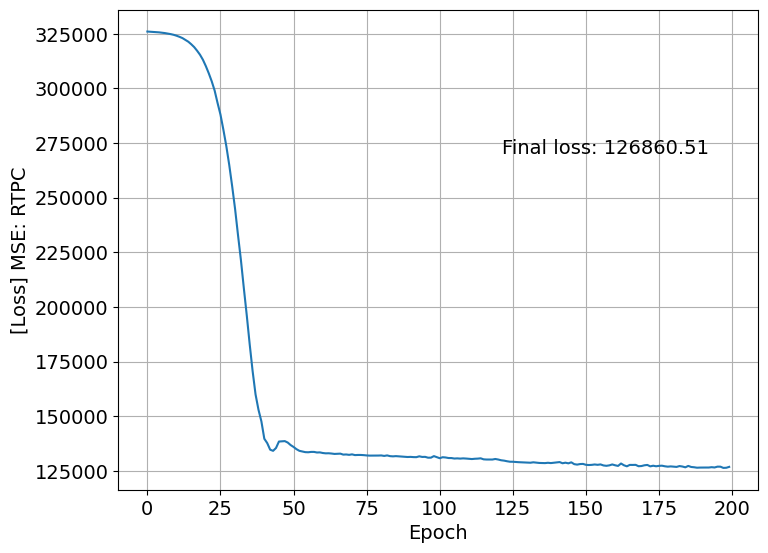

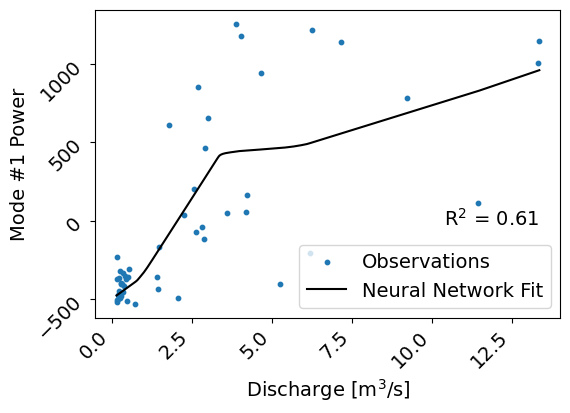

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
R^2 = 0.3886964426098658


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.3886964426098658


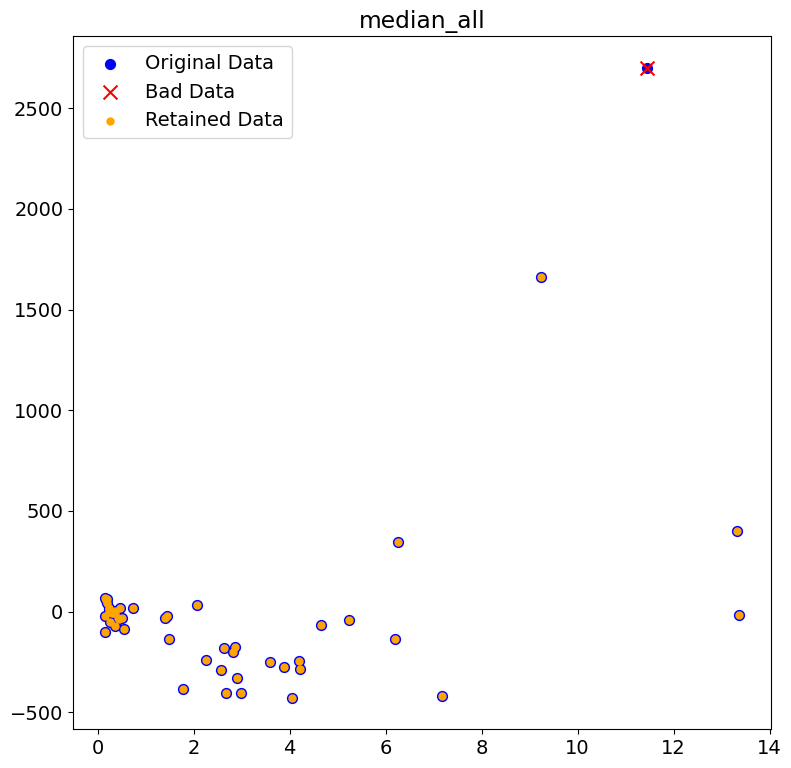

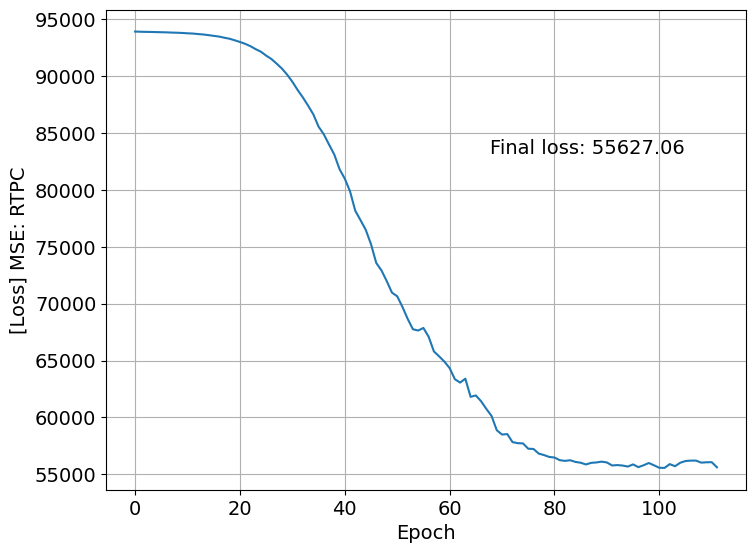

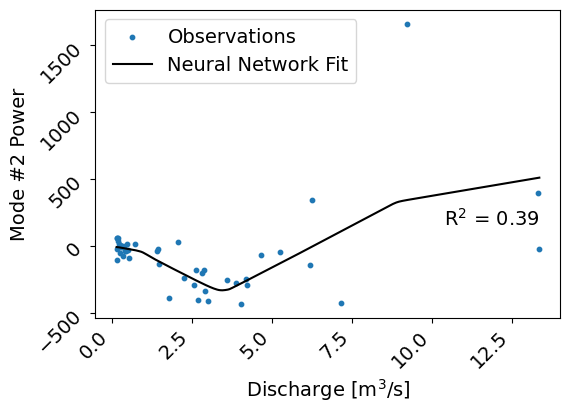

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
R^2 = 0.016122489603346946


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.016122489603346946


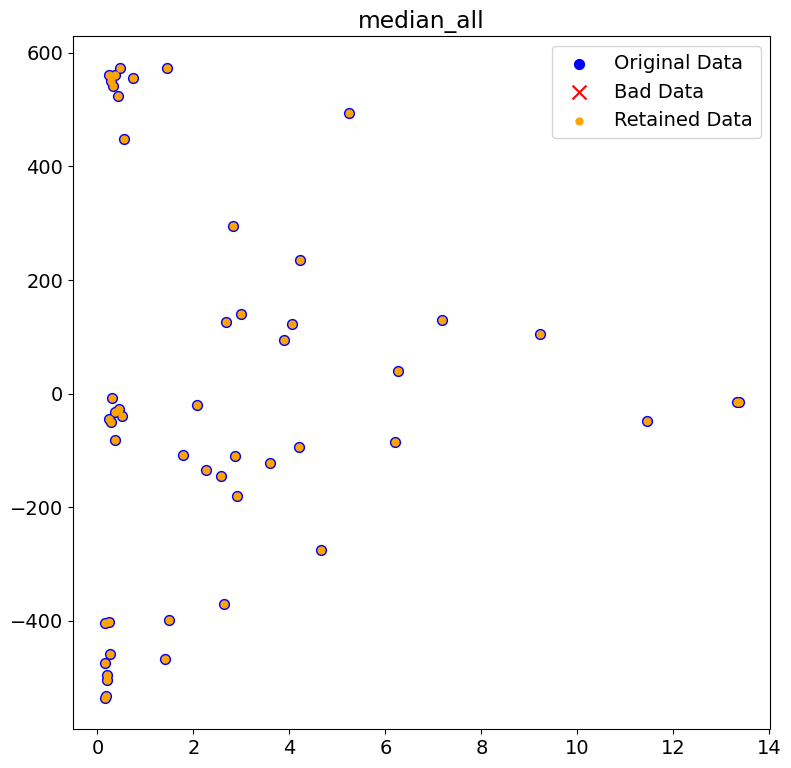

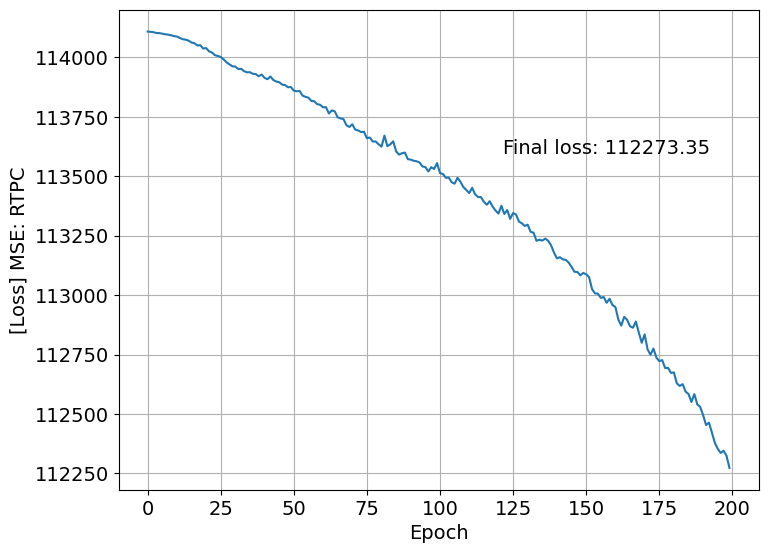

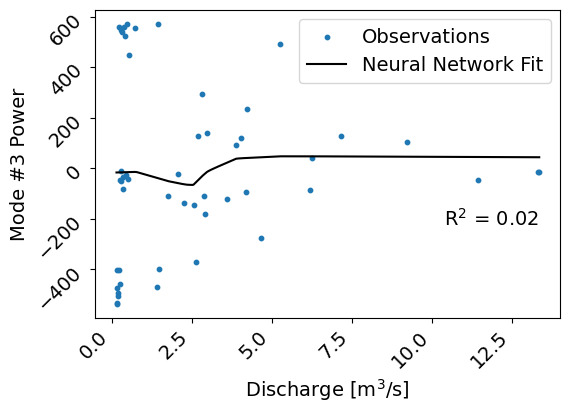

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 4

Calculting fit 5 of 6...
Building models for mode-01
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
R^2 = 0.6023313067152121


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.6023313067152121


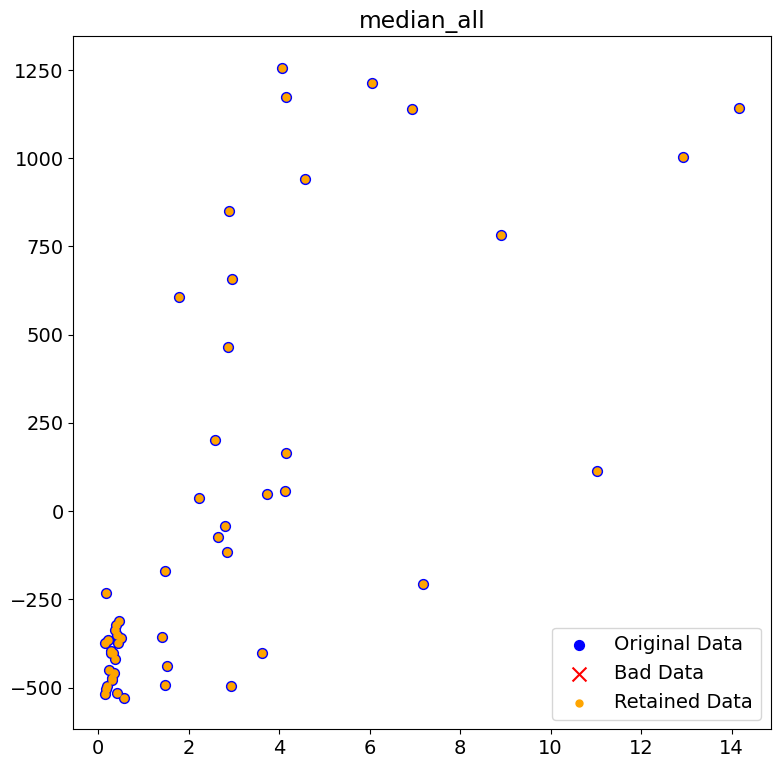

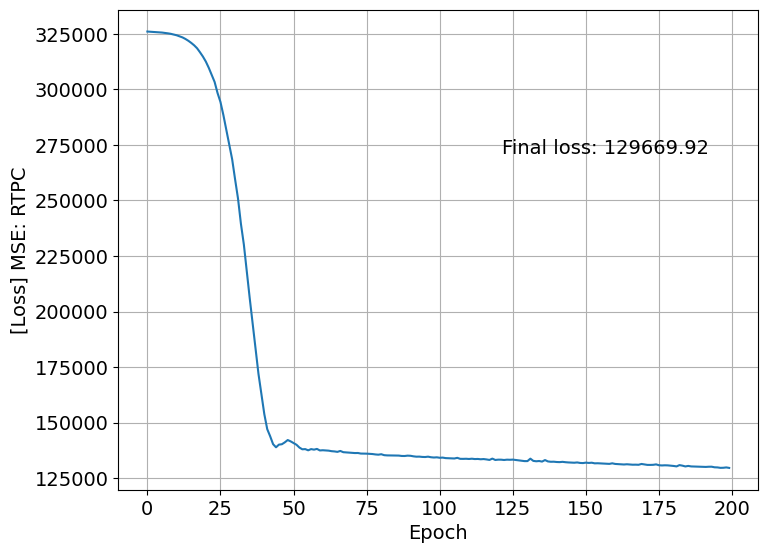

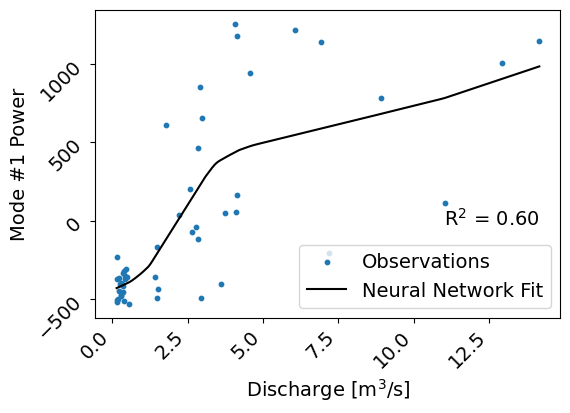

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
R^2 = 0.334120023085968


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.334120023085968


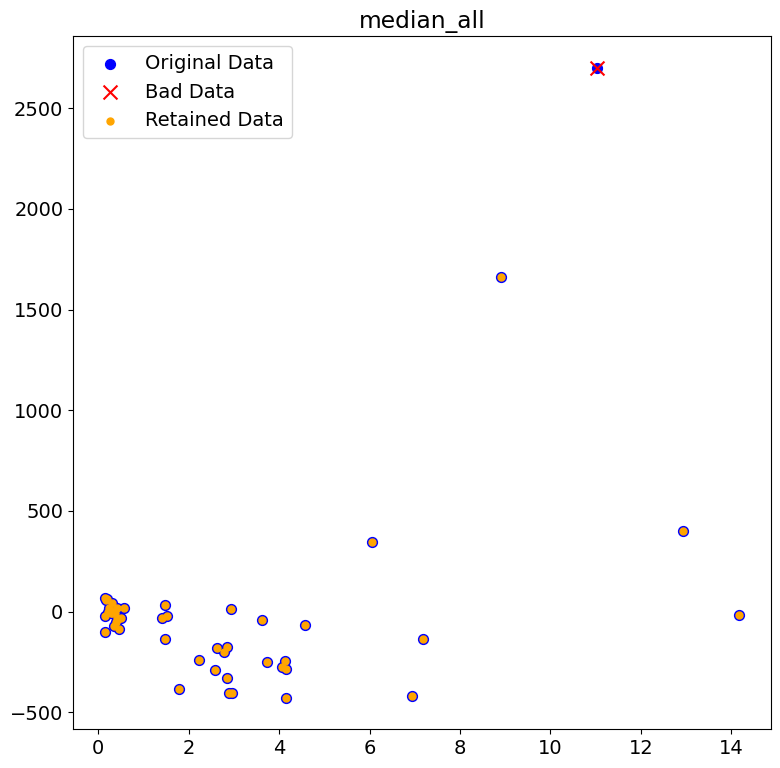

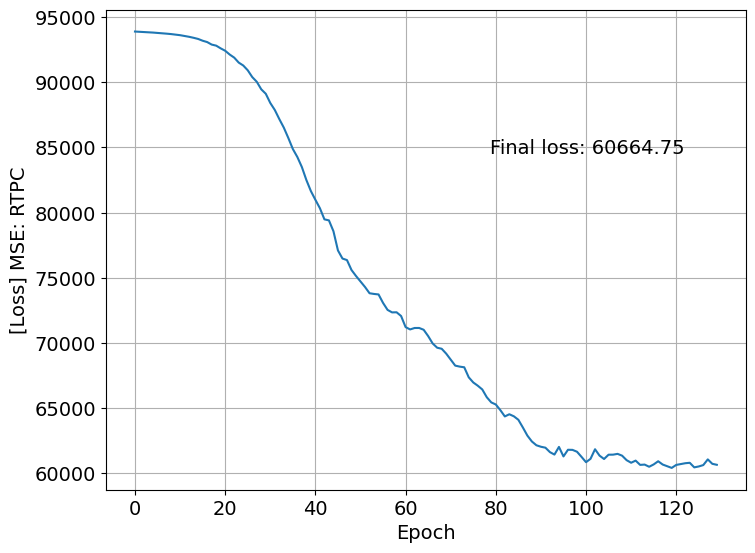

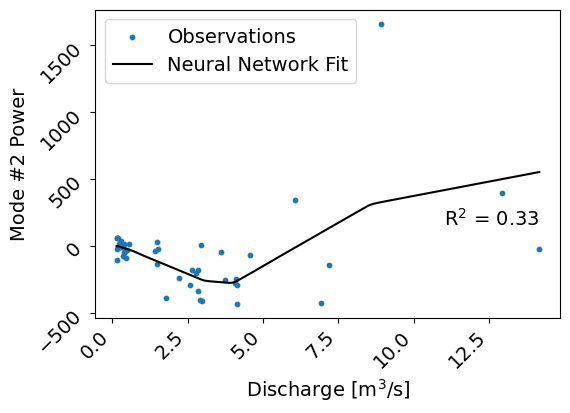

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.02878671117271403


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.02878671117271403


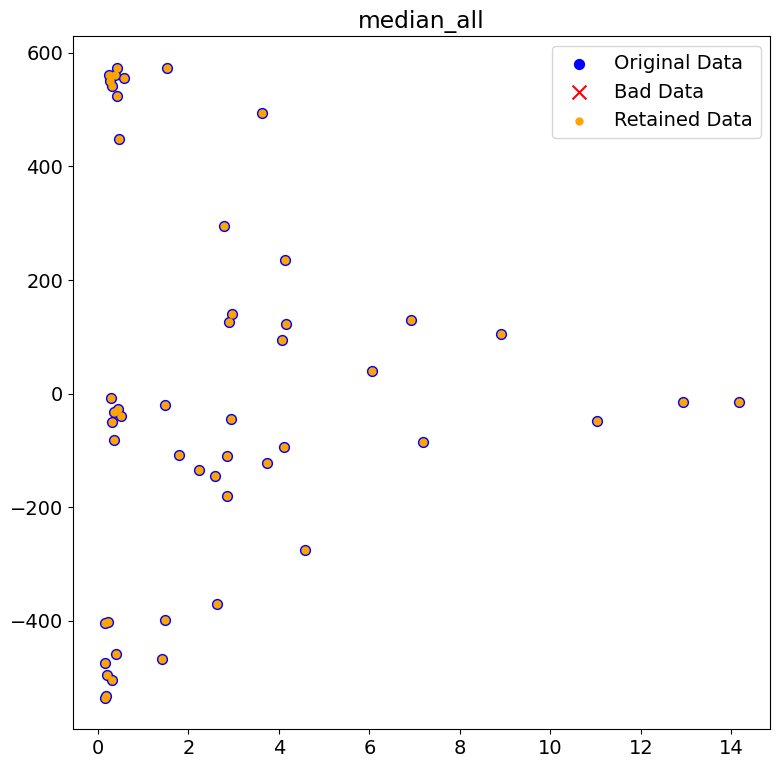

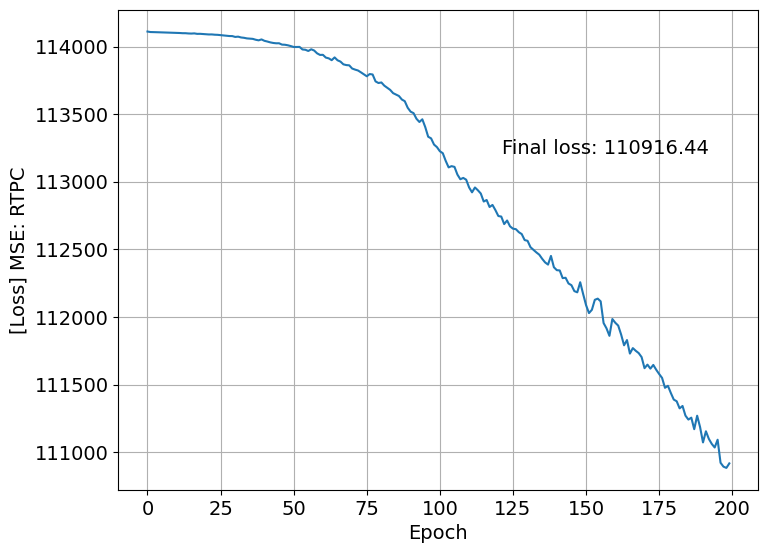

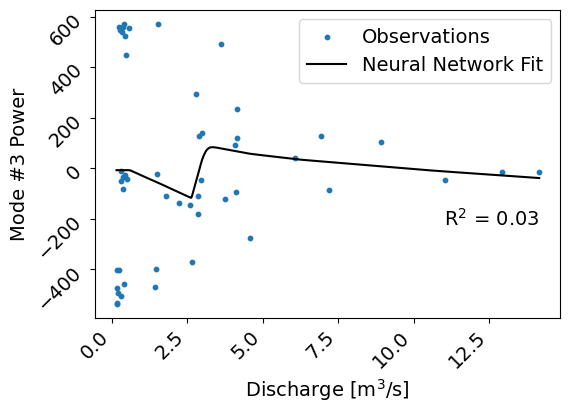

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 5

Calculting fit 6 of 6...
Building models for mode-01
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.6289963251644417


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

1 0.6289963251644417


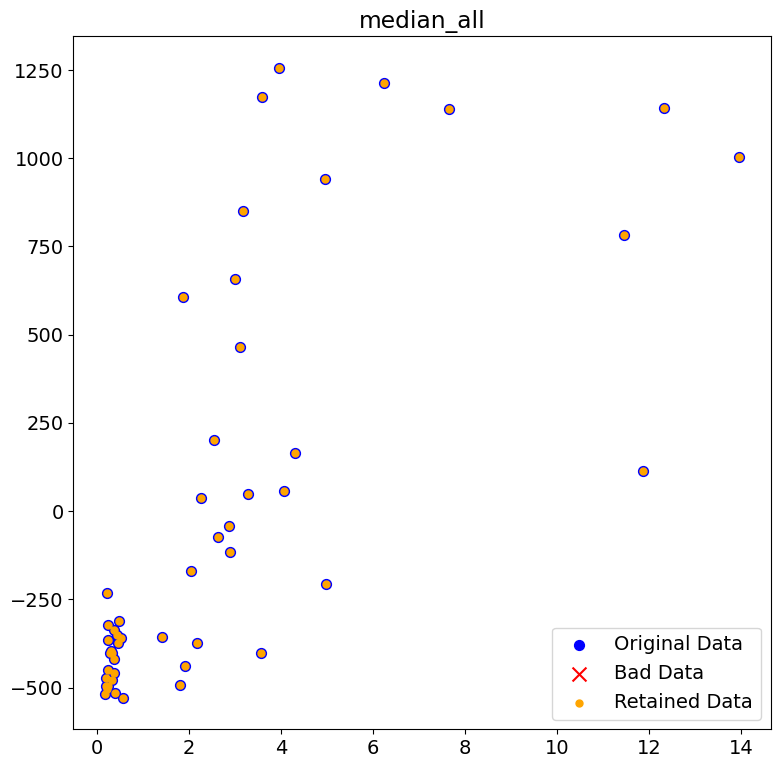

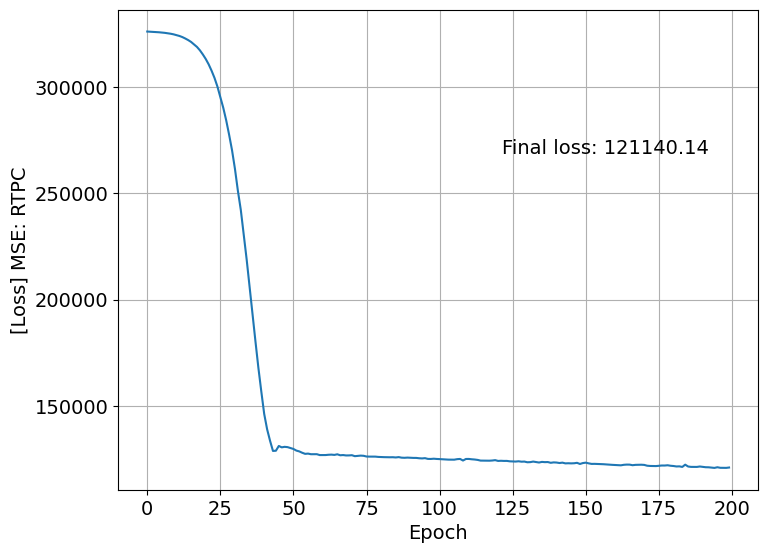

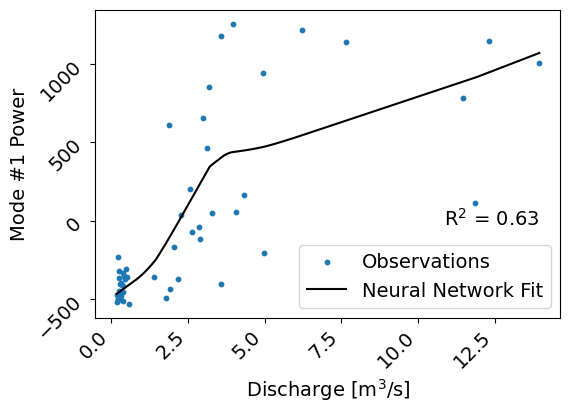

Building models for mode-02
despike_nn ran
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
R^2 = 0.4459753814310995


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

2 0.4459753814310995


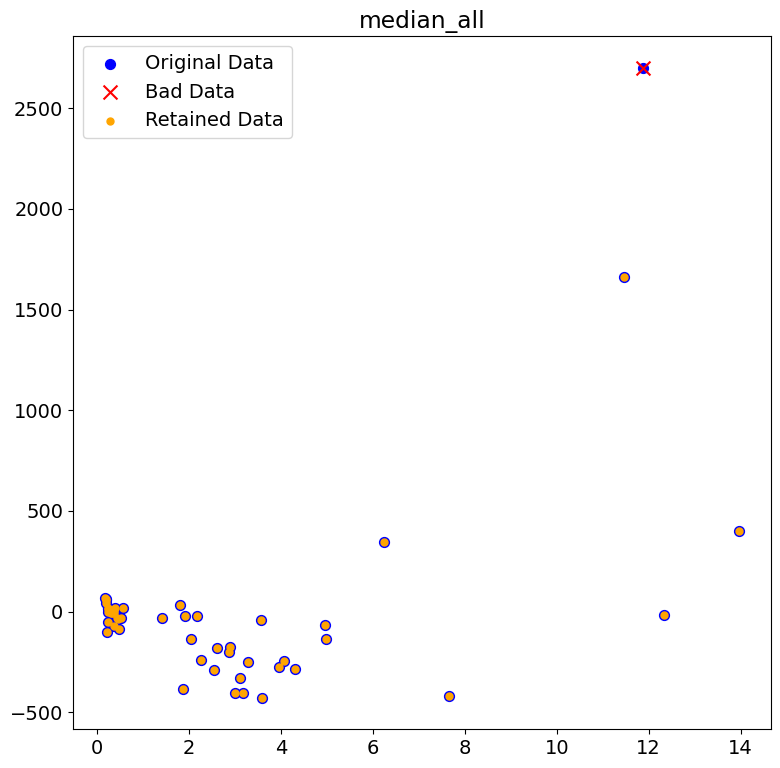

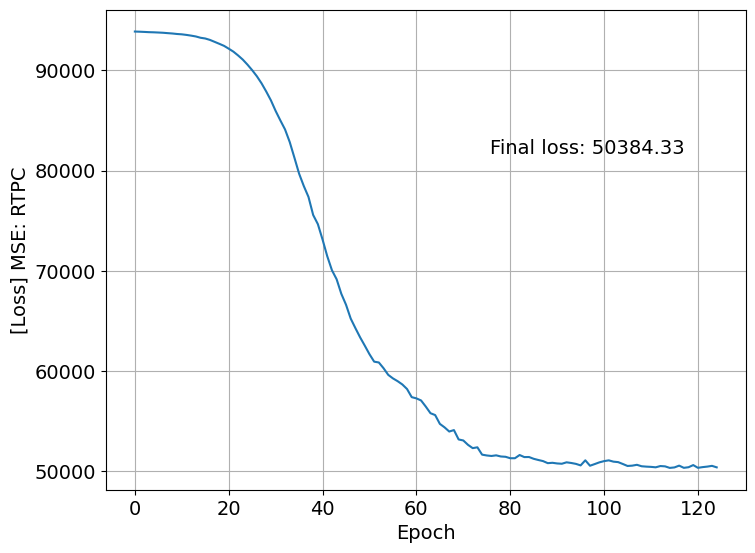

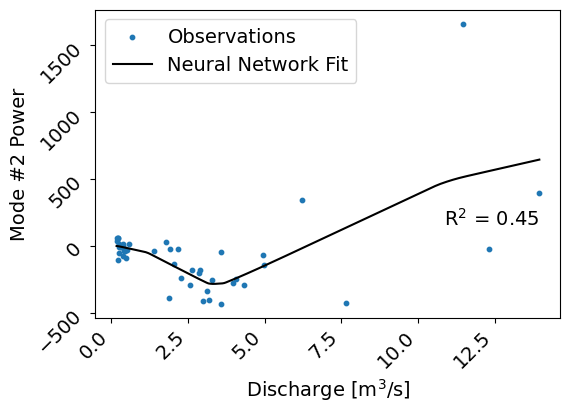

Building models for mode-03
despike_nn ran
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 = 0.07062567657031682


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,808 (487.54 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 83,204 (325.02 KB)

3 0.07062567657031682


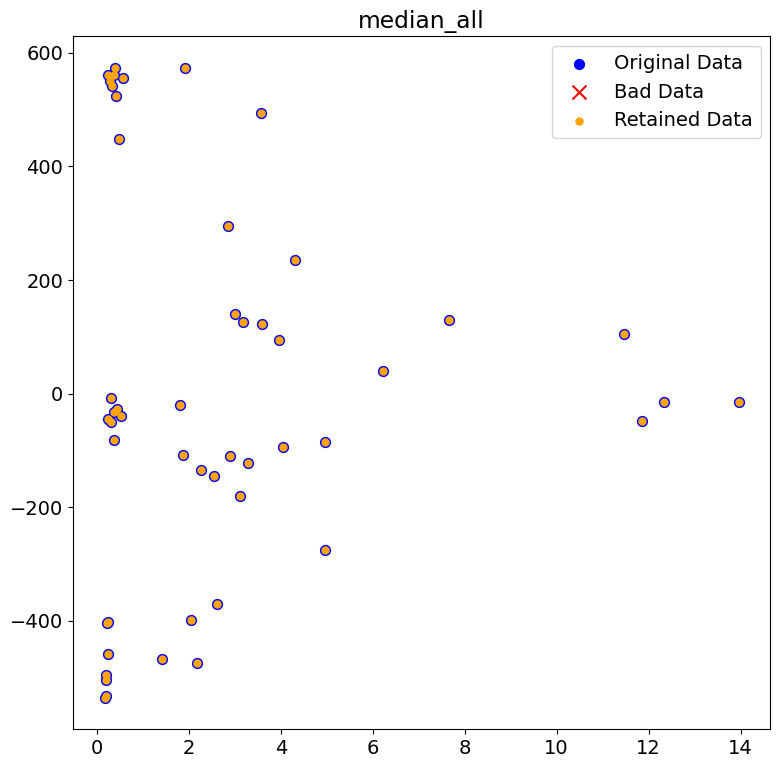

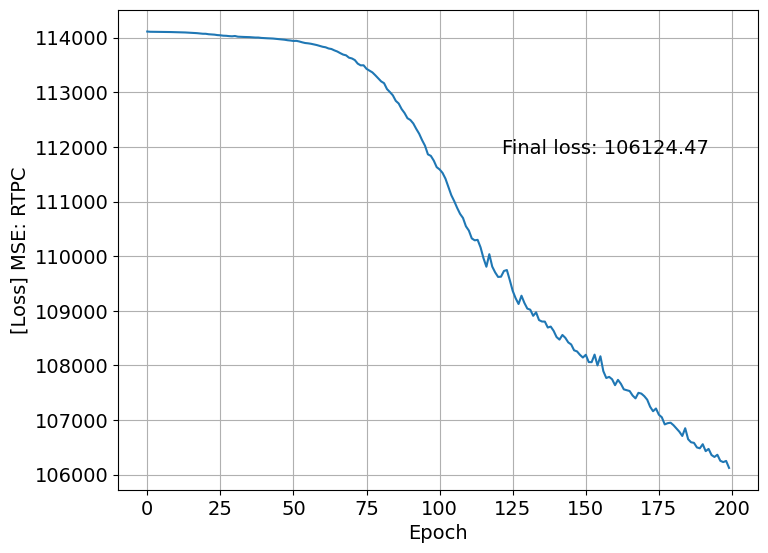

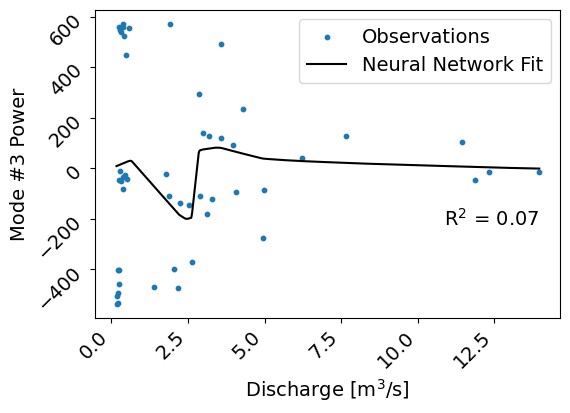

Neural network fits found for modes: [1, 2, 3]
models: [<Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>, <Sequential name=sequential, built=True>]
Smoothing_frame = 6



In [72]:
### --- Loop through each entry of 'smoothing_frame' to get neural network fits --- ###

try:
    del models_nn_smoothed, modes_nn_smoothed, NSEs_nn_smoothed, models_nn_s, modes_nn_s, NSEs_nn_s
except:
    pass

# Initialize containers for output results
models_nn_smoothed = []
modes_nn_smoothed  = []
NSEs_nn_smoothed   = []

for i in range(0,len(smoothing_frame)):
    print(f'Calculting fit {i+1} of {len(smoothing_frame)}...')
    if len(smoothing_frame)==1:
        models_nn_s, modes_nn_s, NSEs_nn_s = nn_fit(reof_ds, q_smoothed, NSE_cut, myDespike, fittingSaveLoc=myFittingSaveLoc, s_f=smoothing_frame[i], figSize=figSize, max_modes=num_modes, datesOnGraphs=False, myAxes=None)
    else:
        models_nn_s, modes_nn_s, NSEs_nn_s = nn_fit(reof_ds, q_smoothed[i], NSE_cut, myDespike, fittingSaveLoc=myFittingSaveLoc, s_f=smoothing_frame[i], figSize=figSize, max_modes=num_modes, datesOnGraphs=False, myAxes=None)
    models_nn_smoothed.append(models_nn_s)
    modes_nn_smoothed.append(modes_nn_s)
    NSEs_nn_smoothed.append(NSEs_nn_s)
    if modes_nn_s == []:
        print(f'No neural network fits were found with NSE >= {NSE_cut}\nSmoothing_frame = {smoothing_frame[i]}\n')
    else:
        print(f'Neural network fits found for modes: {modes_nn_s}\nmodels: {models_nn_s}\nSmoothing_frame = {smoothing_frame[i]}\n')

***
## Identify the Best Filtering Set

This section of code identifies which set of smoothing provides the best data fit. This is determined via a weighted summation of the R-squared value multiplied by the inverse of the mode and then divided by the summation of the inverse modes. This is shown in the equation below. 

$$
Score = \frac{\sum_{i=1}^N R^2 / i}{\sum_{i=1}^N 1/i}
$$


N is the total number of modes used. i is the ith mode. 

This particular method was chosen as the higher the mode, the less data it explains. Therefore, higher modes are less desirable. The denominator was chosen so that the maximum score returned is 1. 
The code has been written with a multi-mode version in mind. 

In [73]:
### --- Visualize fitting results --- ###

def plot_metrics(modes, r2s):
    xs = np.arange(0,len(modes))
    plt.bar(xs, r2s)
    plt.xticks(ticks=xs, labels=modes)
    plt.ylim(0,1)
    plt.xlabel('Mode')
    plt.ylabel('Score (R$^2$)')
    plt.show()

def plot_metrics_smoothed(scores_nn, scores_poly, s_f):
    # s_f = smoothing_frame
    width = 0.25
    xs = np.arange(0,len(s_f))
    plt.bar(xs, scores_nn, label='Neural Network', width=width)
    plt.bar(xs+width, scores_poly, label='Polynomial', width=width)
    plt.xticks(ticks=xs, labels=s_f)
    plt.ylim(0,1)
    plt.title('R Squared Value for Various Smoothings')
    plt.xlabel('Days of Smoothing')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

Polynomial
Smoothing_frame = 0


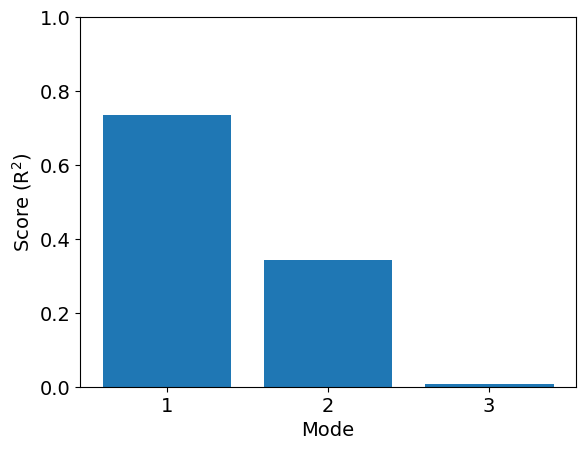

Polynomial
Smoothing_frame = 2


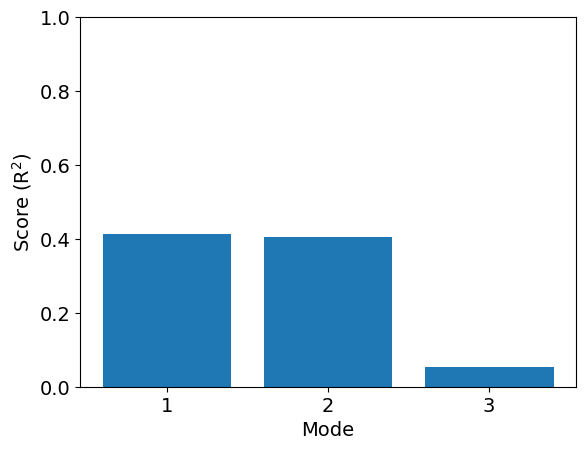

Polynomial
Smoothing_frame = 3


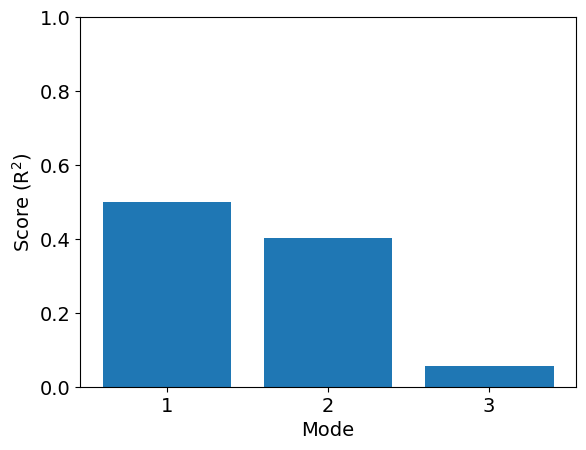

Polynomial
Smoothing_frame = 4


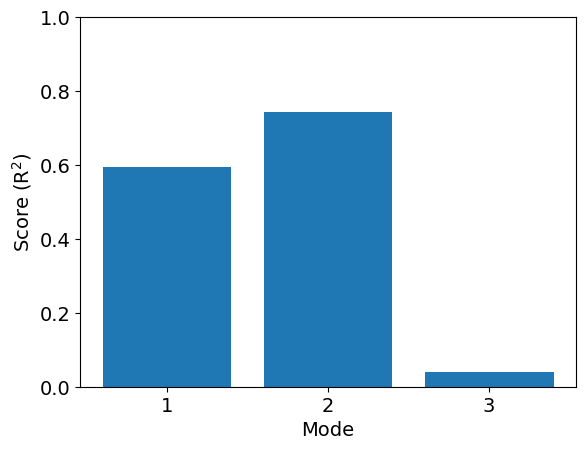

Polynomial
Smoothing_frame = 5


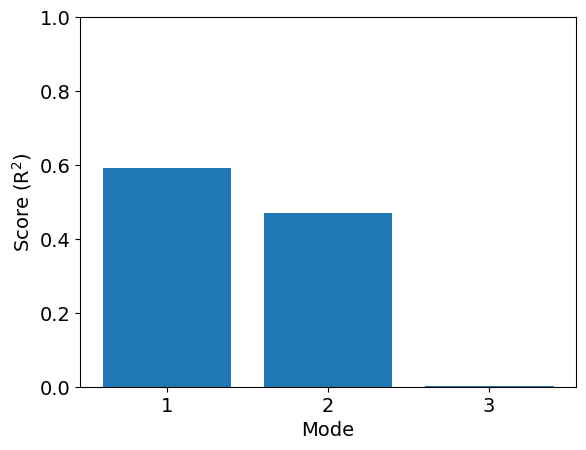

Polynomial
Smoothing_frame = 6


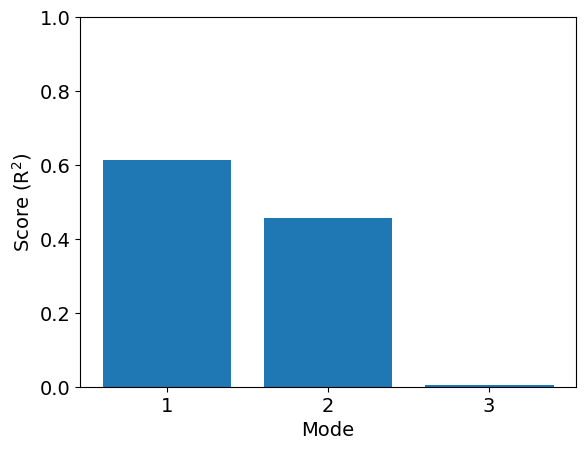

In [74]:
for i in range(0,len(modes_poly_smoothed)):
    print(f'Polynomial\nSmoothing_frame = {smoothing_frame[i]}')
    plot_metrics(modes_poly_smoothed[i], NSEs_poly_smoothed[i])

Neural Network
Smoothing_frame = 0


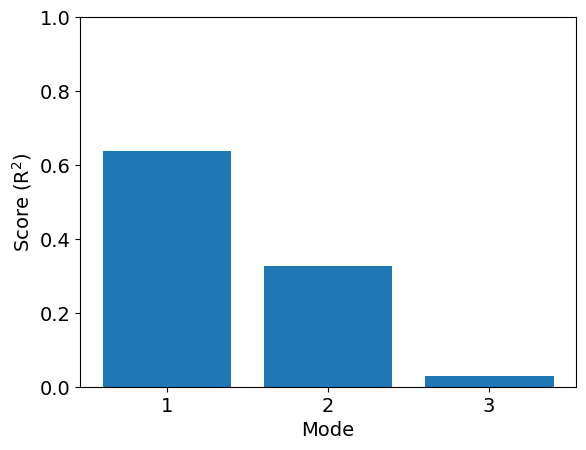

Neural Network
Smoothing_frame = 2


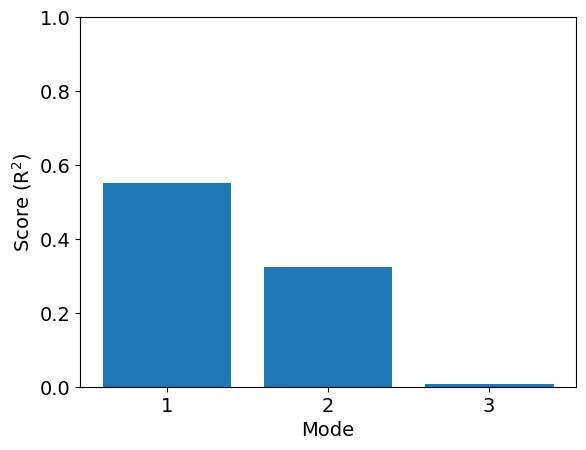

Neural Network
Smoothing_frame = 3


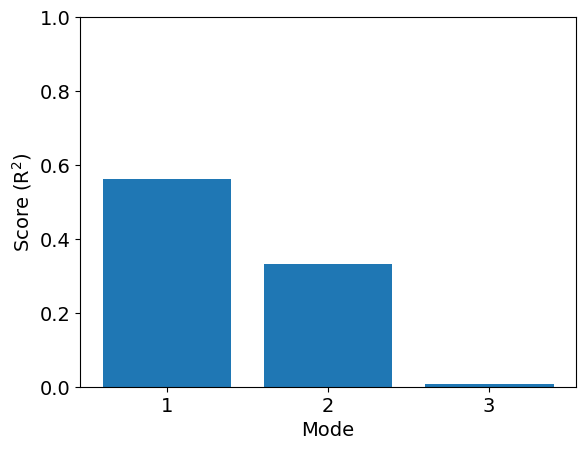

Neural Network
Smoothing_frame = 4


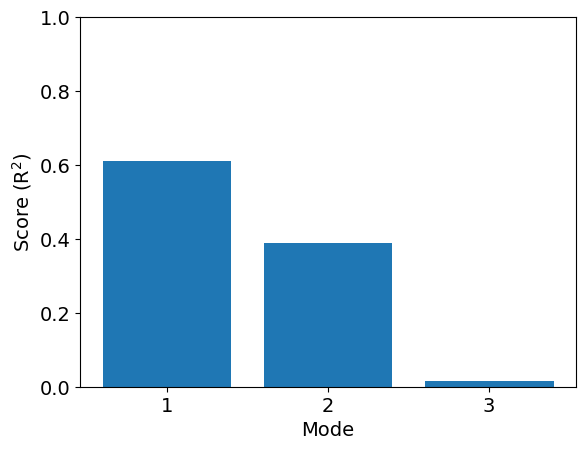

Neural Network
Smoothing_frame = 5


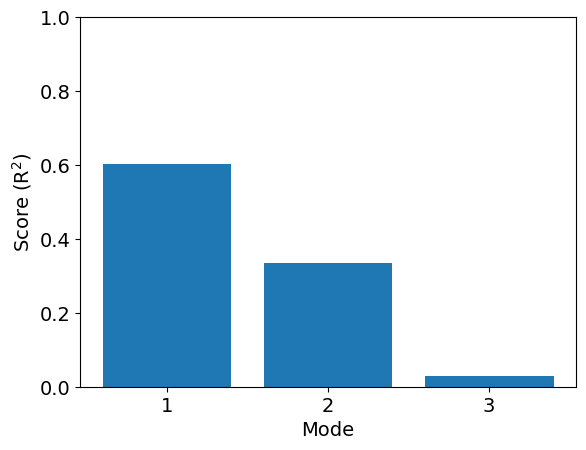

Neural Network
Smoothing_frame = 6


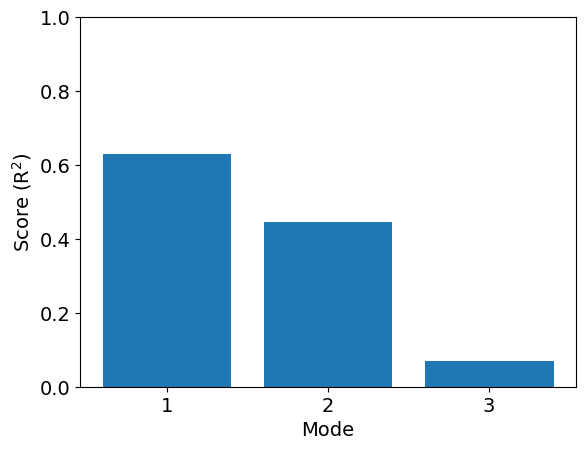

In [75]:
for i in range(0,len(modes_nn_smoothed)):
    print(f'Neural Network\nSmoothing_frame = {smoothing_frame[i]}')
    plot_metrics(modes_nn_smoothed[i], NSEs_nn_smoothed[i])

In [76]:
### --- define function to calculate a normalized score for fitting --- ###
def score(modes, r2s, max_modes=[]):
    # modes     - the list of modes for which a sufficiently good line was fitted
    # r2s       - the r squared value for each mode in modes
    # max_modes - the maximum number of modes to consider for calculating the score; this is generally kept the same as the number of modes for which a polynomial/neural network fit were determined (usually 10)

    # temp variables created to prevent modification of originals. 
    myModes = []
    missingModes = []
    myR2s = []
    missingR2s = []
    if not max_modes:
        max_modes = 10

    # get modes up to max_modes
    for i in range(0,max_modes): 
        try:
            if modes[i] <= max_modes:
                myModes.append(modes[i])
                myR2s.append(r2s[i])
        except:
            pass
    
    # add 'missing' modes and r2s
    # note: all 'missing' r2s are given values of 0. This is to normalize the comparison to other fits. In other words, this is done to prevent high mode fits from falsely deflating scores. 
    # E.g., if a poly fit has only up to modes 5, but a neural network fit has one at mode 10, all of those extras cause the neural network to have a much lower score, 
    # even though the modes that the neural network and poly fits share are identical. 
    min_val = min(modes)
    max_val = max_modes
    full_range = set(range(min_val, max_val+1))
    input_set = set(modes)
    missingModes = sorted(list(full_range - input_set))
    myModes = myModes + missingModes
    zeros_to_add = [0] * len(missingModes)
    myR2s.extend(zeros_to_add)

    # make 'myR2s' and 'myModes' integer arrays
    myR2s = np.array(myR2s)
    myModes = np.array(myModes)
    
    # # check of added 'missing' modes and r2s
    # for i in range(0, len(myModes)): 
    #     print(f'myMode = {myModes[i]}, myR2s = {myR2s[i]}')
    
    # calculate the weighted score. 
    if max_modes:
        S = np.nansum( np.divide(myR2s[myModes<=max_modes],myModes[myModes<=max_modes]) ) / np.nansum( np.divide(1,myModes[myModes<=max_modes]) )
    else: 
        S = np.nansum( np.divide(myR2s,myModes) ) / np.nansum( np.divide(1,myModes) )
    
    return S

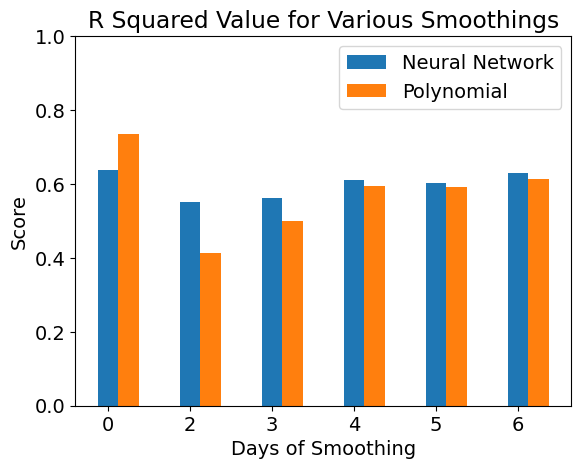

In [77]:
### --- Calculate scores --- ###
max_modes = 1

# polynomial
scores_poly = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_poly[i] = score( modes_poly_smoothed[i], NSEs_poly_smoothed[i], max_modes ) 

# neural network
scores_nn = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_nn[i] = score( modes_nn_smoothed[i], NSEs_nn_smoothed[i], max_modes )

plot_metrics_smoothed(scores_nn, scores_poly, smoothing_frame)

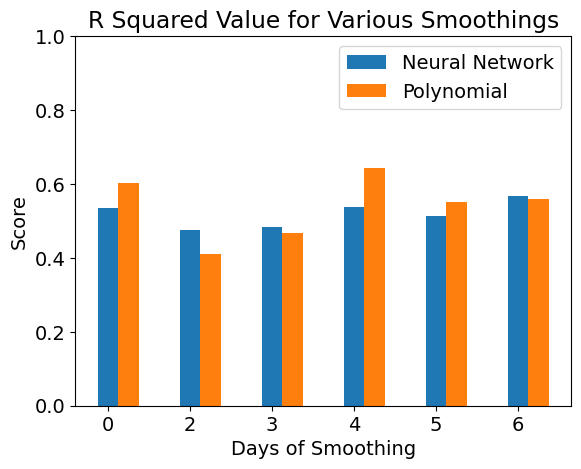

In [83]:
### --- Calculate scores --- ###
max_modes = 2

# polynomial
scores_poly = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_poly[i] = score( modes_poly_smoothed[i], NSEs_poly_smoothed[i], max_modes ) 

# neural network
scores_nn = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_nn[i] = score( modes_nn_smoothed[i], NSEs_nn_smoothed[i], max_modes )

plot_metrics_smoothed(scores_nn, scores_poly, smoothing_frame)

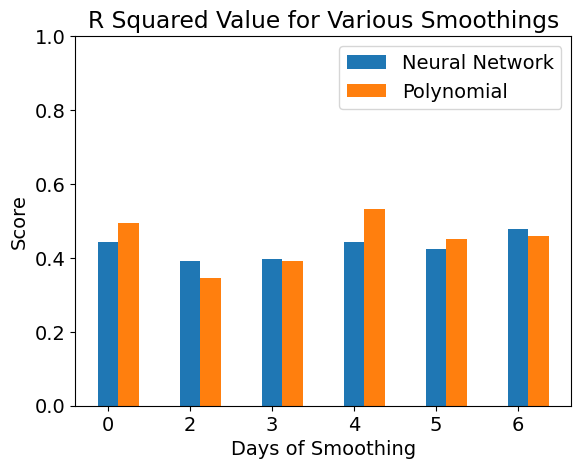

In [79]:
### --- Calculate scores --- ###
max_modes = vis_modes 

# polynomial
scores_poly = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_poly[i] = score( modes_poly_smoothed[i], NSEs_poly_smoothed[i], max_modes ) 

# neural network
scores_nn = np.zeros(len(smoothing_frame))
for i in range(0,len(smoothing_frame)):
    scores_nn[i] = score( modes_nn_smoothed[i], NSEs_nn_smoothed[i], max_modes )

plot_metrics_smoothed(scores_nn, scores_poly, smoothing_frame)

In [80]:
### --- Select the 'best' model for polynomial and neural network --- ###

# Make selection
# for polynomials
max_poly = np.max(scores_poly)
idx_poly = np.where(scores_poly == max_poly)[0][0]
# for neural network
max_nn = np.max(scores_nn)
idx_nn = np.where(scores_nn == max_nn)[0][0]

# print out if they have the same smoothing or not
if idx_poly != idx_nn:
    print(f'Warning!!!\nBest polynomial and best neural network have different smoothings!\nHighest score has been used to select the best models to return.')
    
    # Select which of the two to use
    if max_nn > max_poly:
        myIdx = idx_nn
    else:
        myIdx = idx_poly
else:
    myIdx = idx_nn

print(f'\nSelected Index and Scores\nIndex: {myIdx}\nNumber of days smoothed: {smoothing_frame[myIdx]}\nScore(poly, nn): {scores_poly[myIdx]}, {scores_nn[myIdx]}')

Warning!!!
Best polynomial and best neural network have different smoothings!
Highest score has been used to select the best models to return.

Selected Index and Scores
Index: 3
Number of days smoothed: 4
Score(poly, nn): 0.533574290202593, 0.442368316811634


In [81]:
modes_nn_smoothed[myIdx]

[1, 2, 3]

In [82]:
modes_poly_smoothed[myIdx]

[1, 2, 3]

***
# Save Models for Forecasting

The polynomial and neural network models are saved here. These are then loaded by the python script which will be executed by the cron job. This is to reduce the amount of processing and computing resources needed. The logic is that the training notebook (this one) will only need to be run possibly once per year; ostensibly, the training data will not need to change very often. Only if there is a very large flooding event (larger than those in the current body of records) will new data need to be incorporated. This is in contrast to the forecasting, which will need to be done as much as every day; ideally, this will only be needed to run once every few days. By splitting the notebooks, the user does not have to do the highly computing intensive REOF every single time they want a new forecast

In [92]:
# Load one of the SAR images or water masks in order to get the coordinate reference system. This is used in saving the forecasts as geotiffs. 
if type_file == 'Water_Masks':
    folder = fc.selected+'Water_Masks/'
else:
    folder = fc.selected+'RTC_GAMMA/'

# Gather names of files corresponding to the file type and polarization we want
tiff_dir = Path(folder)
# tiffs = list(tiff_dir.glob(f'{prefix}.tif*')) # for water masks
tiffs = list(tiff_dir.glob(f'*.tif*'))

raster = rasterio.open(tiffs[0])

# get important GIS info
CRS = raster.crs
transform = raster.transform

In [93]:
# load needed modules
import _pickle as cPickle

In [94]:
# create the folder in which to store 'my_vz'
# saveFolder = Path(fc.selected, 'Forecasting-Files_'+datetime.today().strftime('%Y-%m-%d'))
saveFolder = Path(fc.selected, 'Forecasting-Files')
saveFolder.mkdir(parents=True, exist_ok=True)

In [95]:
model_sel = 1 # use the polynomial
# model_sel = 0 # use the neural network

In [96]:
saveFile = f'ForecastingFiles_Created-{datetime.today().strftime("%Y%m%d")}_NSE={NSE_cut}_{mysType}_{n_modes}Modes-REOF_{num_modes}Modes-Fit_thrshld={threshold_prcnt}_myDim={myDim}_MDretained{keep_start.strftime("%m-%d")}to{keep_stop.strftime("%m-%d")}'
if myDespike['despike']:
    saveFile = saveFile + '_despiked'

print(f'saveFile name: {saveFile}')

saveFile name: ForecastingFiles_Created-20251002_NSE=0.001_forwardOnly_3Modes-REOF_3Modes-Fit_thrshld=None_myDim=discharge_MDretained03-01to10-30_despiked


In [100]:
# use cPickle to store all files in a single file
# NOTE: using this methodology requires they be saved and loaded in the same order. 



start = time.time()

import os
try:
    os.remove(Path(saveFolder,saveFile+".pkl"))
    print("old file deleted")
except OSError:
    pass

with open(Path(saveFolder,saveFile+".pkl"), "wb") as f:
    cPickle.dump(reof_ds.isel(mode=slice(0,num_modes)),f)
    cPickle.dump(modes_poly_smoothed,f)
    cPickle.dump(degs_smoothed,f)
    cPickle.dump(polys_smoothed,f)
    cPickle.dump(models_nn_smoothed,f)
    cPickle.dump(modes_nn_smoothed,f)
    cPickle.dump(q_smoothed,f)
    cPickle.dump(q_tot_smoothed,f)
    cPickle.dump(type_file,f)
    cPickle.dump(da_tot[ind_flood],f)
    cPickle.dump(ind_flood,f)
    cPickle.dump(floodpercent,f)
    cPickle.dump(time_flood,f)
    cPickle.dump(lat,f)
    cPickle.dump(lon,f)
    cPickle.dump(ID,f)
    cPickle.dump(model_sel,f)
    cPickle.dump(CRS,f)
    cPickle.dump(transform,f)
    cPickle.dump(smoothing_frame,f)
    cPickle.dump(scores_nn,f)
    cPickle.dump(scores_poly,f)
    cPickle.dump(NSEs_poly_smoothed,f)
    cPickle.dump(NSEs_nn_smoothed,f)
    cPickle.dump(myIdx,f)

end = time.time()

print('It took ',end-start,' seconds to save the files. ')

old file deleted
It took  0.5816707611083984  seconds to save the files. 
